# F_S3.2 — Complex Path: SiZer vs KL/QR/HD Comparison

Compare two methods for classifying shapes that the Simple (power-law) path cannot resolve:
- **Method A**: SiZer (multi-scale derivative analysis)
- **Method B**: KL / QR / HD (distributional tests from the thresholds paper)

Input: cases from Gate 2 Complex + Simple path R² fail ("Enter next branch").

## Shared setup

Reuse config, catalogue, data loading, Gate 1, Gate 2 from F_S3.

In [300]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

warnings.filterwarnings('ignore')

def count_percent(count, total):
    count = int(count)
    total = int(total)
    return f'{count:,} ({count / total:.1%})' if total else f'{count:,} (N/A)'

def locate_repo_root() -> Path:
    for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (root / 'D').is_dir() and (root / 'E').is_dir():
            return root
    raise FileNotFoundError('Could not locate repo root.')

REPO_ROOT = locate_repo_root()

# ═══════════════════════════════════════════════════════
# ██  DATA SOURCE SWITCH  ██
# ═══════════════════════════════════════════════════════
DATA_SOURCE = 'E'    # E data (S3_snr_mic_sweep)
# DATA_SOURCE = 'F'      # F data (S1_parameterized)

# ── E data: variant_level filter ──
# Available: 'mild', 'none', 'standard', 'strong'
E_VARIANT_FILTER = ['strong','standard']
# E_VARIANT_FILTER = ['strong']

# ── F data: strength_name filter ──
# Available: 'very_weak', 'weak', 'medium', 'strong', 'very_strong'
F_STRENGTH_FILTER = ['strong']
# ═══════════════════════════════════════════════════════


# ═══════════════════════════════════════════════════════
# ██  METHOD SWITCH  ██
# ═══════════════════════════════════════════════════════
RUN_METHOD_A = True    # Method A: Multiscale TP (SiZer-based derivative analysis)
RUN_METHOD_B = True   # Method B: KL / QR / HD (distributional tests)
RUN_METHOD_C = True    # Method C: Conditional dip test (branch detection)
RUN_METHOD_D = False    # Method D: Periodicity detection (Lomb-Scargle / ACF / Spectral Entropy)
RUN_SIMPLE_ANALYSIS = True  # Simple-path diagnostic tables (R² breakdown, routing accuracy, sweep)
KL_METHOD = 'histogram'     # 'kde' (paper-style 2D KDE, slow) or 'histogram' (np.histogram2d, fast)

# ── MIC analysis gates (both will be analyzed) ──
MIC_ANALYSIS_GATES = ['strong_global', 'intermediate_global']


#
# ── Flat threshold for derivative (SiZer) ──
FLAT_FRAC = 0.05           # |β₁| < FLAT_FRAC * ref → treated as flat
FLAT_REF = 'max'           # 'max' = max|β₁|, 'median' = median|β₁|
# FLAT_REF = 'median'
# ── Width-ratio sub-classification (within TP=0) ──
USE_WIDTH_RATIO_SUBCLASS = False   # Toggle: subdivide TP=0 using width_ratio
WIDTH_RATIO_THRESHOLD = 0.5        # TP=0 cases with width_ratio_fine < this -> 'Threshold'
# ═══════════════════════════════════════════════════════

if DATA_SOURCE == 'E':
    INPUT_DIR = REPO_ROOT / 'E' / 'output' / 'S3_snr_mic_sweep'
    CASES_FILE = 'cases.csv'
    SCATTER_FILE = 'scatter_points.npz'
    METRICS_DIR = INPUT_DIR
elif DATA_SOURCE == 'F':
    INPUT_DIR = REPO_ROOT / 'F' / 'output' / 'S1_parameterized'
    CASES_FILE = 'representative_cases.csv'
    SCATTER_FILE = 'representative_scatter_points.npz'
    METRICS_DIR = REPO_ROOT / 'F' / 'output' / 'S2_metrics'

OUT_DIR = REPO_ROOT / 'F' / 'output' / 'S3_shape_classification'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'DATA_SOURCE = {DATA_SOURCE!r}')
print(f'Input:  {INPUT_DIR.relative_to(REPO_ROOT)}')
if DATA_SOURCE == 'F':
    print(f'Metrics: {METRICS_DIR.relative_to(REPO_ROOT)}')

DATA_SOURCE = 'E'
Input:  E/output/S3_snr_mic_sweep


In [301]:
# Family catalogue: ground-truth properties for each signal family.
# F17 (Quadratic peak) was removed in F; F18 is standalone.
FAMILY_CATALOGUE = {
    'F01': {'name': 'Linear positive',           'direction': 'positive',     'linearity': 'linear',              'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'none',                  'tp': 0},
    'F02': {'name': 'Linear negative',           'direction': 'negative',     'linearity': 'linear',              'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'none',                  'tp': 0},
    'F03': {'name': 'Power convex positive',     'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F04': {'name': 'Power convex negative',     'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F05': {'name': 'Power concave positive',    'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F06': {'name': 'Power concave negative',    'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F07': {'name': 'Saturation positive',       'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'saturation',            'tp': 0},
    'F08': {'name': 'Saturation negative',       'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'saturation',            'tp': 0},
    'F09': {'name': 'Log positive',              'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F10': {'name': 'Log negative',              'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F11': {'name': 'Exponential positive',      'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F12': {'name': 'Exponential negative',      'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F13': {'name': 'S-curve positive',          'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'mixed',  'special_shape': 'S-curve',               'tp': 0},
    'F14': {'name': 'S-curve negative',          'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'mixed',  'special_shape': 'S-curve',               'tp': 0},
    'F15': {'name': 'Threshold positive',        'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'threshold',             'tp': 0},
    'F16': {'name': 'Threshold negative',        'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'threshold',             'tp': 0},
    'F18': {'name': 'Quadratic valley (U)',       'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'convex', 'special_shape': 'valley',                'tp': 1},
    'F19': {'name': 'Spike',                     'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'N/A',    'special_shape': 'spike',                 'tp': 1},
    'F20': {'name': 'Inverted Spike',            'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'N/A',    'special_shape': 'inverted spike',        'tp': 1},
    'F21': {'name': 'Cubic',                     'direction': 'none/mixed',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'mixed',  'special_shape': 'cubic',                 'tp': 2},
    'F22': {'name': 'Oscillation',               'direction': 'none/mixed',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'mixed',  'special_shape': 'oscillation',           'tp': 'multiple'},
    'F23': {'name': 'Two Lines',                 'direction': 'positive',     'linearity': 'multi-branch linear', 'monotonicity': 'multi-branch',  'curvature': 'N/A',    'special_shape': 'two lines',             'tp': 0},
    'F24': {'name': 'Line and Parabola',         'direction': 'none/local',   'linearity': 'multi-branch',        'monotonicity': 'multi-branch',  'curvature': 'mixed',  'special_shape': 'line + parabola',       'tp': 1},
    'F25': {'name': 'Multi-regime threshold',    'direction': 'positive',     'linearity': 'multi-branch',        'monotonicity': 'multi-branch',  'curvature': 'convex', 'special_shape': 'overlapping J',         'tp': 'multiple'},
    'F26': {'name': 'Windowed threshold',        'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'convex', 'special_shape': 'windowed J',            'tp': 'multiple'},
    'Null': {'name': 'No relationship',          'direction': 'N/A',          'linearity': 'N/A',                 'monotonicity': 'N/A',           'curvature': 'N/A',    'special_shape': 'none',                  'tp': 'N/A'},
}

# Build the expected shape_label mapping from the catalogue.
# This is the ground-truth: what shape should the classifier assign at high SNR?
EXPECTED_SHAPE = {}
for fid, props in FAMILY_CATALOGUE.items():
    if fid == 'Null':
        EXPECTED_SHAPE[fid] = 'no_global'
        continue
    d = props['direction']
    mono = props['monotonicity']
    lin = props['linearity']
    curv = props['curvature']
    shape = props['special_shape']
    tp = props['tp']

    # Simple monotonic families → gate2 = Simple
    if mono == 'monotonic':
        if lin == 'linear':
            EXPECTED_SHAPE[fid] = f'{d}_line'
        elif shape in ('S-curve', 'threshold'):
            EXPECTED_SHAPE[fid] = f'{d}_transition'
        elif curv in ('concave', 'convex'):
            if (d == 'positive' and curv == 'concave') or (d == 'negative' and curv == 'convex'):
                EXPECTED_SHAPE[fid] = f'{d}_saturation'
            else:
                EXPECTED_SHAPE[fid] = f'{d}_acceleration'
        else:
            EXPECTED_SHAPE[fid] = 'simple_other'
    # Non-monotonic / multi-branch → gate2 = Complex
    elif mono == 'non-monotonic':
        if tp == 1:
            EXPECTED_SHAPE[fid] = 'u_inv_u_spike'
        elif tp == 2:
            EXPECTED_SHAPE[fid] = 'complex_cubic'
        elif tp == 'multiple' and 'oscillat' in shape:
            EXPECTED_SHAPE[fid] = 'oscillatory'
        elif tp == 'multiple' and 'windowed' in shape:
            EXPECTED_SHAPE[fid] = 'multi_step_threshold'
        else:
            EXPECTED_SHAPE[fid] = 'complex_uncertain'
    elif mono == 'multi-branch':
        if 'two lines' in shape:
            EXPECTED_SHAPE[fid] = '2_way_branching'
        elif 'parabola' in shape:
            EXPECTED_SHAPE[fid] = '2_way_branching'
        elif 'overlapping' in shape or 'J' in shape:
            EXPECTED_SHAPE[fid] = 'n_way_branching'
        else:
            EXPECTED_SHAPE[fid] = 'complex_uncertain'

catalogue_df = pd.DataFrame.from_dict(FAMILY_CATALOGUE, orient='index').reset_index(names='family_id')
catalogue_df['expected_shape'] = catalogue_df['family_id'].map(EXPECTED_SHAPE)
print(f'{len(FAMILY_CATALOGUE)} families loaded')
display(catalogue_df[['family_id', 'name', 'monotonicity', 'curvature', 'special_shape', 'expected_shape']])

26 families loaded


,family_id,name,monotonicity,curvature,special_shape,expected_shape
0,F01,Linear positive,monotonic,N/A,none,positive_line
1,F02,Linear negative,monotonic,N/A,none,negative_line
2,F03,Power convex positive,monotonic,convex,none,positive_acceleration
3,F04,Power convex negative,monotonic,concave,none,negative_acceleration
4,F05,Power concave positive,monotonic,concave,none,positive_saturation
5,F06,Power concave negative,monotonic,convex,none,negative_saturation
6,F07,Saturation positive,monotonic,concave,saturation,positive_saturation
7,F08,Saturation negative,monotonic,convex,saturation,negative_saturation
8,F09,Log positive,monotonic,concave,none,positive_saturation
9,F10,Log negative,monotonic,convex,none,negative_saturation


In [302]:
cases_df = pd.read_csv(INPUT_DIR / CASES_FILE, low_memory=False)
metrics_df = pd.read_parquet(METRICS_DIR / 'metrics_full.parquet')
pts = np.load(INPUT_DIR / SCATTER_FILE)
x_all = pts['x']
y_all = pts['y']
del pts

if DATA_SOURCE == 'E':
    cases_df['_pt_idx'] = pd.to_numeric(cases_df['candidate_index'], errors='raise').astype(np.int64)
else:
    cases_df['_pt_idx'] = np.arange(len(cases_df), dtype=np.int64)

if len(x_all) != len(cases_df) or len(y_all) != len(cases_df):
    raise ValueError(f'Scatter arrays ({len(x_all)}) and cases ({len(cases_df)}) row count mismatch.')
if cases_df['case_id'].duplicated().any() or metrics_df['case_id'].duplicated().any():
    raise ValueError('case_id must be unique in both cases and metrics.')

# ── Apply strength filter (uses config switch) ──
if DATA_SOURCE == 'E':
    _filter_col = 'variant_level'
    _filter_vals = E_VARIANT_FILTER
else:
    _filter_col = 'strength_name'
    _filter_vals = F_STRENGTH_FILTER

if _filter_vals is not None:
    levels = [_filter_vals] if isinstance(_filter_vals, str) else list(_filter_vals)
    _before = len(cases_df)
    cases_df = cases_df[cases_df[_filter_col].isin(levels)].reset_index(drop=True)
    print(f'{_filter_col} filter: {levels} → kept {len(cases_df):,} / {_before:,} cases')
else:
    print(f'{_filter_col} filter: OFF (all levels)')

data = cases_df.merge(metrics_df, on='case_id', how='inner', validate='one_to_one')
data = data.reset_index(drop=True)
data['is_null'] = data['family_id'].eq('Null')
data['_pt_idx'] = pd.to_numeric(data['_pt_idx'], errors='raise').astype(np.int64)
if not data['_pt_idx'].between(0, len(x_all) - 1).all():
    raise IndexError('A mapped scatter-point index is outside the stored arrays.')
if data['_pt_idx'].duplicated().any():
    raise ValueError('Multiple classified cases map to the same scatter-point row.')

print(f'Loaded {len(data):,} cases × {x_all.shape[1]} points  [DATA_SOURCE={DATA_SOURCE}]')
print(f'  Signal: {(~data["is_null"]).sum():,}   Null: {data["is_null"].sum():,}')
print(f'  Families: {sorted(data["family_id"].unique())}')

variant_level filter: ['strong', 'standard'] → kept 63,560 / 95,440 cases
Loaded 63,560 cases × 500 points  [DATA_SOURCE=E]
  Signal: 63,560   Null: 0
  Families: ['F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18', 'F19', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26']


In [303]:
# ── Gate 1 thresholds ──
MIC_STRONG = 0.8
MIC_INTERMEDIATE = 0.6

def assign_gate1(mic):
    if mic >= MIC_STRONG:
        return 'strong_global'
    elif mic >= MIC_INTERMEDIATE:
        return 'intermediate_global'
    else:
        return 'no_global'

data['gate1'] = data['MIC'].apply(assign_gate1)

_g1_counts = data.groupby(['family_id', 'gate1']).size().unstack(fill_value=0)
_g1_counts = _g1_counts.reindex(
    columns=['strong_global', 'intermediate_global', 'no_global'], fill_value=0
).sort_index()
_g1_totals = _g1_counts.sum(axis=1)
_g1 = pd.DataFrame(index=_g1_counts.index)
_g1['family_name'] = _g1.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
_g1['Total'] = [count_percent(n, n) for n in _g1_totals]
for col in _g1_counts.columns:
    _g1[col] = [count_percent(n, total) for n, total in zip(_g1_counts[col], _g1_totals)]
print(f'=== Gate 1: MIC >= {MIC_STRONG} → strong, >= {MIC_INTERMEDIATE} → intermediate ===')
display(_g1)
print(f'\nOverall: {count_percent((data["gate1"]=="strong_global").sum(), len(data))} strong / '
      f'{count_percent((data["gate1"]=="intermediate_global").sum(), len(data))} intermediate / '
      f'{count_percent((data["gate1"]=="no_global").sum(), len(data))} no_global')

=== Gate 1: MIC >= 0.8 → strong, >= 0.6 → intermediate ===


,family_name,Total,strong_global,intermediate_global,no_global
family_id,,,,,
F01,Linear positive,"4,540 (100.0%)","1,982 (43.7%)",309 (6.8%),"2,249 (49.5%)"
F03,Power convex positive,"4,540 (100.0%)","1,679 (37.0%)",428 (9.4%),"2,433 (53.6%)"
F05,Power concave positive,"4,540 (100.0%)","1,782 (39.3%)",337 (7.4%),"2,421 (53.3%)"
F07,Saturation positive,"4,540 (100.0%)",829 (18.3%),833 (18.3%),"2,878 (63.4%)"
F13,S-curve positive,"4,540 (100.0%)","2,175 (47.9%)",232 (5.1%),"2,133 (47.0%)"
F15,Threshold positive,"4,540 (100.0%)","2,222 (48.9%)",206 (4.5%),"2,112 (46.5%)"
F18,Quadratic valley (U),"4,540 (100.0%)","1,848 (40.7%)",333 (7.3%),"2,359 (52.0%)"
F19,Spike,"4,540 (100.0%)",0 (0.0%),0 (0.0%),"4,540 (100.0%)"
F21,Cubic,"4,540 (100.0%)","1,068 (23.5%)",702 (15.5%),"2,770 (61.0%)"



Overall: 15,937 (25.1%) strong / 5,507 (8.7%) intermediate / 42,116 (66.3%) no_global


In [304]:
# ── Gate 2 thresholds ──
PEARSON_THRESHOLD = 0.7
USE_SPEARMAN_GATE = False
SPEARMAN_THRESHOLD = 0.7

data['gate2'] = None

for _gate in MIC_ANALYSIS_GATES:
    mask_analysis = data['gate1'] == _gate
    if mask_analysis.sum() == 0:
        continue
    
    pearson_ok = data.loc[mask_analysis, 'pearson_r'].abs() >= PEARSON_THRESHOLD
    if USE_SPEARMAN_GATE:
        spearman_ok = data.loc[mask_analysis, 'spearman_rho'].abs() >= SPEARMAN_THRESHOLD
        simple_mask = pearson_ok & spearman_ok
        gate2_desc = f'Simple = |Pearson| >= {PEARSON_THRESHOLD} AND |Spearman| >= {SPEARMAN_THRESHOLD}'
    else:
        simple_mask = pearson_ok
        gate2_desc = f'Simple = |Pearson| >= {PEARSON_THRESHOLD} (Spearman gate OFF)'
    
    data.loc[mask_analysis, 'gate2'] = np.where(simple_mask, 'Simple', 'Complex')
    
    _g2_data = data.loc[mask_analysis]
    _g2_counts = _g2_data.groupby(['family_id', 'gate2']).size().unstack(fill_value=0)
    _g2_counts = _g2_counts.reindex(columns=['Simple', 'Complex'], fill_value=0).sort_index()
    _g2_totals = _g2_counts.sum(axis=1)
    _g2 = pd.DataFrame(index=_g2_counts.index)
    _g2['family_name'] = _g2.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
    _g2['Total'] = [count_percent(n, n) for n in _g2_totals]
    for col in _g2_counts.columns:
        _g2[col] = [count_percent(n, total) for n, total in zip(_g2_counts[col], _g2_totals)]
    print(f'=== Gate 2 [{_gate}]: {gate2_desc} ===')
    display(_g2)
    print(f'Overall: {count_percent(_g2_data["gate2"].eq("Simple").sum(), len(_g2_data))} Simple / '
          f'{count_percent(_g2_data["gate2"].eq("Complex").sum(), len(_g2_data))} Complex '
          f'out of {len(_g2_data):,} {_gate}\n')

=== Gate 2 [strong_global]: Simple = |Pearson| >= 0.7 (Spearman gate OFF) ===


,family_name,Total,Simple,Complex
family_id,,,,
F01,Linear positive,"1,982 (100.0%)","1,982 (100.0%)",0 (0.0%)
F03,Power convex positive,"1,679 (100.0%)","1,679 (100.0%)",0 (0.0%)
F05,Power concave positive,"1,782 (100.0%)","1,782 (100.0%)",0 (0.0%)
F07,Saturation positive,829 (100.0%),774 (93.4%),55 (6.6%)
F13,S-curve positive,"2,175 (100.0%)","2,175 (100.0%)",0 (0.0%)
F15,Threshold positive,"2,222 (100.0%)","2,221 (100.0%)",1 (0.0%)
F18,Quadratic valley (U),"1,848 (100.0%)",0 (0.0%),"1,848 (100.0%)"
F21,Cubic,"1,068 (100.0%)","1,068 (100.0%)",0 (0.0%)
F22,Oscillation,"1,990 (100.0%)",0 (0.0%),"1,990 (100.0%)"


Overall: 11,681 (73.3%) Simple / 4,256 (26.7%) Complex out of 15,937 strong_global

=== Gate 2 [intermediate_global]: Simple = |Pearson| >= 0.7 (Spearman gate OFF) ===


,family_name,Total,Simple,Complex
family_id,,,,
F01,Linear positive,309 (100.0%),309 (100.0%),0 (0.0%)
F03,Power convex positive,428 (100.0%),428 (100.0%),0 (0.0%)
F05,Power concave positive,337 (100.0%),337 (100.0%),0 (0.0%)
F07,Saturation positive,833 (100.0%),251 (30.1%),582 (69.9%)
F13,S-curve positive,232 (100.0%),218 (94.0%),14 (6.0%)
F15,Threshold positive,206 (100.0%),81 (39.3%),125 (60.7%)
F18,Quadratic valley (U),333 (100.0%),0 (0.0%),333 (100.0%)
F21,Cubic,702 (100.0%),702 (100.0%),0 (0.0%)
F22,Oscillation,287 (100.0%),0 (0.0%),287 (100.0%)


Overall: 2,326 (42.2%) Simple / 3,181 (57.8%) Complex out of 5,507 intermediate_global



## Run Simple path (power-law only)

Rerun the power-law classification to identify which cases enter the Complex path:
- Gate 2 Complex (|Pearson| < 0.7)
- Simple path R² fail (power-law R² < threshold → "Enter next branch")

In [305]:
# ── Simple path thresholds ──
R2_POWER_THRESHOLD = 0.85
LINEAR_B_TOLERANCE = 0.05

# ── Classification order switch ──
# 'r2_first'     : (default) check R² >= threshold, then check |b-1| for linear
# 'linear_first' : check |b-1| <= tolerance first to extract linear, then R² for concave/convex
CLASSIFICATION_ORDER = 'r2_first'   # switch: 'r2_first' or 'linear_first'

def _power_law(x, a, b, c):
    return a * np.power(np.maximum(x, 1e-10), b) + c


def _fit_power_law(x, y):
    valid = np.isfinite(x) & np.isfinite(y) & (x > 1e-6)
    if valid.sum() < 10:
        return None
    x, y = x[valid], y[valid]
    slope = np.polyfit(x, y, 1)[0]
    a0 = slope
    for b0 in [1.0, 0.5, 2.0, 0.3, 3.0]:
        try:
            popt, _ = curve_fit(
                _power_law, x, y, p0=[a0, b0, np.median(y)],
                maxfev=5000,
                bounds=([-np.inf, 0.05, -np.inf], [np.inf, 8.0, np.inf]),
            )
            y_pred = _power_law(x, *popt)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            if r2 >= 0:
                return (*popt, r2)
        except (RuntimeError, ValueError):
            continue
    return None


def classify_power_law_stage(x, y):
    """Return a terminal power-law label, or None for cubic fallthrough.

    Two modes controlled by CLASSIFICATION_ORDER:
      'r2_first'     – R² gate first, then |b-1| for linear  (default)
      'linear_first' – |b-1| gate first for linear, then R² for concave/convex
    """
    pw = _fit_power_law(x, y)
    if pw is None:
        return None

    a, b, c, r2 = pw
    ab = a * b
    direction = 'positive' if ab > 0 else 'negative'
    details = {'step': 'power_law', 'a': a, 'b': b, 'c': c, 'r2': r2}

    if CLASSIFICATION_ORDER == 'linear_first':
        # Mode B: check |b-1| first → linear; then R² for concave/convex
        if abs(b - 1) <= LINEAR_B_TOLERANCE:
            return f'{direction}_line', details
        if r2 >= R2_POWER_THRESHOLD:
            curvature = a * b * (b - 1)
            if curvature < 0:
                return f'{direction}_concave', details
            else:
                return f'{direction}_convex', details
        return None
    else:
        # Mode A (default): R² gate first, then classify
        if r2 >= R2_POWER_THRESHOLD:
            if abs(b - 1) <= LINEAR_B_TOLERANCE:
                return f'{direction}_line', details
            curvature = a * b * (b - 1)
            if curvature < 0:
                return f'{direction}_concave', details
            else:
                return f'{direction}_convex', details
        return None

print(f'Power-law stage helpers defined.  CLASSIFICATION_ORDER = {CLASSIFICATION_ORDER!r}')

Power-law stage helpers defined.  CLASSIFICATION_ORDER = 'r2_first'


In [306]:
import time

pt_idx = data['_pt_idx'].values
mask_simple = (data['gate2'] == 'Simple').values
idx_simple = np.where(mask_simple)[0]

pw_labels = np.full(len(data), '', dtype=object)
pw_r2_all = np.full(len(data), np.nan)
pw_a_all = np.full(len(data), np.nan)
pw_b_all = np.full(len(data), np.nan)

t0 = time.time()
for i in tqdm(idx_simple, desc='Power-law stage'):
    pi = pt_idx[i]
    x = x_all[pi].astype(np.float64)
    y = y_all[pi].astype(np.float64)
    pw = _fit_power_law(x, y)
    if pw is not None:
        a, b, c, r2 = pw
        pw_r2_all[i] = r2
        pw_a_all[i] = a
        pw_b_all[i] = b
        result = classify_power_law_stage(x, y)
        if result is not None:
            pw_labels[i] = result[0]
            continue
    pw_labels[i] = 'r2_fail'
print(f'Power-law: {len(idx_simple):,} cases in {time.time()-t0:.1f}s')

data['pw_label'] = pw_labels
data['pw_r2'] = pw_r2_all
data['pw_a'] = pw_a_all
data['pw_b'] = pw_b_all

mask_r2_fail = (data['pw_label'] == 'r2_fail') & mask_simple
mask_complex_g2 = (data['gate2'] == 'Complex').values
mask_enter_complex = mask_complex_g2 | mask_r2_fail
data['enters_complex'] = mask_enter_complex

# Build per-gate complex_data dict
complex_datas = {}
for _gate in MIC_ANALYSIS_GATES:
    gate_mask = (data['gate1'] == _gate).values & mask_enter_complex
    cd = data[gate_mask].copy()
    complex_datas[_gate] = cd

    print(f'\n=== Complex path [{_gate}]: {len(cd):,} cases ===')
    _g2_complex = (data['gate1'] == _gate).values & mask_complex_g2
    _g2_r2fail = (data['gate1'] == _gate).values & mask_r2_fail.values
    print(f'  from Gate 2 Complex: {_g2_complex.sum():,}')
    print(f'  from Simple R2 fail: {_g2_r2fail.sum():,}')
    _fc = cd.groupby(['family_id']).size().reset_index(name='n')
    _fc['family_name'] = _fc['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
    display(_fc.set_index('family_id'))

Power-law stage: 100%|██████████| 14007/14007 [00:54<00:00, 255.39it/s]


Power-law: 14,007 cases in 54.8s

=== Complex path [strong_global]: 8,090 cases ===
  from Gate 2 Complex: 4,256
  from Simple R2 fail: 3,834


,n,family_name
family_id,,
F01,63,Linear positive
F07,55,Saturation positive
F13,482,S-curve positive
F15,2222,Threshold positive
F18,1848,Quadratic valley (U)
F21,1068,Cubic
F22,1990,Oscillation
F23,310,Two Lines
F25,32,Multi-regime threshold



=== Complex path [intermediate_global]: 5,000 cases ===
  from Gate 2 Complex: 3,181
  from Simple R2 fail: 1,819


,n,family_name
family_id,,
F01,309,Linear positive
F03,184,Power convex positive
F05,207,Power concave positive
F07,700,Saturation positive
F13,232,S-curve positive
F15,206,Threshold positive
F18,333,Quadratic valley (U)
F21,702,Cubic
F22,287,Oscillation


### Simple-path diagnostics (power-law routing)

In [307]:
if RUN_SIMPLE_ANALYSIS:
    EXPECTED_POWER_ROUTE = {}
    for _fid, _exp in EXPECTED_SHAPE.items():
        if _exp.endswith('_line'):
            EXPECTED_POWER_ROUTE[_fid] = 'Linear'
        elif _exp.endswith('_saturation'):
            EXPECTED_POWER_ROUTE[_fid] = 'Saturation'
        elif _exp.endswith('_acceleration'):
            EXPECTED_POWER_ROUTE[_fid] = 'Acceleration'
        else:
            EXPECTED_POWER_ROUTE[_fid] = 'Enter next branch'

    SHAPE_TO_BROAD = {
        'positive_line': 'line', 'negative_line': 'line',
        'positive_concave': 'saturation', 'negative_concave': 'acceleration',
        'positive_convex': 'acceleration', 'negative_convex': 'saturation',
    }

    for _gate in MIC_ANALYSIS_GATES:
        _mask_gate = (data['gate1'] == _gate).values
        _mask_simple_gate = (data['gate2'] == 'Simple').values & _mask_gate
        _idx_simple_gate = np.where(_mask_simple_gate)[0]
        n_simple = len(_idx_simple_gate)
        if n_simple == 0:
            print(f'[{_gate}] No Simple cases, skipping.')
            continue

        print(f'\n{"="*60}')
        print(f'=== Simple-path diagnostics [{_gate}] ({n_simple:,} cases) ===')
        print(f'{"="*60}')

        _all_simple = data.loc[_mask_simple_gate].copy()
        _all_simple['_step'] = 'power_law'
        _all_simple.loc[_all_simple['pw_label'] == 'r2_fail', '_step'] = 'r2_fail'

        # ── Table 2: R² pass / fail ──
        _all_simple['r2_pass'] = _all_simple['_step'] == 'power_law'
        print(f'\n--- Table 2: Power-law R² >= {R2_POWER_THRESHOLD} ---')
        _t2 = _all_simple.groupby('family_id').agg(
            total_simple=('case_id', 'size'),
            r2_pass=('r2_pass', 'sum'),
        ).assign(r2_fail=lambda d: d['total_simple'] - d['r2_pass'])
        _t2_out = pd.DataFrame(index=_t2.index)
        _t2_out['family_name'] = _t2_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _t2_out['total_simple'] = [count_percent(n, n) for n in _t2['total_simple']]
        _t2_out[f'R²≥{R2_POWER_THRESHOLD}'] = [count_percent(n, t) for n, t in zip(_t2['r2_pass'], _t2['total_simple'])]
        _t2_out[f'R²<{R2_POWER_THRESHOLD}'] = [count_percent(n, t) for n, t in zip(_t2['r2_fail'], _t2['total_simple'])]
        display(_t2_out)

        # ── Table 3: Linear |b-1| (among R² pass) ──
        _pw = _all_simple[_all_simple['r2_pass']].copy()
        if len(_pw) > 0:
            _pw['is_linear'] = (_pw['pw_b'] - 1).abs() <= LINEAR_B_TOLERANCE
            print(f'\n--- Table 3: Linear |b-1| <= {LINEAR_B_TOLERANCE} (among R² pass) ---')
            _t3 = _pw.groupby('family_id').agg(
                r2_pass=('case_id', 'size'),
                linear=('is_linear', 'sum'),
            ).assign(not_linear=lambda d: d['r2_pass'] - d['linear'])
            _t3_out = pd.DataFrame(index=_t3.index)
            _t3_out['family_name'] = _t3_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
            _t3_out['R²_pass'] = [count_percent(n, n) for n in _t3['r2_pass']]
            _t3_out['Linear'] = [count_percent(n, t) for n, t in zip(_t3['linear'], _t3['r2_pass'])]
            _t3_out['Not linear'] = [count_percent(n, t) for n, t in zip(_t3['not_linear'], _t3['r2_pass'])]
            display(_t3_out)

            # ── Table 4: Curvature (among not-linear R² pass) ──
            _curv = _pw[~_pw['is_linear']].copy()
            if len(_curv) > 0:
                _curv['curvature_sign'] = np.sign(_curv['pw_a'] * _curv['pw_b'] * (_curv['pw_b'] - 1))
                _curv['curv_label'] = _curv['curvature_sign'].map({-1.0: 'Concave', 1.0: 'Convex', 0.0: 'Zero'}).fillna('Unknown')
                print(f'\n--- Table 4: Curvature a·b·(b-1) (among not-linear R² pass) ---')
                _t4 = _curv.groupby(['family_id', 'curv_label']).size().unstack(fill_value=0)
                for c in ['Concave', 'Convex']:
                    if c not in _t4.columns:
                        _t4[c] = 0
                _t4['total'] = _t4.sum(axis=1)
                _t4_out = pd.DataFrame(index=_t4.index)
                _t4_out['family_name'] = _t4_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
                _t4_out['total'] = [count_percent(n, n) for n in _t4['total']]
                for c in ['Concave', 'Convex']:
                    _t4_out[c] = [count_percent(n, t) for n, t in zip(_t4[c], _t4['total'])]
                display(_t4_out)

        # ── Table 5: Overall power-law routing + accuracy ──
        POWER_ROUTE_ORDER = ['Linear', 'Saturation', 'Acceleration', 'Enter next branch']
        _all_simple['broad_shape'] = _all_simple['pw_label'].map(SHAPE_TO_BROAD)
        _all_simple['power_route'] = _all_simple['broad_shape'].map({
            'line': 'Linear', 'saturation': 'Saturation', 'acceleration': 'Acceleration',
        }).fillna('Enter next branch')

        power_counts = _all_simple.groupby(['family_id', 'power_route']).size().unstack(fill_value=0)
        power_counts = power_counts.reindex(columns=POWER_ROUTE_ORDER, fill_value=0).sort_index()
        power_totals = power_counts.sum(axis=1)

        power_table = pd.DataFrame(index=power_counts.index)
        power_table['family_name'] = power_table.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        power_table['Total'] = [count_percent(n, n) for n in power_totals]
        for route in POWER_ROUTE_ORDER:
            power_table[route] = [count_percent(n, t) for n, t in zip(power_counts[route], power_totals)]

        _correct = pd.Series(0, index=power_counts.index, dtype=int)
        for fid in power_counts.index:
            expected = EXPECTED_POWER_ROUTE.get(fid, 'Enter next branch')
            if expected in power_counts.columns:
                _correct[fid] = int(power_counts.loc[fid, expected])
        power_table['Accuracy'] = [f'{c:,}/{t:,} ({c/t:.1%})' if t else 'N/A'
                                   for c, t in zip(_correct, power_totals)]

        _overall_counts = power_counts.sum()
        _overall_total = int(power_totals.sum())
        _overall_correct = int(_correct.sum())
        _overall = pd.DataFrame([{
            'family_name': 'All families',
            'Total': count_percent(_overall_total, _overall_total),
            **{r: count_percent(int(_overall_counts[r]), _overall_total) for r in POWER_ROUTE_ORDER},
            'Accuracy': f'{_overall_correct:,}/{_overall_total:,} ({_overall_correct/_overall_total:.1%})'
            if _overall_total else 'N/A',
        }], index=['Overall'])
        power_table = pd.concat([power_table, _overall])

        print(f'\n--- Table 5: Overall power-law routing (R²≥{R2_POWER_THRESHOLD}) ---')
        display(power_table)


=== Simple-path diagnostics [strong_global] (11,681 cases) ===

--- Table 2: Power-law R² >= 0.85 ---


,family_name,total_simple,R²≥0.85,R²<0.85
family_id,,,,
F01,Linear positive,"1,982 (100.0%)","1,919 (96.8%)",63 (3.2%)
F03,Power convex positive,"1,679 (100.0%)","1,679 (100.0%)",0 (0.0%)
F05,Power concave positive,"1,782 (100.0%)","1,782 (100.0%)",0 (0.0%)
F07,Saturation positive,774 (100.0%),774 (100.0%),0 (0.0%)
F13,S-curve positive,"2,175 (100.0%)","1,693 (77.8%)",482 (22.2%)
F15,Threshold positive,"2,221 (100.0%)",0 (0.0%),"2,221 (100.0%)"
F21,Cubic,"1,068 (100.0%)",0 (0.0%),"1,068 (100.0%)"



--- Table 3: Linear |b-1| <= 0.05 (among R² pass) ---


,family_name,R²_pass,Linear,Not linear
family_id,,,,
F01,Linear positive,"1,919 (100.0%)","1,843 (96.0%)",76 (4.0%)
F03,Power convex positive,"1,679 (100.0%)",0 (0.0%),"1,679 (100.0%)"
F05,Power concave positive,"1,782 (100.0%)",0 (0.0%),"1,782 (100.0%)"
F07,Saturation positive,774 (100.0%),0 (0.0%),774 (100.0%)
F13,S-curve positive,"1,693 (100.0%)",0 (0.0%),"1,693 (100.0%)"



--- Table 4: Curvature a·b·(b-1) (among not-linear R² pass) ---


...

,family_name,R²_pass,Linear,Not linear
family_id,,,,
F03,Power convex positive,244 (100.0%),0 (0.0%),244 (100.0%)
F05,Power concave positive,130 (100.0%),0 (0.0%),130 (100.0%)
F07,Saturation positive,133 (100.0%),0 (0.0%),133 (100.0%)



--- Table 4: Curvature a·b·(b-1) (among not-linear R² pass) ---


,family_name,total,Concave,Convex
family_id,,,,
F03,Power convex positive,244 (100.0%),0 (0.0%),244 (100.0%)
F05,Power concave positive,130 (100.0%),130 (100.0%),0 (0.0%)
F07,Saturation positive,133 (100.0%),133 (100.0%),0 (0.0%)



--- Table 5: Overall power-law routing (R²≥0.85) ---


,family_name,Total,Linear,Saturation,Acceleration,Enter next branch,Accuracy
F01,Linear positive,309 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),309 (100.0%),0/309 (0.0%)
F03,Power convex positive,428 (100.0%),0 (0.0%),0 (0.0%),244 (57.0%),184 (43.0%),244/428 (57.0%)
F05,Power concave positive,337 (100.0%),0 (0.0%),130 (38.6%),0 (0.0%),207 (61.4%),130/337 (38.6%)
F07,Saturation positive,251 (100.0%),0 (0.0%),133 (53.0%),0 (0.0%),118 (47.0%),133/251 (53.0%)
F13,S-curve positive,218 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),218 (100.0%),218/218 (100.0%)
F15,Threshold positive,81 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),81 (100.0%),81/81 (100.0%)
F21,Cubic,702 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),702 (100.0%),702/702 (100.0%)
Overall,All families,"2,326 (100.0%)",0 (0.0%),263 (11.3%),244 (10.5%),"1,819 (78.2%)","1,508/2,326 (64.8%)"



=== Power-law R² distribution [strong_global] ===


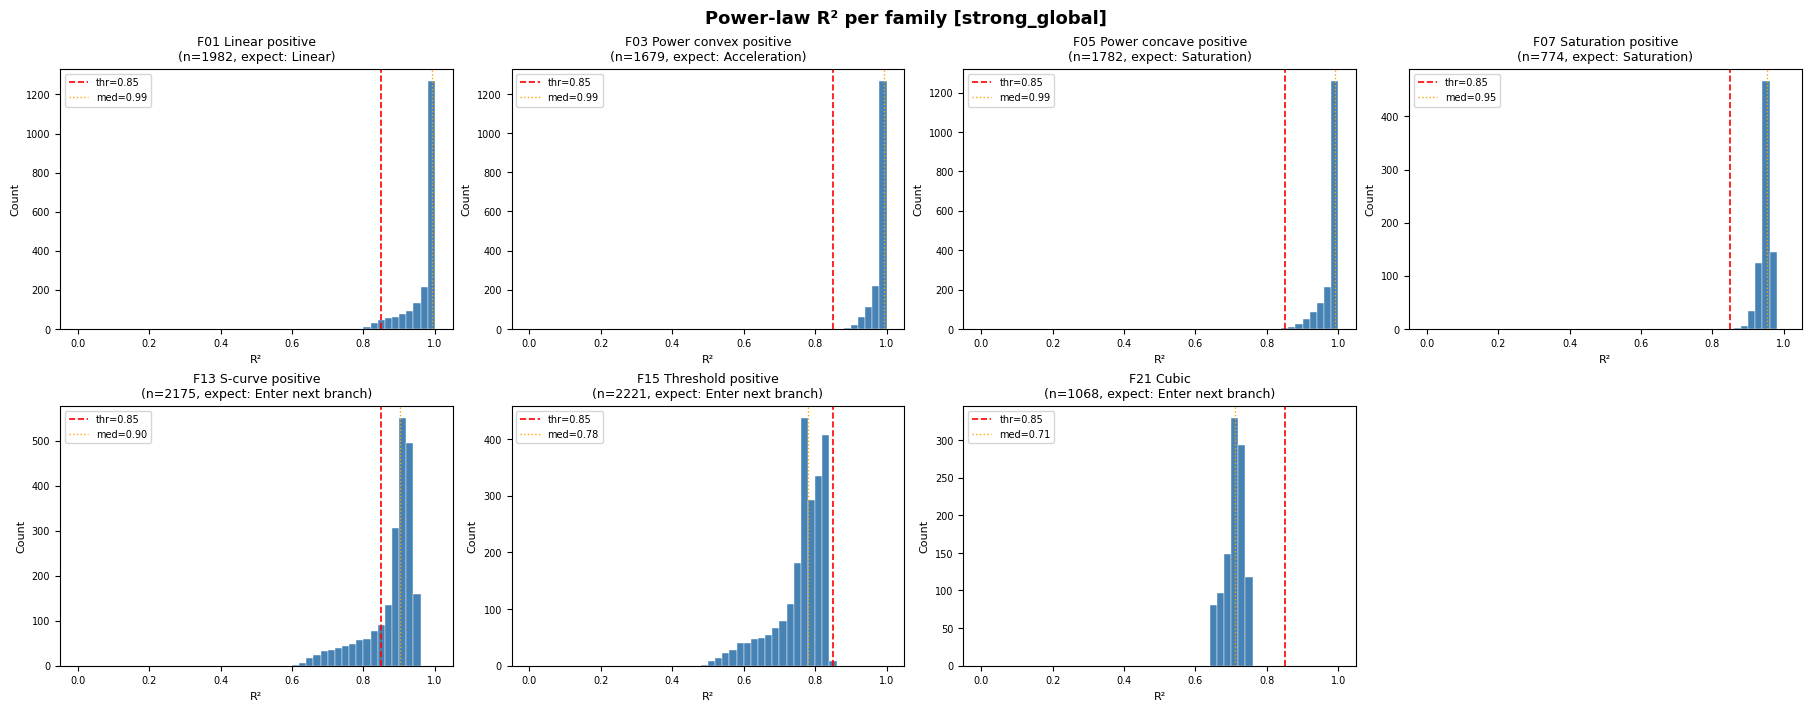

,Family,Expected,n,median R²,mean R²,P10,P25,P75,P90,% >= 0.85
0,F01 Linear positive,Linear,1982,0.991,0.969,0.898,0.959,0.996,0.998,96.8%
1,F03 Power convex positive,Acceleration,1679,0.993,0.985,0.956,0.981,0.997,0.999,100.0%
2,F05 Power concave positive,Saturation,1782,0.992,0.980,0.940,0.974,0.996,0.998,100.0%
3,F07 Saturation positive,Saturation,774,0.952,0.948,0.929,0.942,0.958,0.963,100.0%
4,F13 S-curve positive,Enter next branch,2175,0.903,0.879,0.768,0.862,0.931,0.939,77.8%
5,F15 Threshold positive,Enter next branch,2221,0.779,0.760,0.649,0.740,0.813,0.827,0.0%
6,F21 Cubic,Enter next branch,1068,0.710,0.708,0.665,0.691,0.727,0.743,0.0%



=== Power-law R² distribution [intermediate_global] ===


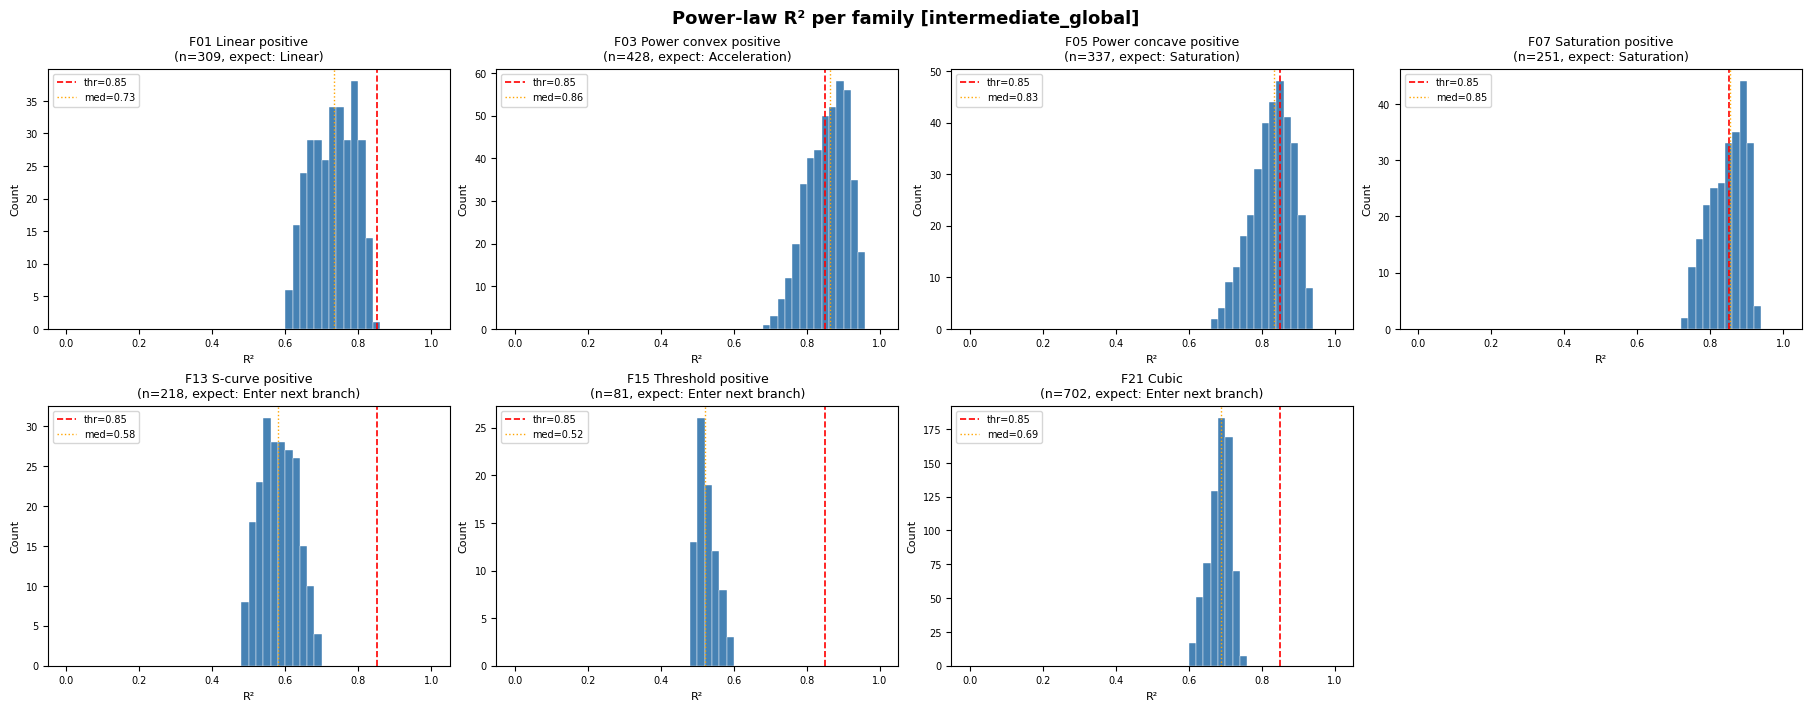

,Family,Expected,n,median R²,mean R²,P10,P25,P75,P90,% >= 0.85
0,F01 Linear positive,Linear,309,0.734,0.731,0.648,0.681,0.781,0.805,0.0%
1,F03 Power convex positive,Acceleration,428,0.862,0.856,0.779,0.815,0.901,0.924,57.0%
2,F05 Power concave positive,Saturation,337,0.833,0.828,0.748,0.791,0.871,0.896,38.6%
3,F07 Saturation positive,Saturation,251,0.855,0.847,0.775,0.811,0.889,0.906,53.0%
4,F13 S-curve positive,Enter next branch,218,0.581,0.582,0.514,0.543,0.620,0.648,0.0%
5,F15 Threshold positive,Enter next branch,81,0.522,0.527,0.497,0.506,0.544,0.564,0.0%
6,F21 Cubic,Enter next branch,702,0.690,0.685,0.641,0.666,0.709,0.721,0.0%


In [308]:
if RUN_SIMPLE_ANALYSIS:
    import matplotlib.pyplot as plt

    for _gate in MIC_ANALYSIS_GATES:
        _mask_gate = (data['gate1'] == _gate).values
        _mask_simple_gate = (data['gate2'] == 'Simple').values & _mask_gate
        _simple_data = data.loc[_mask_simple_gate].copy()
        if len(_simple_data) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== Power-law R² distribution [{_gate}] ===')
        print(f'{"="*60}')

        families = sorted(_simple_data['family_id'].unique())
        n_fam = len(families)
        ncols = min(n_fam, 4)
        nrows = math.ceil(n_fam / ncols) if ncols else 1

        fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows), constrained_layout=True)
        axes = np.array(axes).flatten() if n_fam > 1 else [axes]

        for ax, fid in zip(axes, families):
            r2_vals = _simple_data.loc[_simple_data['family_id'] == fid, 'pw_r2'].dropna()
            fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
            expected = EXPECTED_POWER_ROUTE.get(fid, 'Enter next branch')
            ax.hist(r2_vals, bins=50, range=(0, 1), color='steelblue', edgecolor='white', linewidth=0.3)
            ax.axvline(R2_POWER_THRESHOLD, color='red', ls='--', lw=1.2, label=f'thr={R2_POWER_THRESHOLD}')
            median_r2 = r2_vals.median() if len(r2_vals) > 0 else 0
            ax.axvline(median_r2, color='orange', ls=':', lw=1, label=f'med={median_r2:.2f}')
            ax.set_title(f'{fid} {fname}\n(n={len(r2_vals)}, expect: {expected})', fontsize=9)
            ax.set_xlabel('R²', fontsize=8)
            ax.set_ylabel('Count', fontsize=8)
            ax.tick_params(labelsize=7)
            ax.legend(fontsize=7)

        for ax in axes[n_fam:]:
            ax.set_visible(False)
        fig.suptitle(f'Power-law R² per family [{_gate}]', fontsize=13, fontweight='bold')
        plt.show()

        # Summary table: percentiles
        rows = []
        for fid in families:
            r2_vals = _simple_data.loc[_simple_data['family_id'] == fid, 'pw_r2'].dropna()
            fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
            expected = EXPECTED_POWER_ROUTE.get(fid, 'Enter next branch')
            pct_above = (r2_vals >= R2_POWER_THRESHOLD).mean() if len(r2_vals) else 0
            rows.append({
                'Family': f'{fid} {fname}',
                'Expected': expected,
                'n': len(r2_vals),
                'median R²': f'{r2_vals.median():.3f}' if len(r2_vals) else 'N/A',
                'mean R²': f'{r2_vals.mean():.3f}' if len(r2_vals) else 'N/A',
                'P10': f'{r2_vals.quantile(0.1):.3f}' if len(r2_vals) else 'N/A',
                'P25': f'{r2_vals.quantile(0.25):.3f}' if len(r2_vals) else 'N/A',
                'P75': f'{r2_vals.quantile(0.75):.3f}' if len(r2_vals) else 'N/A',
                'P90': f'{r2_vals.quantile(0.9):.3f}' if len(r2_vals) else 'N/A',
                f'% >= {R2_POWER_THRESHOLD}': f'{pct_above:.1%}',
            })
        display(pd.DataFrame(rows))

In [309]:
if RUN_SIMPLE_ANALYSIS:
    R2_THRESHOLDS = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.98]

    def _route_at_threshold(row, threshold):
        if CLASSIFICATION_ORDER == 'linear_first':
            if not np.isnan(row['pw_b']) and abs(row['pw_b'] - 1) <= LINEAR_B_TOLERANCE:
                return 'Linear'
            if np.isnan(row['pw_r2']) or row['pw_r2'] < threshold:
                return 'Enter next branch'
            curv = row['pw_a'] * row['pw_b'] * (row['pw_b'] - 1)
            if (row['pw_a'] > 0 and curv < 0) or (row['pw_a'] < 0 and curv > 0):
                return 'Saturation'
            return 'Acceleration'
        else:
            if np.isnan(row['pw_r2']) or row['pw_r2'] < threshold:
                return 'Enter next branch'
            b = row['pw_b']
            a = row['pw_a']
            if abs(b - 1) <= LINEAR_B_TOLERANCE:
                return 'Linear'
            curv = a * b * (b - 1)
            if (a > 0 and curv < 0) or (a < 0 and curv > 0):
                return 'Saturation'
            return 'Acceleration'

    for _gate in MIC_ANALYSIS_GATES:
        _mask_gate = (data['gate1'] == _gate).values
        _mask_simple_gate = (data['gate2'] == 'Simple').values & _mask_gate
        _simple_data = data.loc[_mask_simple_gate].copy()
        if len(_simple_data) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== R² threshold sweep [{_gate}] (mode={CLASSIFICATION_ORDER}) ===')
        print(f'{"="*60}')

        rows = []
        for thr in R2_THRESHOLDS:
            _simple_data['_route'] = _simple_data.apply(lambda r: _route_at_threshold(r, thr), axis=1)
            _simple_data['_expected'] = _simple_data['family_id'].map(EXPECTED_POWER_ROUTE).fillna('Enter next branch')
            _simple_data['_correct'] = _simple_data['_route'] == _simple_data['_expected']

            per_family = _simple_data.groupby('family_id').agg(
                total=('case_id', 'size'),
                correct=('_correct', 'sum'),
            )

            row_data = {'R² threshold': thr}
            for fid in sorted(per_family.index):
                fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
                n_correct = int(per_family.loc[fid, 'correct'])
                n_total = int(per_family.loc[fid, 'total'])
                row_data[fname] = f'{n_correct}/{n_total} ({n_correct/n_total:.1%})'
            overall_correct = int(per_family['correct'].sum())
            overall_total = int(per_family['total'].sum())
            row_data['Overall'] = f'{overall_correct}/{overall_total} ({overall_correct/overall_total:.1%})'
            rows.append(row_data)

        sweep_df = pd.DataFrame(rows).set_index('R² threshold')
        display(sweep_df.T)


=== R² threshold sweep [strong_global] (mode=r2_first) ===


R² threshold,0.70,0.75,0.80,0.85,0.90,0.95,0.98
Linear positive,1887/1982 (95.2%),1887/1982 (95.2%),1887/1982 (95.2%),1843/1982 (93.0%),1740/1982 (87.8%),1543/1982 (77.9%),1267/1982 (63.9%)
Power convex positive,1679/1679 (100.0%),1679/1679 (100.0%),1679/1679 (100.0%),1679/1679 (100.0%),1675/1679 (99.8%),1549/1679 (92.3%),1264/1679 (75.3%)
Power concave positive,1782/1782 (100.0%),1782/1782 (100.0%),1782/1782 (100.0%),1782/1782 (100.0%),1742/1782 (97.8%),1544/1782 (86.6%),1257/1782 (70.5%)
Saturation positive,774/774 (100.0%),774/774 (100.0%),774/774 (100.0%),774/774 (100.0%),767/774 (99.1%),429/774 (55.4%),0/774 (0.0%)
S-curve positive,80/2175 (3.7%),176/2175 (8.1%),304/2175 (14.0%),482/2175 (22.2%),970/2175 (44.6%),2175/2175 (100.0%),2175/2175 (100.0%)
Threshold positive,371/2221 (16.7%),655/2221 (29.5%),1469/2221 (66.1%),2221/2221 (100.0%),2221/2221 (100.0%),2221/2221 (100.0%),2221/2221 (100.0%)
Cubic,327/1068 (30.6%),1015/1068 (95.0%),1068/1068 (100.0%),1068/1068 (100.0%),1068/1068 (100.0%),1068/1068 (100.0%),1068/1068 (100.0%)
Overall,6900/11681 (59.1%),7968/11681 (68.2%),8963/11681 (76.7%),9849/11681 (84.3%),10183/11681 (87.2%),10529/11681 (90.1%),9252/11681 (79.2%)



=== R² threshold sweep [intermediate_global] (mode=r2_first) ===


R² threshold,0.70,0.75,0.80,0.85,0.90,0.95,0.98
Linear positive,122/309 (39.5%),76/309 (24.6%),25/309 (8.1%),0/309 (0.0%),0/309 (0.0%),0/309 (0.0%),0/309 (0.0%)
Power convex positive,427/428 (99.8%),410/428 (95.8%),351/428 (82.0%),244/428 (57.0%),109/428 (25.5%),5/428 (1.2%),0/428 (0.0%)
Power concave positive,331/337 (98.2%),302/337 (89.6%),239/337 (70.9%),130/337 (38.6%),30/337 (8.9%),0/337 (0.0%),0/337 (0.0%)
Saturation positive,251/251 (100.0%),244/251 (97.2%),200/251 (79.7%),133/251 (53.0%),37/251 (14.7%),0/251 (0.0%),0/251 (0.0%)
S-curve positive,218/218 (100.0%),218/218 (100.0%),218/218 (100.0%),218/218 (100.0%),218/218 (100.0%),218/218 (100.0%),218/218 (100.0%)
Threshold positive,81/81 (100.0%),81/81 (100.0%),81/81 (100.0%),81/81 (100.0%),81/81 (100.0%),81/81 (100.0%),81/81 (100.0%)
Cubic,456/702 (65.0%),702/702 (100.0%),702/702 (100.0%),702/702 (100.0%),702/702 (100.0%),702/702 (100.0%),702/702 (100.0%)
Overall,1886/2326 (81.1%),2033/2326 (87.4%),1816/2326 (78.1%),1508/2326 (64.8%),1177/2326 (50.6%),1006/2326 (43.3%),1001/2326 (43.0%)


In [310]:
# # ── KL/QR/HD diagnostic for Simple-path R²-fail pool ──
# from scipy.stats import gaussian_kde
# try:
#     from diptest import diptest as diptest_func
# except ImportError:
#     diptest_func = None
#     print('WARNING: diptest not installed, HD test will be skipped')

# def _cond_density_inline(x, y, n_grid_x=30, n_grid_y=50):
#     if KL_METHOD == 'kde':
#         gx = np.linspace(x.min(), x.max(), n_grid_x)
#         gy = np.linspace(y.min(), y.max(), n_grid_y)
#         GX, GY = np.meshgrid(gx, gy, indexing='ij')
#         grid_pts = np.vstack([GX.ravel(), GY.ravel()])
#         try:
#             kde2d = gaussian_kde(np.vstack([x, y]), bw_method='silverman')
#             density_2d = kde2d(grid_pts).reshape(n_grid_x, n_grid_y)
#         except np.linalg.LinAlgError:
#             return None
#         kde_x = gaussian_kde(x, bw_method='silverman')
#         p_x = kde_x(gx)
#         p_x = p_x / p_x.sum()
#         p_cond = np.zeros_like(density_2d)
#         for ix in range(n_grid_x):
#             col_sum = density_2d[ix].sum()
#             if col_sum > 1e-20:
#                 p_cond[ix] = density_2d[ix] / col_sum
#             else:
#                 p_cond[ix] = 1.0 / n_grid_y
#         kde_y = gaussian_kde(y, bw_method='silverman')
#         p_marginal_y = kde_y(gy)
#         p_marginal_y = p_marginal_y / p_marginal_y.sum()
#         return gx, gy, p_cond, p_marginal_y, p_x
#     else:
#         hist2d, xedges, yedges = np.histogram2d(x, y, bins=[n_grid_x, n_grid_y])
#         gx = 0.5 * (xedges[:-1] + xedges[1:])
#         gy = 0.5 * (yedges[:-1] + yedges[1:])
#         hist2d = hist2d + 1e-10
#         p_x = hist2d.sum(axis=1)
#         p_x = p_x / p_x.sum()
#         p_cond = hist2d / hist2d.sum(axis=1, keepdims=True)
#         p_marginal_y = hist2d.sum(axis=0)
#         p_marginal_y = p_marginal_y / p_marginal_y.sum()
#         return gx, gy, p_cond, p_marginal_y, p_x

# def _kl_inline(p_cond, p_marginal_y, p_x):
#     kl = 0.0
#     for ix in range(p_cond.shape[0]):
#         pc = np.maximum(p_cond[ix], 1e-20)
#         pm = np.maximum(p_marginal_y, 1e-20)
#         kl += p_x[ix] * np.sum(pc * np.log(pc / pm))
#     return float(kl)

# def _qr_inline(p_cond, gy):
#     iqrs = []
#     for ix in range(p_cond.shape[0]):
#         cdf = np.cumsum(p_cond[ix])
#         cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
#         q05 = gy[np.searchsorted(cdf, 0.05)]
#         q95 = gy[np.searchsorted(cdf, 0.95, side='right').clip(max=len(gy)-1)]
#         iqrs.append(q95 - q05)
#     iqrs = np.array(iqrs)
#     q01_iqr = np.percentile(iqrs, 1)
#     q99_iqr = np.percentile(iqrs, 99)
#     if q01_iqr < 1e-10:
#         return np.nan
#     return float(q99_iqr / q01_iqr)

# def _klqr_inline(x, y, n_perm=99):
#     valid = np.isfinite(x) & np.isfinite(y)
#     x, y = x[valid], y[valid]
#     if len(x) < 20:
#         return np.nan, np.nan, np.nan, np.nan
#     result = _cond_density_inline(x, y)
#     if result is None:
#         return np.nan, np.nan, np.nan, np.nan
#     gx, gy, p_cond, p_marginal_y, p_x = result
#     kl_obs = _kl_inline(p_cond, p_marginal_y, p_x)
#     qr_obs = _qr_inline(p_cond, gy)
#     kl_count = 0
#     qr_count = 0
#     rng = np.random.RandomState(42)
#     for _ in range(n_perm):
#         y_perm = rng.permutation(y)
#         res_perm = _cond_density_inline(x, y_perm)
#         if res_perm is None:
#             continue
#         _, gy_p, pc_p, pm_p, px_p = res_perm
#         if _kl_inline(pc_p, pm_p, px_p) >= kl_obs:
#             kl_count += 1
#         qr_perm = _qr_inline(pc_p, gy_p)
#         if not np.isnan(qr_perm) and not np.isnan(qr_obs) and qr_perm >= qr_obs:
#             qr_count += 1
#     kl_p = float((kl_count + 1) / (n_perm + 1))
#     qr_p = float((qr_count + 1) / (n_perm + 1)) if not np.isnan(qr_obs) else np.nan
#     return kl_obs, kl_p, qr_obs, qr_p

# def _hd_inline(y):
#     valid = np.isfinite(y)
#     y = y[valid]
#     if len(y) < 10 or diptest_func is None:
#         return np.nan, np.nan
#     stat, p = diptest_func(y)
#     return float(stat), float(p)

# for _gate in MIC_ANALYSIS_GATES:
#     r2_fail_data = data[(data['pw_label'] == 'r2_fail') & (data['gate2'] == 'Simple') & (data['gate1'] == _gate)].copy()
#     n_r2_fail = len(r2_fail_data)
#     print(f'\n{"="*60}')
#     print(f'=== KL/QR/HD: Simple R2-fail [{_gate}] ({n_r2_fail} cases, {KL_METHOD}) ===')
#     print(f'{"="*60}')

#     if n_r2_fail > 0:
#         r2fail_results = []
#         for idx, row in tqdm(r2_fail_data.iterrows(), total=n_r2_fail, desc=f'KL/QR/HD R2-fail [{_gate}]'):
#             pi = int(row['_pt_idx'])
#             x = x_all[pi].astype(np.float64)
#             y = y_all[pi].astype(np.float64)
#             kl_stat, kl_p, qr_stat, qr_p = _klqr_inline(x, y)
#             hd_stat, hd_p = _hd_inline(y)
#             r2fail_results.append({
#                 'case_id': row['case_id'], 'family_id': row['family_id'],
#                 'kl_stat': kl_stat, 'kl_p': kl_p, 'kl_sig': kl_p < 0.05 if not np.isnan(kl_p) else np.nan,
#                 'qr_stat': qr_stat, 'qr_p': qr_p, 'qr_sig': qr_p < 0.05 if not np.isnan(qr_p) else np.nan,
#                 'hd_stat': hd_stat, 'hd_p': hd_p, 'hd_sig': hd_p < 0.05 if not np.isnan(hd_p) else np.nan,
#             })

#         r2fail_df = pd.DataFrame(r2fail_results)
#         r2fail_df['family_name'] = r2fail_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
#         print('Significance rates per family:')
#         _rf_summary = r2fail_df.groupby(['family_id', 'family_name']).agg(
#             n=('case_id', 'size'),
#             KL_mean=('kl_stat', 'mean'),
#             KL_sig=('kl_sig', lambda s: count_percent(int(s.sum()), len(s))),
#             QR_mean=('qr_stat', 'mean'),
#             QR_sig=('qr_sig', lambda s: count_percent(int(s.sum()), len(s))),
#             HD_mean=('hd_stat', 'mean'),
#             HD_sig=('hd_sig', lambda s: count_percent(int(s.sum()), len(s))),
#         ).round(4)
#         display(_rf_summary)

#         # ── Scatter plots: 1 sample per family from R2-fail pool (prefer HD-significant) ──
#         import matplotlib.pyplot as plt
#         _fam_ids = sorted(r2fail_df['family_id'].unique())
#         n_fam = len(_fam_ids)
#         if n_fam > 0:
#             ncols = min(n_fam, 5)
#             nrows = math.ceil(n_fam / ncols)
#             fig, axes = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 3*nrows), constrained_layout=True)
#             axes = np.array(axes).flatten() if n_fam > 1 else [axes]
#             for ax, _pfid in zip(axes, _fam_ids):
#                 _pf_df = r2fail_df[r2fail_df['family_id'] == _pfid]
#                 _pf_sig = _pf_df[_pf_df['hd_sig'] == True]
#                 if len(_pf_sig) > 0:
#                     _pick = _pf_sig.sample(n=1, random_state=42).iloc[0]
#                     _tag = 'HD+'
#                 else:
#                     _pick = _pf_df.sample(n=1, random_state=42).iloc[0]
#                     _tag = 'HD-'
#                 _pi = int(r2_fail_data.loc[r2_fail_data['case_id'] == _pick['case_id'], '_pt_idx'].iloc[0])
#                 _x = x_all[_pi].astype(np.float64)
#                 _y = y_all[_pi].astype(np.float64)
#                 _fname = FAMILY_CATALOGUE.get(_pfid, {}).get('name', '')
#                 ax.scatter(_x, _y, s=3, alpha=0.4)
#                 ax.set_title(f'{_pfid} {_fname} ({_tag})', fontsize=8)
#                 ax.tick_params(labelsize=7)
#             for ax in axes[n_fam:]:
#                 ax.set_visible(False)
#             fig.suptitle(f'R²-fail sample scatter [{_gate}]', fontsize=12)
#             plt.show()
#     else:
#         print('No R2-fail cases.')

## Step 1 — Branch Detection (Conditional Dip Test)

For each x-bin, test whether Y|X is multimodal using Hartigan's dip test.
Persistent bimodality across bins → branching signal (e.g. F23 Two Lines).
Also counts the number of modes per bin via KDE peak detection.

In [311]:
if RUN_METHOD_C:
    from scipy.signal import argrelextrema
    from scipy.stats import gaussian_kde
    try:
        from diptest import diptest as diptest_func
    except ImportError:
        diptest_func = None
        print('WARNING: diptest not installed')

    def conditional_dip_analysis(x, y, n_bins=8, kde_bw='silverman'):
        """Per-bin dip test + KDE mode count on Y|X."""
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        n = len(x)
        if n < 30 or diptest_func is None:
            return None

        bin_edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
        bin_edges[0] -= 1e-10
        bin_idx = np.digitize(x, bin_edges[1:-1])

        bin_results = []
        for b in range(n_bins):
            y_bin = y[bin_idx == b]
            n_bin = len(y_bin)
            if n_bin < 10:
                bin_results.append({
                    'bin': b, 'n': n_bin,
                    'dip_stat': np.nan, 'dip_p': np.nan, 'dip_sig': False,
                    'n_modes': np.nan,
                })
                continue

            dip_stat, dip_p = diptest_func(y_bin)
            dip_sig = dip_p < 0.05

            # KDE mode count
            try:
                kde = gaussian_kde(y_bin, bw_method=kde_bw)
                y_grid = np.linspace(y_bin.min(), y_bin.max(), 200)
                density = kde(y_grid)
                peaks = argrelextrema(density, np.greater, order=5)[0]
                n_modes = max(len(peaks), 1)
            except Exception:
                n_modes = np.nan

            bin_results.append({
                'bin': b, 'n': n_bin,
                'dip_stat': float(dip_stat), 'dip_p': float(dip_p),
                'dip_sig': bool(dip_sig), 'n_modes': int(n_modes) if not np.isnan(n_modes) else np.nan,
            })

        n_sig = sum(1 for r in bin_results if r['dip_sig'])
        frac_sig = n_sig / n_bins
        mode_counts = [r['n_modes'] for r in bin_results if not np.isnan(r['n_modes'])]
        median_modes = float(np.median(mode_counts)) if mode_counts else np.nan

        return {
            'bin_results': bin_results,
            'n_bins': n_bins,
            'n_sig_bins': n_sig,
            'frac_sig': frac_sig,
            'median_modes': median_modes,
        }

    print('Conditional dip test helpers defined.')

Conditional dip test helpers defined.


In [312]:
if RUN_METHOD_C:
    import time as _time
    cond_dip_dfs = {}

    for _gate in MIC_ANALYSIS_GATES:
        complex_data = complex_datas.get(_gate)
        if complex_data is None or len(complex_data) == 0:
            print(f'[{_gate}] No complex cases, skipping Method C.')
            continue

        print(f'\n{"="*60}')
        print(f'=== Conditional Dip Test [{_gate}] — {len(complex_data):,} cases ===')
        print(f'{"="*60}')

        cond_dip_results = []
        t0 = _time.time()

        for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc=f'Cond. dip [{_gate}]'):
            pi = int(row['_pt_idx'])
            x = x_all[pi].astype(np.float64)
            y = y_all[pi].astype(np.float64)
            result = conditional_dip_analysis(x, y)

            cid = row['case_id']
            fid = row['family_id']

            if result is not None:
                cond_dip_results.append({
                    'case_id': cid, 'family_id': fid,
                    'n_sig_bins': result['n_sig_bins'],
                    'frac_sig': result['frac_sig'],
                    'median_modes': result['median_modes'],
                    'is_branch': result['frac_sig'] >= 0.5,
                })
            else:
                cond_dip_results.append({
                    'case_id': cid, 'family_id': fid,
                    'n_sig_bins': 0, 'frac_sig': 0.0,
                    'median_modes': np.nan, 'is_branch': False,
                })

        print(f'Conditional dip test: {len(cond_dip_results):,} cases in {_time.time()-t0:.1f}s')

        cond_dip_df = pd.DataFrame(cond_dip_results)
        cond_dip_df['family_name'] = cond_dip_df['family_id'].map(
            lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')
        )
        cond_dip_dfs[_gate] = cond_dip_df


=== Conditional Dip Test [strong_global] — 8,090 cases ===


Cond. dip [strong_global]: 100%|██████████| 8090/8090 [00:40<00:00, 199.42it/s]


Conditional dip test: 8,090 cases in 40.6s

=== Conditional Dip Test [intermediate_global] — 5,000 cases ===


Cond. dip [intermediate_global]: 100%|██████████| 5000/5000 [00:30<00:00, 161.86it/s]

Conditional dip test: 5,000 cases in 30.9s



=== Method C: Branch Detection [strong_global] ===
Rule: >= 50% of x-bins with dip p<0.05 -> Branch
Also reports median KDE mode count per case



,,n,frac_sig_mean,frac_sig_std,median_modes_mean,n_branch,branch_rate
family_id,family_name,,,,,,
F01,Linear positive,63,0.000,0.000,1.000,0,0 (0.0%)
F07,Saturation positive,55,0.030,0.072,1.036,0,0 (0.0%)
F13,S-curve positive,482,0.000,0.000,1.000,0,0 (0.0%)
F15,Threshold positive,2222,0.011,0.035,1.053,0,0 (0.0%)
F18,Quadratic valley (U),1848,0.008,0.032,1.136,0,0 (0.0%)
F21,Cubic,1068,0.019,0.045,1.072,0,0 (0.0%)
F22,Oscillation,1990,0.015,0.042,1.414,0,0 (0.0%)
F23,Two Lines,310,0.848,0.052,2.000,310,310 (100.0%)
F25,Multi-regime threshold,32,0.051,0.070,1.797,0,0 (0.0%)


,family_name,Expected,Total,Non-branch,Branch,Accuracy
family_id,,,,,,
F01,Linear positive,Non-branch,63 (100.0%),63 (100.0%),0 (0.0%),63/63 (100.0%)
F07,Saturation positive,Non-branch,55 (100.0%),55 (100.0%),0 (0.0%),55/55 (100.0%)
F13,S-curve positive,Non-branch,482 (100.0%),482 (100.0%),0 (0.0%),482/482 (100.0%)
F15,Threshold positive,Non-branch,"2,222 (100.0%)","2,222 (100.0%)",0 (0.0%),2222/2222 (100.0%)
F18,Quadratic valley (U),Non-branch,"1,848 (100.0%)","1,848 (100.0%)",0 (0.0%),1848/1848 (100.0%)
F21,Cubic,Non-branch,"1,068 (100.0%)","1,068 (100.0%)",0 (0.0%),1068/1068 (100.0%)
F22,Oscillation,Non-branch,"1,990 (100.0%)","1,990 (100.0%)",0 (0.0%),1990/1990 (100.0%)
F23,Two Lines,Non-branch,310 (100.0%),0 (0.0%),310 (100.0%),0/310 (0.0%)
F25,Multi-regime threshold,Non-branch,32 (100.0%),32 (100.0%),0 (0.0%),32/32 (100.0%)



Overall accuracy: 7780/8090 (96.2%)


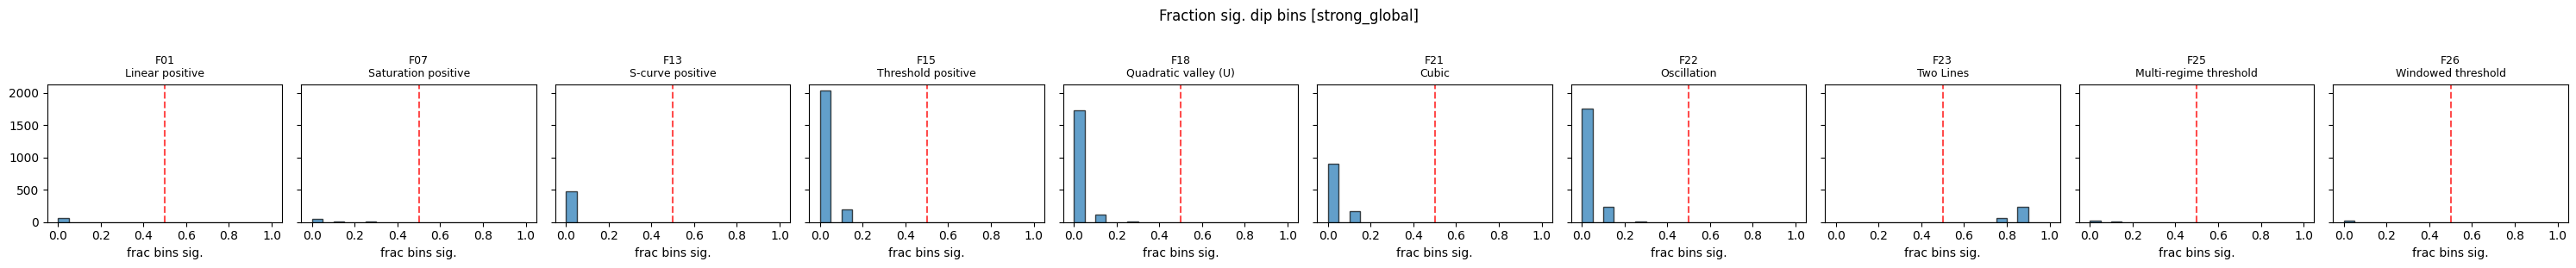


=== Method C: Branch Detection [intermediate_global] ===
Rule: >= 50% of x-bins with dip p<0.05 -> Branch
Also reports median KDE mode count per case



,,n,frac_sig_mean,frac_sig_std,median_modes_mean,n_branch,branch_rate
family_id,family_name,,,,,,
F01,Linear positive,309,0.000,0.000,1.003,0,0 (0.0%)
F03,Power convex positive,184,0.000,0.000,1.000,0,0 (0.0%)
F05,Power concave positive,207,0.004,0.021,1.000,0,0 (0.0%)
F07,Saturation positive,700,0.010,0.035,1.000,0,0 (0.0%)
F13,S-curve positive,232,0.000,0.000,1.000,0,0 (0.0%)
F15,Threshold positive,206,0.007,0.028,1.022,0,0 (0.0%)
F18,Quadratic valley (U),333,0.000,0.000,1.011,0,0 (0.0%)
F21,Cubic,702,0.007,0.029,1.004,0,0 (0.0%)
F22,Oscillation,287,0.004,0.022,1.002,0,0 (0.0%)


,family_name,Expected,Total,Non-branch,Branch,Accuracy
family_id,,,,,,
F01,Linear positive,Non-branch,309 (100.0%),309 (100.0%),0 (0.0%),309/309 (100.0%)
F03,Power convex positive,Non-branch,184 (100.0%),184 (100.0%),0 (0.0%),184/184 (100.0%)
F05,Power concave positive,Non-branch,207 (100.0%),207 (100.0%),0 (0.0%),207/207 (100.0%)
F07,Saturation positive,Non-branch,700 (100.0%),700 (100.0%),0 (0.0%),700/700 (100.0%)
F13,S-curve positive,Non-branch,232 (100.0%),232 (100.0%),0 (0.0%),232/232 (100.0%)
F15,Threshold positive,Non-branch,206 (100.0%),206 (100.0%),0 (0.0%),206/206 (100.0%)
F18,Quadratic valley (U),Non-branch,333 (100.0%),333 (100.0%),0 (0.0%),333/333 (100.0%)
F21,Cubic,Non-branch,702 (100.0%),702 (100.0%),0 (0.0%),702/702 (100.0%)
F22,Oscillation,Non-branch,287 (100.0%),287 (100.0%),0 (0.0%),287/287 (100.0%)



Overall accuracy: 3709/5000 (74.2%)


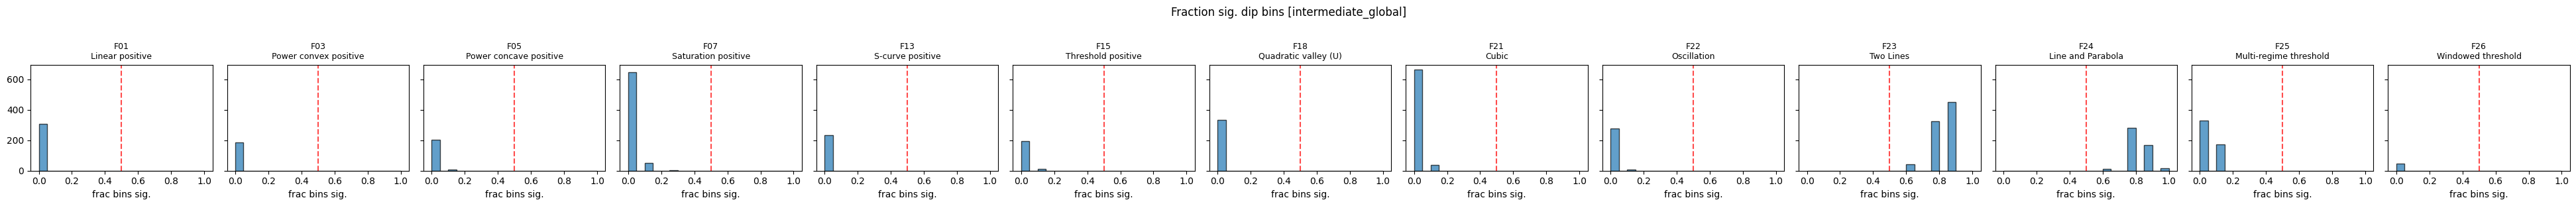

[strong_global] Non-branch: 7,780 / 8,090
[intermediate_global] Non-branch: 3,709 / 5,000


In [313]:
if RUN_METHOD_C:
    import matplotlib.pyplot as plt
    BRANCH_FRAC_THRESHOLD = 0.5

    EXPECTED_BRANCH = {}
    for fid, props in FAMILY_CATALOGUE.items():
        if props.get('special_shape', '') in ('two_lines', 'multi_branch'):
            EXPECTED_BRANCH[fid] = 'Branch'
        else:
            EXPECTED_BRANCH[fid] = 'Non-branch'

    for _gate in MIC_ANALYSIS_GATES:
        cond_dip_df = cond_dip_dfs.get(_gate)
        if cond_dip_df is None or len(cond_dip_df) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== Method C: Branch Detection [{_gate}] ===')
        print(f'{"="*60}')
        print(f'Rule: >= {BRANCH_FRAC_THRESHOLD:.0%} of x-bins with dip p<0.05 -> Branch')
        print(f'Also reports median KDE mode count per case\n')

        _cd_summary = cond_dip_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            frac_sig_mean=('frac_sig', 'mean'),
            frac_sig_std=('frac_sig', 'std'),
            median_modes_mean=('median_modes', 'mean'),
            n_branch=('is_branch', 'sum'),
        )
        _cd_summary['branch_rate'] = _cd_summary.apply(
            lambda r: count_percent(int(r['n_branch']), int(r['n'])), axis=1
        )
        _cd_summary = _cd_summary.round(3)
        display(_cd_summary)

        cond_dip_df['cond_dip_label'] = np.where(cond_dip_df['is_branch'], 'Branch', 'Non-branch')
        cond_dip_dfs[_gate] = cond_dip_df

        _cd_ct = cond_dip_df.groupby(['family_id', 'cond_dip_label']).size().unstack(fill_value=0)
        _cd_ct['total'] = _cd_ct.sum(axis=1)
        _cd_col_order = ['Non-branch', 'Branch']
        _cd_display = [c for c in _cd_col_order if c in _cd_ct.columns]

        _cd_out = pd.DataFrame(index=_cd_ct.index)
        _cd_out['family_name'] = _cd_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _cd_out['Expected'] = _cd_out.index.map(lambda f: EXPECTED_BRANCH.get(f, 'N/A'))
        _cd_out['Total'] = [count_percent(n, n) for n in _cd_ct['total']]
        for col in _cd_display:
            _cd_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_cd_ct[col], _cd_ct['total'])]

        accuracy = []
        for fid in _cd_out.index:
            exp = EXPECTED_BRANCH.get(fid)
            total = int(_cd_ct.loc[fid, 'total'])
            if exp is None or exp not in _cd_ct.columns:
                accuracy.append('N/A')
            else:
                n_correct = int(_cd_ct.loc[fid, exp])
                accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
        _cd_out['Accuracy'] = accuracy
        display(_cd_out)

        cond_dip_df['_expected'] = cond_dip_df['family_id'].map(EXPECTED_BRANCH)
        _eval_c = cond_dip_df[cond_dip_df['_expected'].notna()].copy()
        if len(_eval_c) > 0:
            _eval_c['_correct'] = _eval_c['cond_dip_label'] == _eval_c['_expected']
            n_tc = len(_eval_c)
            n_cc = int(_eval_c['_correct'].sum())
            print(f'\nOverall accuracy: {n_cc}/{n_tc} ({n_cc/n_tc:.1%})')

        families_c = sorted(cond_dip_df['family_id'].unique())
        n_fam = len(families_c)
        if n_fam > 0:
            fig, axes = plt.subplots(1, n_fam, figsize=(3*n_fam, 3), sharey=True)
            if n_fam == 1:
                axes = [axes]
            for ax, fid in zip(axes, families_c):
                subset = cond_dip_df[cond_dip_df['family_id'] == fid]
                fname = subset['family_name'].iloc[0] if len(subset) > 0 else fid
                ax.hist(subset['frac_sig'].dropna(), bins=20, range=(0, 1),
                        alpha=0.7, edgecolor='black')
                ax.set_title(f'{fid}\n{fname}', fontsize=9)
                ax.set_xlabel('frac bins sig.')
                ax.axvline(BRANCH_FRAC_THRESHOLD, color='red', ls='--', alpha=0.7)
            fig.suptitle(f'Fraction sig. dip bins [{_gate}]', y=1.02)
            plt.tight_layout()
            plt.show()

# ── Create non-branch subset for downstream steps ──
non_branch_datas = {}
for _gate in MIC_ANALYSIS_GATES:
    _cd = complex_datas.get(_gate)
    if _cd is None:
        continue
    if RUN_METHOD_C:
        _cdd = cond_dip_dfs.get(_gate)
        if _cdd is not None:
            _nb_ids = set(_cdd[~_cdd['is_branch']]['case_id'])
            non_branch_datas[_gate] = _cd[_cd['case_id'].isin(_nb_ids)].copy()
        else:
            non_branch_datas[_gate] = _cd.copy()
    else:
        non_branch_datas[_gate] = _cd.copy()
    print(f'[{_gate}] Non-branch: {len(non_branch_datas[_gate]):,} / {len(_cd):,}')

## Step 2 — Turning-point Detection (SiZer, non-branch cases)

Local-linear derivative with multiscale turning-point consensus.
Runs on **non-branch** cases only (branch cases removed in Step 1).
SiZer (SIgnificant ZERo crossings of derivatives) fits local linear regressions with Gaussian kernel weights at multiple bandwidths to estimate the first derivative across the domain, then counts zero crossings (sign changes) that persist across scales as stable turning points.

In [314]:
if RUN_METHOD_A:
    # ── Local-linear derivative with multiscale TP consensus ──
    
    
    def multiscale_tp_analysis(x, y, n_bandwidths=5, n_grid=200,
                               h_min=0.04, h_max=0.18,
                               interior=(0.05, 0.95),
                               min_run_frac=0.05,
                               flat_frac=FLAT_FRAC):
        """Compute local-linear derivative at multiple bandwidths, count turning points.
        
        Also computes width_ratio: fraction of interior with |β₁| > eps.
        """
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        n = len(x)
        if n < 20:
            return None
        
        x_min, x_max = x.min(), x.max()
        x_range = x_max - x_min
        if x_range < 1e-10:
            return None
        x_norm = (x - x_min) / x_range
        
        x_grid = np.linspace(0, 1, n_grid)
        bandwidths = np.geomspace(h_min, h_max, n_bandwidths)
        
        interior_mask = (x_grid >= interior[0]) & (x_grid <= interior[1])
        n_interior = interior_mask.sum()
        min_run_len = max(int(min_run_frac * n_interior), 3)
        
        per_bw = []
        deriv_matrix = np.zeros((n_bandwidths, n_grid))
        
        for bw_idx, h in enumerate(bandwidths):
            beta1_row = np.full(n_grid, np.nan)
            
            for gi, xg in enumerate(x_grid):
                w = np.exp(-0.5 * ((x_norm - xg) / h) ** 2)
                w_sum = w.sum()
                if w_sum < 1e-10:
                    continue
                
                dx = x_norm - xg
                s0 = w_sum
                s1 = (w * dx).sum()
                s2 = (w * dx ** 2).sum()
                denom = s0 * s2 - s1 ** 2
                if abs(denom) < 1e-20:
                    continue
                
                beta1 = (s0 * (w * dx * y).sum() - s1 * (w * y).sum()) / denom
                beta1_row[gi] = beta1
            
            deriv_matrix[bw_idx] = beta1_row
            
            interior_deriv = beta1_row[interior_mask]
            if np.any(np.isfinite(interior_deriv)):
                abs_deriv = np.abs(interior_deriv)
                ref_val = np.nanmax(abs_deriv) if FLAT_REF == 'max' else np.nanmedian(abs_deriv)
                eps = flat_frac * ref_val
            else:
                eps = 0.0
            
            # TP count
            tp_count, tp_positions = _count_stable_tps(
                interior_deriv, x_grid[interior_mask], min_run_len, eps
            )
            
            # Width ratio: fraction of interior with |β₁| > eps
            n_significant = np.sum(np.abs(interior_deriv) > eps)
            width_ratio = float(n_significant / n_interior) if n_interior > 0 else 0.0
            
            per_bw.append({
                'bw_index': bw_idx + 1,
                'bandwidth': float(h),
                'tp_count': int(tp_count),
                'tp_positions': tp_positions,
                'width_ratio': width_ratio,
            })
        
        n_2tp = sum(1 for bw in per_bw if bw['tp_count'] == 2)
        tp_stable = _check_tp_stability(per_bw)
        
        return {
            'per_bw': per_bw,
            'p_2tp': n_2tp / n_bandwidths,
            'n_2tp_bw': n_2tp,
            'n_bandwidths': n_bandwidths,
            'tp_stable': tp_stable,
            'deriv_matrix': deriv_matrix,
            'x_grid': x_grid,
        }
    
    
    def _count_stable_tps(deriv, x_positions, min_run_len, eps=0.0):
        """Count turning points from stable sign runs in the derivative."""
        n = len(deriv)
        if n < 2:
            return 0, []
        
        runs = []
        current_sign = 0
        current_start = 0
        
        for i in range(n):
            if np.isnan(deriv[i]) or abs(deriv[i]) < eps:
                if current_sign != 0 and (i - current_start) >= min_run_len:
                    runs.append((current_sign, current_start, i - 1))
                current_sign = 0
                continue
            
            s = 1 if deriv[i] > 0 else -1
            if s != current_sign:
                if current_sign != 0 and (i - current_start) >= min_run_len:
                    runs.append((current_sign, current_start, i - 1))
                current_sign = s
                current_start = i
        
        if current_sign != 0 and (n - current_start) >= min_run_len:
            runs.append((current_sign, current_start, n - 1))
        
        tp_count = 0
        tp_positions = []
        for i in range(1, len(runs)):
            if runs[i][0] != runs[i - 1][0]:
                tp_count += 1
                idx_mid = (runs[i - 1][2] + runs[i][1]) // 2
                if idx_mid < len(x_positions):
                    tp_positions.append(float(x_positions[idx_mid]))
        
        return tp_count, tp_positions
    
    
    def _check_tp_stability(per_bw):
        """Check if TP positions are stable across bandwidths that have 2 TPs."""
        bws_with_2tp = [bw for bw in per_bw if bw['tp_count'] == 2]
        if len(bws_with_2tp) < 2:
            return len(bws_with_2tp) == 1
        
        tp1_positions = [bw['tp_positions'][0] for bw in bws_with_2tp]
        tp2_positions = [bw['tp_positions'][1] for bw in bws_with_2tp]
        
        tp1_range = max(tp1_positions) - min(tp1_positions)
        tp2_range = max(tp2_positions) - min(tp2_positions)
        
        return tp1_range < 0.15 and tp2_range < 0.15
    
    print(f'Multiscale TP helpers defined.  FLAT_FRAC = {FLAT_FRAC}, FLAT_REF = {FLAT_REF!r}')

Multiscale TP helpers defined.  FLAT_FRAC = 0.05, FLAT_REF = 'max'


In [315]:
if RUN_METHOD_A:
    sizer_dfs = {}
    sizer_bw_dfs = {}

    for _gate in MIC_ANALYSIS_GATES:
        complex_data = non_branch_datas.get(_gate)
        if complex_data is None or len(complex_data) == 0:
            print(f'[{_gate}] No non-branch cases, skipping Method A.')
            continue

        print(f'\n{"="*60}')
        print(f'=== Multiscale TP [{_gate}] — {len(complex_data):,} non-branch cases ===')
        print(f'{"="*60}')

        sizer_results = []
        sizer_per_bw_records = []

        t0 = time.time()
        for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc=f'Multiscale TP [{_gate}]'):
            pi = int(row['_pt_idx'])
            x = x_all[pi].astype(np.float64)
            y = y_all[pi].astype(np.float64)
            result = multiscale_tp_analysis(x, y)

            cid = row['case_id']
            fid = row['family_id']

            if result is not None:
                tp_counts = [bw['tp_count'] for bw in result['per_bw']]
                w_ratios = [bw['width_ratio'] for bw in result['per_bw']]
                sizer_results.append({
                    'case_id': cid, 'family_id': fid,
                    'n_0tp_bw': sum(1 for t in tp_counts if t == 0),
                    'n_1tp_bw': sum(1 for t in tp_counts if t == 1),
                    'n_2tp_bw': sum(1 for t in tp_counts if t == 2),
                    'n_3tp_bw': sum(1 for t in tp_counts if t == 3),
                    'n_gt3tp_bw': sum(1 for t in tp_counts if t > 3),
                    'tp_stable': result['tp_stable'],
                    'width_ratio_fine': w_ratios[0],
                    'width_ratio_mean': float(np.mean(w_ratios)),
                })
                for bw_info in result['per_bw']:
                    sizer_per_bw_records.append({
                        'case_id': cid, 'family_id': fid,
                        'bw_index': bw_info['bw_index'],
                        'bandwidth': bw_info['bandwidth'],
                        'tp_count': bw_info['tp_count'],
                        'width_ratio': bw_info['width_ratio'],
                        'tp_positions': bw_info['tp_positions'],
                    })
            else:
                sizer_results.append({
                    'case_id': cid, 'family_id': fid,
                    'n_0tp_bw': 0, 'n_1tp_bw': 0, 'n_2tp_bw': 0,
                    'n_3tp_bw': 0, 'n_gt3tp_bw': 0, 'tp_stable': False,
                    'width_ratio_fine': np.nan, 'width_ratio_mean': np.nan,
                })

        print(f'Multiscale TP: {len(sizer_results):,} cases in {time.time()-t0:.1f}s')

        sizer_df = pd.DataFrame(sizer_results)
        sizer_df['family_name'] = sizer_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        sizer_bw_df = pd.DataFrame(sizer_per_bw_records)

        sizer_dfs[_gate] = sizer_df
        sizer_bw_dfs[_gate] = sizer_bw_df

        print(f'\nSummary per family (mean # bandwidths supporting each TP count):')
        display(sizer_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            tp0=('n_0tp_bw', 'mean'),
            tp1=('n_1tp_bw', 'mean'),
            tp2=('n_2tp_bw', 'mean'),
            tp3=('n_3tp_bw', 'mean'),
            tp_gt3=('n_gt3tp_bw', 'mean'),
            wr_fine=('width_ratio_fine', 'mean'),
            wr_mean=('width_ratio_mean', 'mean'),
        ).round(2))


=== Multiscale TP [strong_global] — 7,780 non-branch cases ===


Multiscale TP [strong_global]: 100%|██████████| 7780/7780 [01:30<00:00, 86.16it/s]

Multiscale TP: 7,780 cases in 90.3s

Summary per family (mean # bandwidths supporting each TP count):


,,n,tp0,tp1,tp2,tp3,tp_gt3,wr_fine,wr_mean
family_id,family_name,,,,,,,,
F01,Linear positive,63,5.00,0.00,0.00,0.00,0.00,1.00,1.00
F07,Saturation positive,55,5.00,0.00,0.00,0.00,0.00,0.25,0.36
F13,S-curve positive,482,4.27,0.35,0.20,0.05,0.13,0.83,0.90
F15,Threshold positive,2222,4.42,0.39,0.12,0.05,0.02,0.35,0.61
F18,Quadratic valley (U),1848,0.00,5.00,0.00,0.00,0.00,0.95,0.96
F21,Cubic,1068,1.47,0.00,3.53,0.00,0.00,0.86,0.88
F22,Oscillation,1990,0.40,0.00,2.08,0.00,2.52,0.97,0.91
F25,Multi-regime threshold,32,1.09,0.00,2.44,0.00,1.47,0.82,0.77
F26,Windowed threshold,20,0.10,0.20,1.50,0.65,2.55,0.90,0.92



=== Multiscale TP [intermediate_global] — 3,709 non-branch cases ===


Multiscale TP [intermediate_global]: 100%|██████████| 3709/3709 [00:43<00:00, 86.08it/s]

Multiscale TP: 3,709 cases in 43.1s

Summary per family (mean # bandwidths supporting each TP count):


,,n,tp0,tp1,tp2,tp3,tp_gt3,wr_fine,wr_mean
family_id,family_name,,,,,,,,
F01,Linear positive,309,4.94,0.01,0.05,0.00,0.00,0.99,1.00
F03,Power convex positive,184,3.45,0.99,0.56,0.01,0.00,0.85,0.87
F05,Power concave positive,207,4.99,0.00,0.01,0.00,0.00,0.95,0.99
F07,Saturation positive,700,4.90,0.04,0.05,0.00,0.01,0.33,0.44
F13,S-curve positive,232,3.19,1.01,0.27,0.27,0.27,0.88,0.92
F15,Threshold positive,206,1.89,1.26,0.76,0.68,0.41,0.73,0.80
F18,Quadratic valley (U),333,0.00,4.98,0.00,0.02,0.00,0.95,0.95
F21,Cubic,702,1.51,0.00,3.49,0.00,0.00,0.85,0.88
F22,Oscillation,287,0.44,0.00,2.01,0.05,2.51,0.96,0.92



=== TP support diagnostic [strong_global] ===

=== Per-bandwidth mean TP count by family ===


,family_name,bw_1,bw_2,bw_3,bw_4,bw_5
family_id,,,,,,
F01,Linear positive,0.00,0.00,0.00,0.00,0.00
F07,Saturation positive,0.00,0.00,0.00,0.00,0.00
F13,S-curve positive,1.22,0.19,0.01,0.00,0.00
F15,Threshold positive,0.45,0.23,0.13,0.05,0.00
F18,Quadratic valley (U),1.00,1.00,1.00,1.00,1.00
F21,Cubic,2.00,2.00,2.00,1.07,0.00
F22,Oscillation,4.99,4.99,3.98,1.82,1.42
F25,Multi-regime threshold,5.44,3.00,1.94,1.88,0.00
F26,Windowed threshold,7.00,6.90,4.15,2.20,1.60



=== TP = 0 support distribution — Monotonic (Transition/Saturation/Acceleration…) ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,63,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),63 (100.0%)
F07,Saturation positive,55,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),55 (100.0%)
F13,S-curve positive,482,0 (0.0%),0 (0.0%),4 (0.8%),75 (15.6%),190 (39.4%),213 (44.2%)
F15,Threshold positive,2222,0 (0.0%),87 (3.9%),148 (6.7%),166 (7.5%),161 (7.2%),"1,660 (74.7%)"
F18,Quadratic valley (U),1848,"1,848 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,1068,0 (0.0%),570 (53.4%),498 (46.6%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,1990,"1,408 (70.8%)",362 (18.2%),220 (11.1%),0 (0.0%),0 (0.0%),0 (0.0%)
F25,Multi-regime threshold,32,0 (0.0%),30 (93.8%),1 (3.1%),1 (3.1%),0 (0.0%),0 (0.0%)
F26,Windowed threshold,20,18 (90.0%),2 (10.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP = 1 support distribution — U-shape / Spike (F18/F19/F20) ===


...

,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,63,63 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,55,55 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,482,384 (79.7%),98 (20.3%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,2222,"2,058 (92.6%)",114 (5.1%),20 (0.9%),14 (0.6%),16 (0.7%),0 (0.0%)
F18,Quadratic valley (U),1848,"1,848 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,1068,0 (0.0%),0 (0.0%),0 (0.0%),498 (46.6%),570 (53.4%),0 (0.0%)
F22,Oscillation,1990,220 (11.1%),406 (20.4%),361 (18.1%),"1,003 (50.4%)",0 (0.0%),0 (0.0%)
F25,Multi-regime threshold,32,1 (3.1%),1 (3.1%),13 (40.6%),17 (53.1%),0 (0.0%),0 (0.0%)
F26,Windowed threshold,20,3 (15.0%),4 (20.0%),13 (65.0%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP = 3 support distribution — Oscillation / Multi-regime ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,63,63 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,55,55 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,482,460 (95.4%),22 (4.6%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,2222,"2,134 (96.0%)",73 (3.3%),15 (0.7%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),1848,"1,848 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,1068,"1,068 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,1990,"1,990 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F25,Multi-regime threshold,32,32 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F26,Windowed threshold,20,11 (55.0%),5 (25.0%),4 (20.0%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP > 3 support distribution — High-frequency oscillation ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,63,63 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,55,55 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,482,423 (87.8%),55 (11.4%),4 (0.8%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,2222,"2,173 (97.8%)",49 (2.2%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),1848,"1,848 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,1068,"1,068 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,1990,0 (0.0%),0 (0.0%),"1,003 (50.4%)",943 (47.4%),44 (2.2%),0 (0.0%)
F25,Multi-regime threshold,32,0 (0.0%),17 (53.1%),15 (46.9%),0 (0.0%),0 (0.0%),0 (0.0%)
F26,Windowed threshold,20,0 (0.0%),0 (0.0%),9 (45.0%),11 (55.0%),0 (0.0%),0 (0.0%)


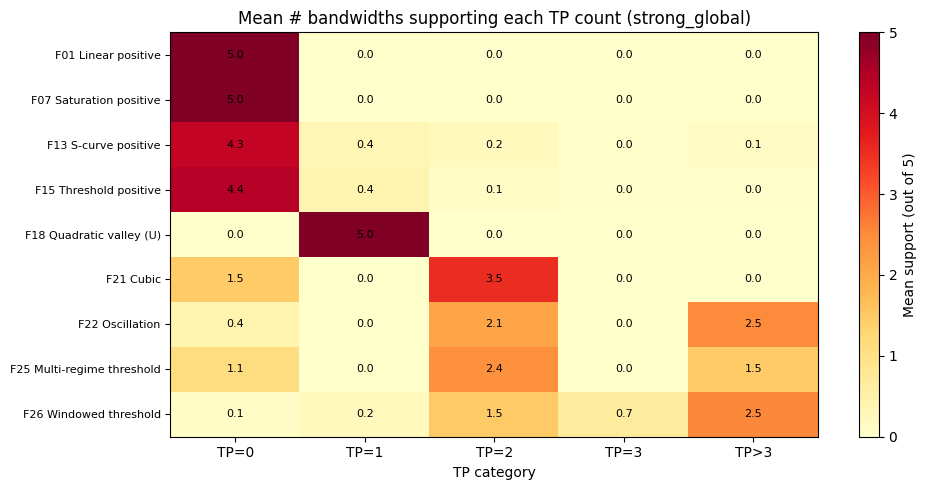


=== Uncertain cases (max support < 3/5): 99/7780 (1.3%) ===
family_id            family_name       frac_str
      F13       S-curve positive   4/482 (0.8%)
      F15     Threshold positive 72/2222 (3.2%)
      F25 Multi-regime threshold  14/32 (43.8%)
      F26     Windowed threshold   9/20 (45.0%)

TP support vectors (uncertain cases, first 20):


,case_id,family_id,TP0,TP1,TP2,TP3,TP>3,family_name
375,S032353,F13,2,2,0,0,1,S-curve positive
376,S032354,F13,2,2,0,0,1,S-curve positive
377,S032355,F13,2,2,0,0,1,S-curve positive
378,S032356,F13,2,2,0,0,1,S-curve positive
600,S036435,F15,2,2,0,0,1,Threshold positive
601,S036436,F15,2,2,0,0,1,Threshold positive
602,S036437,F15,2,2,0,0,1,Threshold positive
603,S036438,F15,2,2,0,0,1,Threshold positive
604,S036439,F15,2,2,0,0,1,Threshold positive
605,S036440,F15,2,2,0,0,1,Threshold positive


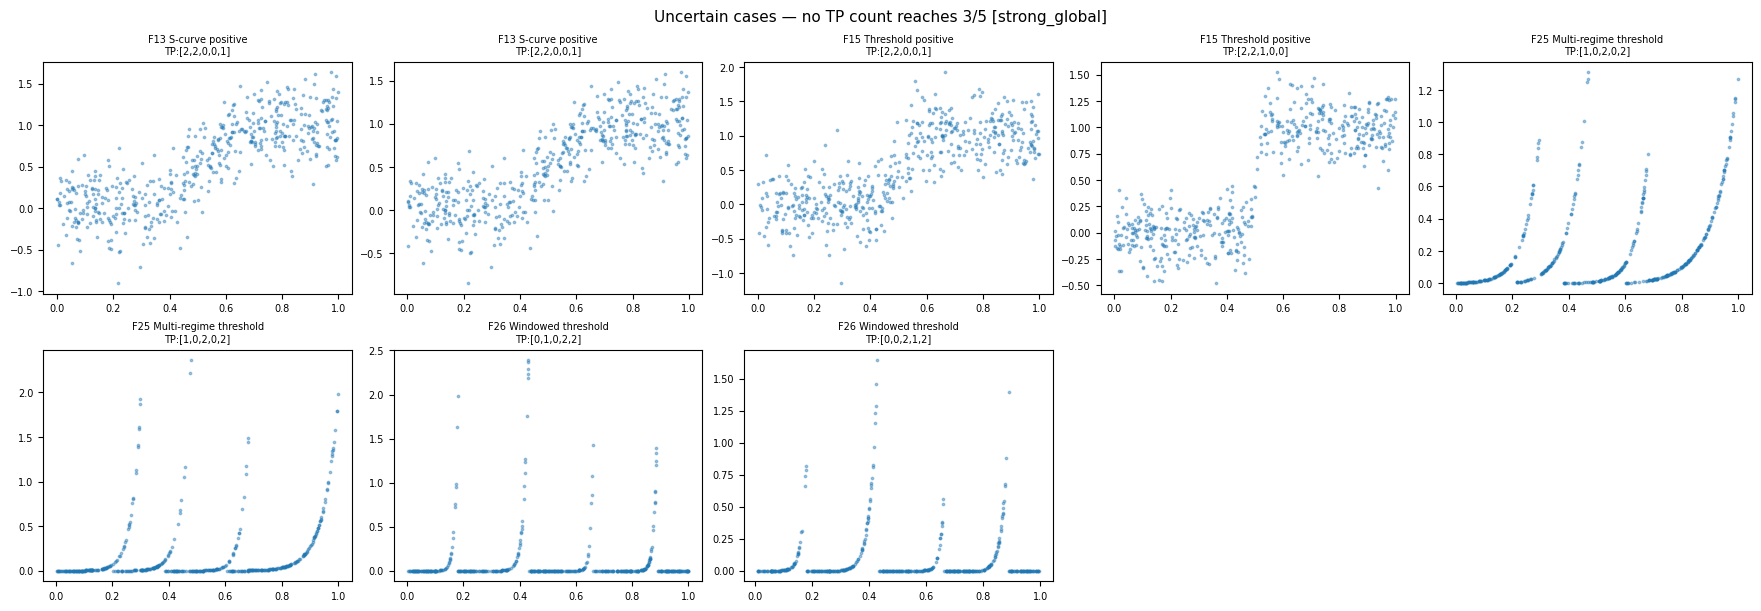


=== TP support diagnostic [intermediate_global] ===

=== Per-bandwidth mean TP count by family ===


,family_name,bw_1,bw_2,bw_3,bw_4,bw_5
family_id,,,,,,
F01,Linear positive,0.11,0.00,0.00,0.00,0.00
F03,Power convex positive,1.12,0.79,0.16,0.05,0.00
F05,Power concave positive,0.03,0.00,0.00,0.00,0.00
F07,Saturation positive,0.18,0.01,0.00,0.00,0.00
F13,S-curve positive,2.24,0.91,0.25,0.03,0.00
F15,Threshold positive,3.27,1.74,1.09,0.57,0.00
F18,Quadratic valley (U),1.04,1.00,1.00,1.00,1.00
F21,Cubic,2.00,2.00,2.00,0.98,0.00
F22,Oscillation,5.07,5.04,4.15,1.74,1.39



=== TP = 0 support distribution — Monotonic (Transition/Saturation/Acceleration…) ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,309,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),18 (5.8%),291 (94.2%)
F03,Power convex positive,184,0 (0.0%),10 (5.4%),20 (10.9%),77 (41.8%),32 (17.4%),45 (24.5%)
F05,Power concave positive,207,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),3 (1.4%),204 (98.6%)
F07,Saturation positive,700,0 (0.0%),0 (0.0%),0 (0.0%),5 (0.7%),62 (8.9%),633 (90.4%)
F13,S-curve positive,232,0 (0.0%),6 (2.6%),49 (21.1%),84 (36.2%),81 (34.9%),12 (5.2%)
F15,Threshold positive,206,0 (0.0%),93 (45.1%),66 (32.0%),24 (11.7%),23 (11.2%),0 (0.0%)
F18,Quadratic valley (U),333,333 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,702,0 (0.0%),345 (49.1%),357 (50.9%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,287,200 (69.7%),49 (17.1%),38 (13.2%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP = 1 support distribution — U-shape / Spike (F18/F19/F20) ===


...

,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,309,294 (95.1%),15 (4.9%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,184,119 (64.7%),27 (14.7%),38 (20.7%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,207,204 (98.6%),3 (1.4%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,700,666 (95.1%),31 (4.4%),3 (0.4%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,232,172 (74.1%),58 (25.0%),2 (0.9%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,206,135 (65.5%),27 (13.1%),16 (7.8%),15 (7.3%),13 (6.3%),0 (0.0%)
F18,Quadratic valley (U),333,333 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,702,0 (0.0%),0 (0.0%),0 (0.0%),357 (50.9%),345 (49.1%),0 (0.0%)
F22,Oscillation,287,38 (13.2%),49 (17.1%),71 (24.7%),129 (44.9%),0 (0.0%),0 (0.0%)



=== TP = 3 support distribution — Oscillation / Multi-regime ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,309,309 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,184,183 (99.5%),1 (0.5%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,207,207 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,700,698 (99.7%),2 (0.3%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,232,172 (74.1%),58 (25.0%),2 (0.9%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,206,98 (47.6%),87 (42.2%),9 (4.4%),12 (5.8%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),333,327 (98.2%),6 (1.8%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,702,702 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,287,274 (95.5%),13 (4.5%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP > 3 support distribution — High-frequency oscillation ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,309,309 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,184,184 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,207,207 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,700,693 (99.0%),7 (1.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,232,182 (78.4%),38 (16.4%),12 (5.2%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,206,122 (59.2%),84 (40.8%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),333,333 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,702,702 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,287,0 (0.0%),8 (2.8%),126 (43.9%),153 (53.3%),0 (0.0%),0 (0.0%)


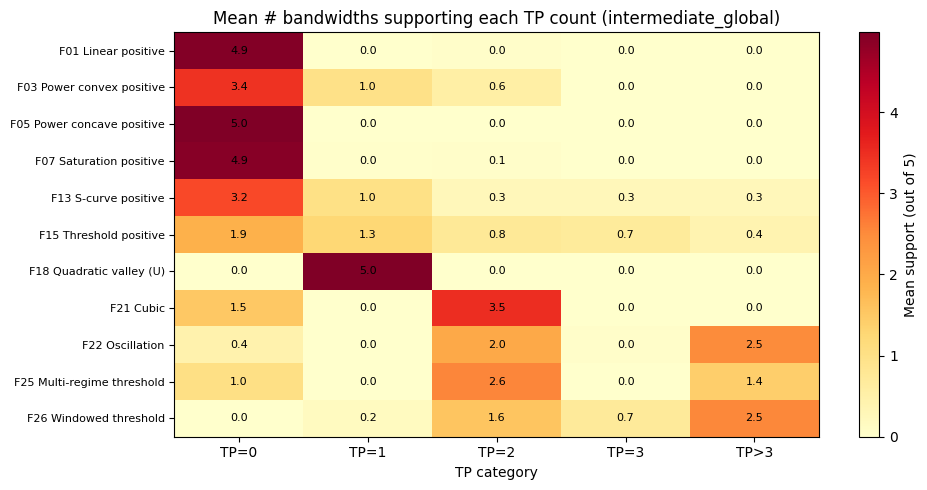


=== Uncertain cases (max support < 3/5): 359/3709 (9.7%) ===
family_id            family_name        frac_str
      F03  Power convex positive    5/184 (2.7%)
      F13       S-curve positive  44/232 (19.0%)
      F15     Threshold positive  82/206 (39.8%)
      F22            Oscillation    5/287 (1.7%)
      F25 Multi-regime threshold 202/503 (40.2%)
      F26     Windowed threshold   21/46 (45.7%)

TP support vectors (uncertain cases, first 20):


,case_id,family_id,TP0,TP1,TP2,TP3,TP>3,family_name
318,S009431,F03,2,2,0,1,0,Power convex positive
431,S011703,F03,2,2,1,0,0,Power convex positive
432,S011704,F03,2,2,1,0,0,Power convex positive
433,S011705,F03,2,2,1,0,0,Power convex positive
434,S011706,F03,2,2,1,0,0,Power convex positive
1422,S030068,F13,2,2,0,1,0,S-curve positive
1446,S030528,F13,2,2,1,0,0,S-curve positive
1447,S030529,F13,2,2,1,0,0,S-curve positive
1448,S030530,F13,2,2,1,0,0,S-curve positive
1449,S030531,F13,2,2,1,0,0,S-curve positive


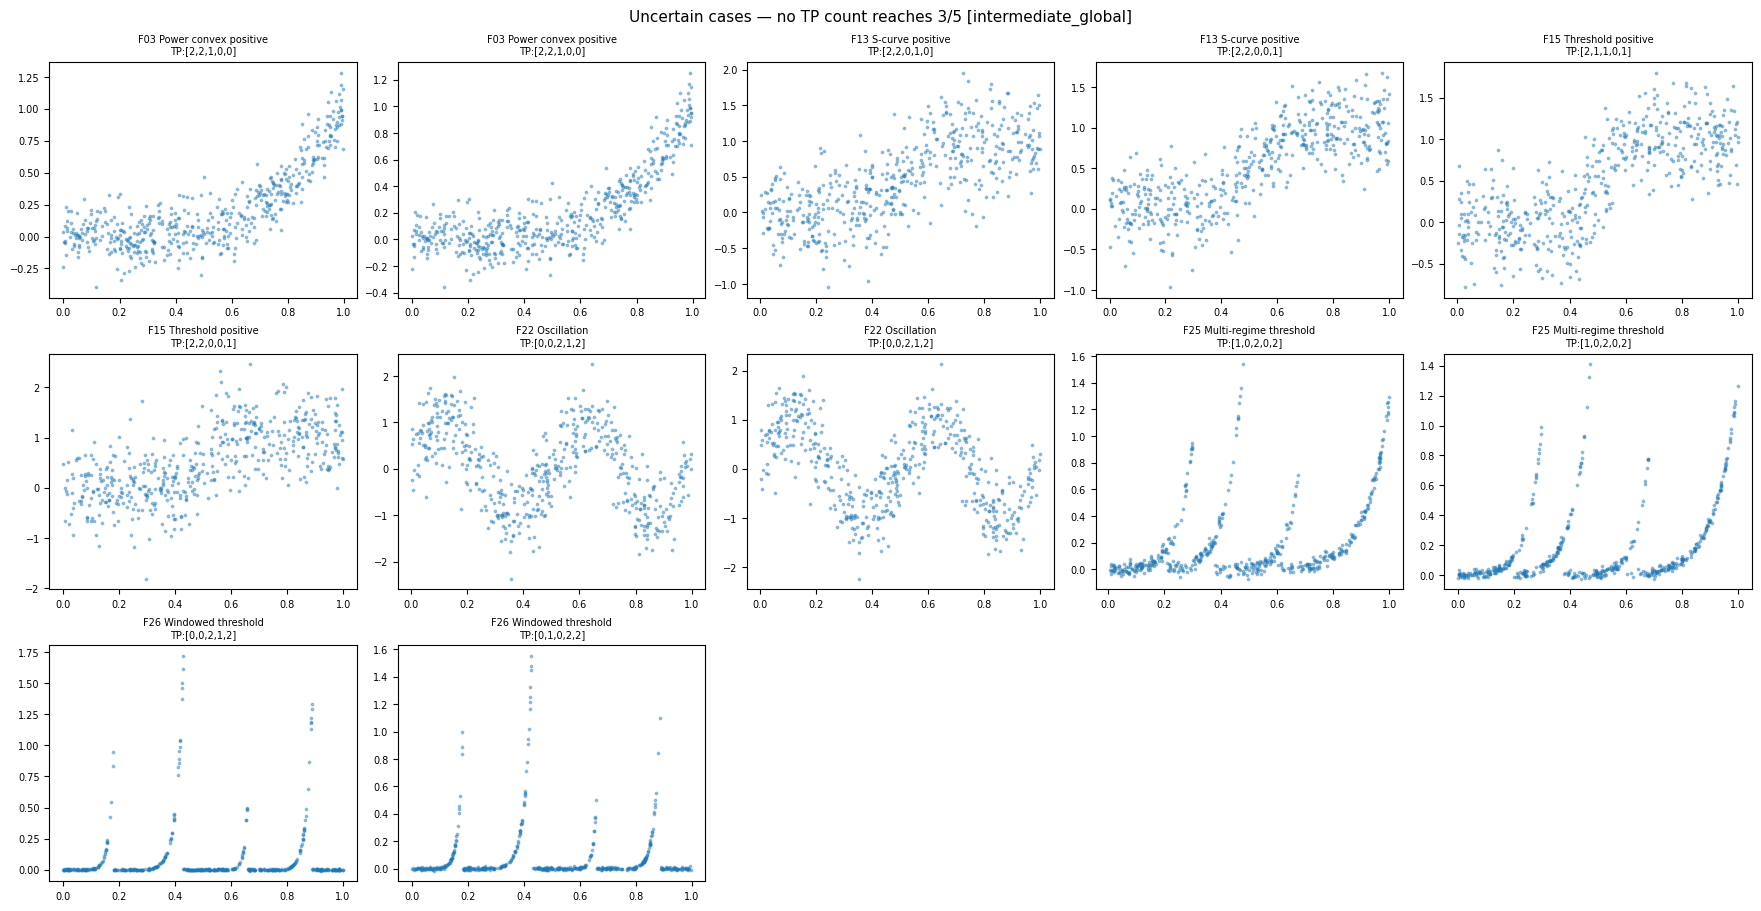

In [316]:
if RUN_METHOD_A:
    import matplotlib.pyplot as plt

    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        sizer_bw_df = sizer_bw_dfs.get(_gate)
        if sizer_df is None or len(sizer_df) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== TP support diagnostic [{_gate}] ===')
        print(f'{"="*60}')

        print('\n=== Per-bandwidth mean TP count by family ===')
        if len(sizer_bw_df) > 0:
            _bw_tp = sizer_bw_df.pivot_table(
                index='family_id', columns='bw_index', values='tp_count', aggfunc='mean'
            ).round(2)
            _bw_tp.columns = [f'bw_{int(c)}' for c in _bw_tp.columns]
            _bw_tp.insert(0, 'family_name', _bw_tp.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
            display(_bw_tp)

        TP_CATEGORIES = [
            ('n_0tp_bw', 'TP = 0', 'Monotonic (Transition/Saturation/Acceleration…)'),
            ('n_1tp_bw', 'TP = 1', 'U-shape / Spike (F18/F19/F20)'),
            ('n_2tp_bw', 'TP = 2', 'Cubic (F21)'),
            ('n_3tp_bw', 'TP = 3', 'Oscillation / Multi-regime'),
            ('n_gt3tp_bw', 'TP > 3', 'High-frequency oscillation'),
        ]

        for col, tp_label, description in TP_CATEGORIES:
            print(f'\n=== {tp_label} support distribution — {description} ===')
            _support = sizer_df.copy()
            _support[col] = _support[col].fillna(0).astype(int)
            _sup_table = _support.groupby('family_id')[col].value_counts().unstack(fill_value=0)
            _sup_table = _sup_table.reindex(columns=range(6), fill_value=0)
            _sup_totals = _sup_table.sum(axis=1)
            _sup_out = pd.DataFrame(index=_sup_table.index)
            _sup_out['family_name'] = _sup_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
            _sup_out['n'] = _sup_totals
            for c in _sup_table.columns:
                _sup_out[f'{c}/5'] = [count_percent(int(n), int(t)) for n, t in zip(_sup_table[c], _sup_totals)]
            display(_sup_out)

        fig, ax = plt.subplots(figsize=(10, 5))
        tp_cols = ['n_0tp_bw', 'n_1tp_bw', 'n_2tp_bw', 'n_3tp_bw', 'n_gt3tp_bw']
        tp_labels = ['TP=0', 'TP=1', 'TP=2', 'TP=3', 'TP>3']
        _heat = sizer_df.groupby('family_id')[tp_cols].mean()
        _heat.columns = tp_labels
        _heat = _heat.loc[sorted(_heat.index)]

        im = ax.imshow(_heat.values, aspect='auto', cmap='YlOrRd')
        ax.set_xticks(range(len(tp_labels)))
        ax.set_xticklabels(tp_labels)
        ax.set_yticks(range(len(_heat.index)))
        fnames = [f'{fid} {FAMILY_CATALOGUE.get(fid, {}).get("name", "")}' for fid in _heat.index]
        ax.set_yticklabels(fnames, fontsize=8)
        for i in range(len(_heat.index)):
            for j in range(len(tp_labels)):
                ax.text(j, i, f'{_heat.values[i, j]:.1f}', ha='center', va='center', fontsize=8)
        ax.set_title(f'Mean # bandwidths supporting each TP count ({_gate})')
        ax.set_xlabel('TP category')
        fig.colorbar(im, ax=ax, label='Mean support (out of 5)')
        plt.tight_layout()
        plt.show()

        # ── Uncertain cases: no TP count reaches 3/5 support ──
        _unc = sizer_df.copy()
        _unc['_max_support'] = _unc[['n_0tp_bw', 'n_1tp_bw', 'n_2tp_bw', 'n_3tp_bw', 'n_gt3tp_bw']].max(axis=1)
        _unc = _unc[_unc['_max_support'] < 3]
        n_unc = len(_unc)
        n_total = len(sizer_df)
        print(f'\n=== Uncertain cases (max support < 3/5): {n_unc}/{n_total} ({n_unc/n_total:.1%}) ===')

        if n_unc > 0:
            _unc_by_fam = _unc.groupby('family_id').size().reset_index(name='count')
            _unc_by_fam['family_name'] = _unc_by_fam['family_id'].map(
                lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
            _unc_by_fam['frac'] = _unc_by_fam['count'] / _unc_by_fam['family_id'].map(
                lambda f: len(sizer_df[sizer_df['family_id'] == f]))
            _unc_by_fam['frac_str'] = _unc_by_fam.apply(
                lambda r: f'{int(r["count"])}/{int(r["count"]/r["frac"])} ({r["frac"]:.1%})', axis=1)
            print(_unc_by_fam[['family_id', 'family_name', 'frac_str']].to_string(index=False))

            # TP support vector for uncertain cases
            print(f'\nTP support vectors (uncertain cases, first 20):')
            _show = _unc.head(20)[['case_id', 'family_id',
                'n_0tp_bw', 'n_1tp_bw', 'n_2tp_bw', 'n_3tp_bw', 'n_gt3tp_bw']].copy()
            _show.columns = ['case_id', 'family_id', 'TP0', 'TP1', 'TP2', 'TP3', 'TP>3']
            _show['family_name'] = _show['family_id'].map(
                lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
            display(_show)

            # Scatter plots: up to 2 samples per family
            _unc_fams = sorted(_unc['family_id'].unique())
            _samples = []
            for _ufid in _unc_fams:
                _uf_cases = _unc[_unc['family_id'] == _ufid]
                _picks = _uf_cases.sample(n=min(2, len(_uf_cases)), random_state=42)
                for _, _pick in _picks.iterrows():
                    _samples.append(_pick)

            if len(_samples) > 0:
                ncols = min(len(_samples), 5)
                nrows = math.ceil(len(_samples) / ncols)
                fig, axes = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 3*nrows), constrained_layout=True)
                axes = np.array(axes).flatten() if len(_samples) > 1 else [axes]
                for ax, _pick in zip(axes, _samples):
                    _cd = non_branch_datas[_gate]
                    _pi = int(_cd.loc[_cd['case_id'] == _pick['case_id'], '_pt_idx'].iloc[0])
                    _x = x_all[_pi].astype(np.float64)
                    _y = y_all[_pi].astype(np.float64)
                    _fname = FAMILY_CATALOGUE.get(_pick['family_id'], {}).get('name', '')
                    _tp_vec = f"[{int(_pick['n_0tp_bw'])},{int(_pick['n_1tp_bw'])},{int(_pick['n_2tp_bw'])},{int(_pick['n_3tp_bw'])},{int(_pick['n_gt3tp_bw'])}]"
                    ax.scatter(_x, _y, s=3, alpha=0.4)
                    ax.set_title(f'{_pick["family_id"]} {_fname}\nTP:{_tp_vec}', fontsize=7)
                    ax.tick_params(labelsize=7)
                for ax in axes[len(_samples):]:
                    ax.set_visible(False)
                fig.suptitle(f'Uncertain cases — no TP count reaches 3/5 [{_gate}]', fontsize=11)
                plt.show()
        else:
            print('No uncertain cases.')


=== Width Ratio Distribution [strong_global] ===
width_ratio_fine = finest bandwidth; width_ratio_mean = mean across all bandwidths



,,n,wr_fine_mean,wr_fine_std,wr_fine_min,wr_fine_max,wr_mean_mean,wr_mean_std
family_id,family_name,,,,,,,
F01,Linear positive,63,0.999,0.005,0.978,1.000,1.000,0.001
F07,Saturation positive,55,0.247,0.006,0.239,0.256,0.360,0.005
F13,S-curve positive,482,0.834,0.074,0.611,0.961,0.904,0.048
F15,Threshold positive,2222,0.351,0.142,0.200,0.839,0.606,0.068
F18,Quadratic valley (U),1848,0.950,0.019,0.861,0.983,0.957,0.007
F21,Cubic,1068,0.859,0.020,0.800,0.906,0.879,0.008
F22,Oscillation,1990,0.966,0.007,0.950,0.989,0.914,0.050
F25,Multi-regime threshold,32,0.819,0.056,0.689,0.900,0.767,0.048
F26,Windowed threshold,20,0.905,0.020,0.872,0.939,0.918,0.010


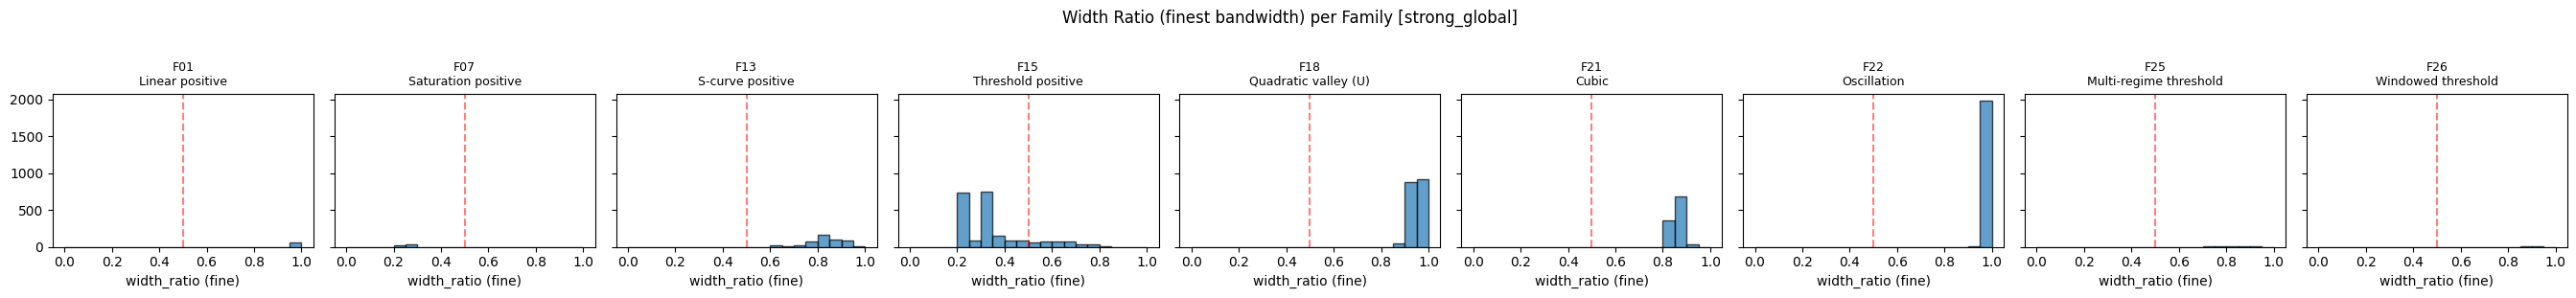


=== Width Ratio Distribution [intermediate_global] ===
width_ratio_fine = finest bandwidth; width_ratio_mean = mean across all bandwidths



,,n,wr_fine_mean,wr_fine_std,wr_fine_min,wr_fine_max,wr_mean_mean,wr_mean_std
family_id,family_name,,,,,,,
F01,Linear positive,309,0.991,0.014,0.928,1.000,0.998,0.003
F03,Power convex positive,184,0.852,0.071,0.694,0.983,0.871,0.071
F05,Power concave positive,207,0.946,0.048,0.828,1.000,0.985,0.015
F07,Saturation positive,700,0.335,0.197,0.217,0.872,0.439,0.177
F13,S-curve positive,232,0.885,0.049,0.778,0.972,0.921,0.036
F15,Threshold positive,206,0.725,0.089,0.444,0.889,0.798,0.049
F18,Quadratic valley (U),333,0.950,0.036,0.856,0.989,0.955,0.015
F21,Cubic,702,0.850,0.042,0.728,0.922,0.876,0.015
F22,Oscillation,287,0.964,0.007,0.944,0.978,0.919,0.040


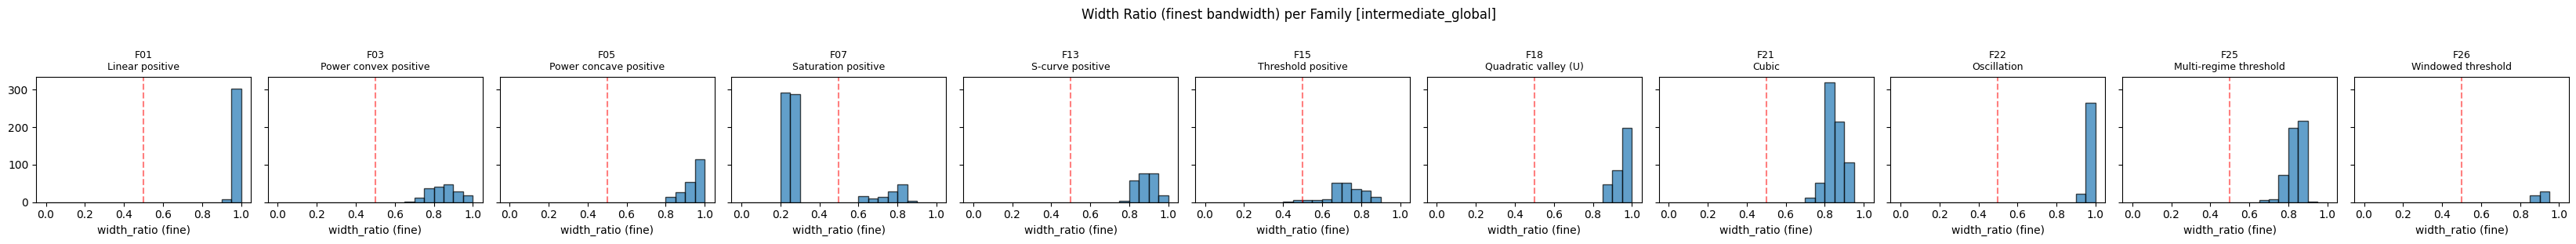

In [317]:
if RUN_METHOD_A:
    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        if sizer_df is None or len(sizer_df) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== Width Ratio Distribution [{_gate}] ===')
        print(f'{"="*60}')
        print('width_ratio_fine = finest bandwidth; width_ratio_mean = mean across all bandwidths\n')

        wr_summary = sizer_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            wr_fine_mean=('width_ratio_fine', 'mean'),
            wr_fine_std=('width_ratio_fine', 'std'),
            wr_fine_min=('width_ratio_fine', 'min'),
            wr_fine_max=('width_ratio_fine', 'max'),
            wr_mean_mean=('width_ratio_mean', 'mean'),
            wr_mean_std=('width_ratio_mean', 'std'),
        ).round(3)
        display(wr_summary)

        families = sorted(sizer_df['family_id'].unique())
        n_fam = len(families)
        fig, axes = plt.subplots(1, n_fam, figsize=(3*n_fam, 3), sharey=True)
        if n_fam == 1:
            axes = [axes]
        for ax, fid in zip(axes, families):
            subset = sizer_df[sizer_df['family_id'] == fid]
            fname = subset['family_name'].iloc[0] if len(subset) > 0 else fid
            ax.hist(subset['width_ratio_fine'].dropna(), bins=20, range=(0, 1), alpha=0.7, edgecolor='black')
            ax.set_title(f'{fid}\n{fname}', fontsize=9)
            ax.set_xlabel('width_ratio (fine)')
            ax.axvline(0.5, color='red', ls='--', alpha=0.5, label='0.5 threshold')
        fig.suptitle(f'Width Ratio (finest bandwidth) per Family [{_gate}]', y=1.02)
        plt.tight_layout()
        plt.show()

In [318]:
if RUN_METHOD_A:
    TP_SUPPORT_MIN = 3

    def tp_classify(row):
        supports = {
            0: row['n_0tp_bw'],
            1: row['n_1tp_bw'],
            2: row['n_2tp_bw'],
            'ge3': row['n_3tp_bw'] + row['n_gt3tp_bw'],
        }
        dominant = max(supports, key=supports.get)
        dominant_n = supports[dominant]
        if dominant_n < TP_SUPPORT_MIN:
            return 'Uncertain'
        if dominant == 0:
            return 'TP=0'
        elif dominant == 1:
            return 'TP=1'
        elif dominant == 2:
            return 'TP=2'
        else:
            return 'TP≥3'

    EXPECTED_TP_LABEL = {}
    for fid, props in FAMILY_CATALOGUE.items():
        tp = props.get('tp', 'N/A')
        mono = props.get('monotonicity', '')
        if tp == 0 and mono == 'monotonic':
            EXPECTED_TP_LABEL[fid] = 'TP=0'
        elif tp == 1:
            EXPECTED_TP_LABEL[fid] = 'TP=1'
        elif tp == 2:
            EXPECTED_TP_LABEL[fid] = 'TP=2'
        elif tp == 'multiple' or (isinstance(tp, int) and tp > 2):
            EXPECTED_TP_LABEL[fid] = 'TP≥3'
        else:
            EXPECTED_TP_LABEL[fid] = None

    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        if sizer_df is None or len(sizer_df) == 0:
            continue

        sizer_df['sizer_label'] = sizer_df.apply(tp_classify, axis=1)
        sizer_dfs[_gate] = sizer_df

        print(f'\n{"="*60}')
        print(f'=== Multiscale TP classification [{_gate}] (≥{TP_SUPPORT_MIN}/5 support) ===')
        print(f'{"="*60}')
        print(f'Rule: TP=0 | TP=1 | TP=2 | TP≥3 | <{TP_SUPPORT_MIN}/5→Uncertain\n')

        _sc = sizer_df.groupby(['family_id', 'sizer_label']).size().unstack(fill_value=0)
        _sc['total'] = _sc.sum(axis=1)
        _col_order = ['TP=0', 'TP=1', 'TP=2', 'TP≥3', 'Uncertain']
        _display_cols = [c for c in _col_order if c in _sc.columns]
        _sc_out = pd.DataFrame(index=_sc.index)
        _sc_out['family_name'] = _sc_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _sc_out['Expected'] = _sc_out.index.map(lambda f: EXPECTED_TP_LABEL.get(f, 'N/A'))
        _sc_out['Total'] = [count_percent(n, n) for n in _sc['total']]
        for col in _display_cols:
            _sc_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_sc[col], _sc['total'])]

        accuracy = []
        for fid in _sc_out.index:
            exp = EXPECTED_TP_LABEL.get(fid)
            total = int(_sc.loc[fid, 'total'])
            if exp is None:
                accuracy.append('N/A')
            elif exp in _sc.columns:
                n_correct = int(_sc.loc[fid, exp])
                accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
            else:
                accuracy.append(f'0/{total} (0.0%)')
        _sc_out['Accuracy'] = accuracy
        display(_sc_out)

        _all = sizer_df.copy()
        _all['_expected'] = _all['family_id'].map(EXPECTED_TP_LABEL)
        _eval = _all[_all['_expected'].notna()].copy()
        if len(_eval) > 0:
            _eval['_correct'] = _eval['sizer_label'] == _eval['_expected']
            n_t = len(_eval)
            n_c = int(_eval['_correct'].sum())
            print(f'\nOverall accuracy: {n_c}/{n_t} ({n_c/n_t:.1%})')


=== Multiscale TP classification [strong_global] (≥3/5 support) ===
Rule: TP=0 | TP=1 | TP=2 | TP≥3 | <3/5→Uncertain



,family_name,Expected,Total,TP=0,TP=1,TP=2,TP≥3,Uncertain,Accuracy
family_id,,,,,,,,,
F01,Linear positive,TP=0,63 (100.0%),63 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),63/63 (100.0%)
F07,Saturation positive,TP=0,55 (100.0%),55 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),55/55 (100.0%)
F13,S-curve positive,TP=0,482 (100.0%),478 (99.2%),0 (0.0%),0 (0.0%),0 (0.0%),4 (0.8%),478/482 (99.2%)
F15,Threshold positive,TP=0,"2,222 (100.0%)","1,987 (89.4%)",133 (6.0%),30 (1.4%),0 (0.0%),72 (3.2%),1987/2222 (89.4%)
F18,Quadratic valley (U),TP=1,"1,848 (100.0%)",0 (0.0%),"1,848 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),1848/1848 (100.0%)
F21,Cubic,TP=2,"1,068 (100.0%)",0 (0.0%),0 (0.0%),"1,068 (100.0%)",0 (0.0%),0 (0.0%),1068/1068 (100.0%)
F22,Oscillation,TP≥3,"1,990 (100.0%)",0 (0.0%),0 (0.0%),"1,003 (50.4%)",987 (49.6%),0 (0.0%),987/1990 (49.6%)
F25,Multi-regime threshold,TP≥3,32 (100.0%),1 (3.1%),0 (0.0%),17 (53.1%),0 (0.0%),14 (43.8%),0/32 (0.0%)
F26,Windowed threshold,TP≥3,20 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),20 (100.0%),0 (0.0%),20/20 (100.0%)



Overall accuracy: 6506/7780 (83.6%)

=== Multiscale TP classification [intermediate_global] (≥3/5 support) ===
Rule: TP=0 | TP=1 | TP=2 | TP≥3 | <3/5→Uncertain



,family_name,Expected,Total,TP=0,TP=1,TP=2,TP≥3,Uncertain,Accuracy
family_id,,,,,,,,,
F01,Linear positive,TP=0,309 (100.0%),309 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),309/309 (100.0%)
F03,Power convex positive,TP=0,184 (100.0%),154 (83.7%),25 (13.6%),0 (0.0%),0 (0.0%),5 (2.7%),154/184 (83.7%)
F05,Power concave positive,TP=0,207 (100.0%),207 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),207/207 (100.0%)
F07,Saturation positive,TP=0,700 (100.0%),700 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),700/700 (100.0%)
F13,S-curve positive,TP=0,232 (100.0%),177 (76.3%),11 (4.7%),0 (0.0%),0 (0.0%),44 (19.0%),177/232 (76.3%)
F15,Threshold positive,TP=0,206 (100.0%),47 (22.8%),37 (18.0%),28 (13.6%),12 (5.8%),82 (39.8%),47/206 (22.8%)
F18,Quadratic valley (U),TP=1,333 (100.0%),0 (0.0%),333 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),333/333 (100.0%)
F21,Cubic,TP=2,702 (100.0%),0 (0.0%),0 (0.0%),702 (100.0%),0 (0.0%),0 (0.0%),702/702 (100.0%)
F22,Oscillation,TP≥3,287 (100.0%),0 (0.0%),0 (0.0%),129 (44.9%),158 (55.1%),0 (0.0%),158/287 (55.1%)



Overall accuracy: 2833/3709 (76.4%)



=== Width Ratio within TP=0 [strong_global] (2584 cases) ===
Goal: separate S-curve (wide derivative) from Threshold (narrow derivative)



,,n,wr_fine_mean,wr_fine_std,wr_fine_min,wr_fine_max,wr_mean_mean
family_id,family_name,,,,,,
F01,Linear positive,63,0.999,0.005,0.978,1.000,1.000
F07,Saturation positive,55,0.247,0.006,0.239,0.256,0.360
F13,S-curve positive,478,0.834,0.074,0.611,0.961,0.904
F15,Threshold positive,1987,0.321,0.110,0.200,0.822,0.592
F25,Multi-regime threshold,1,0.767,NaN,0.767,0.767,0.660


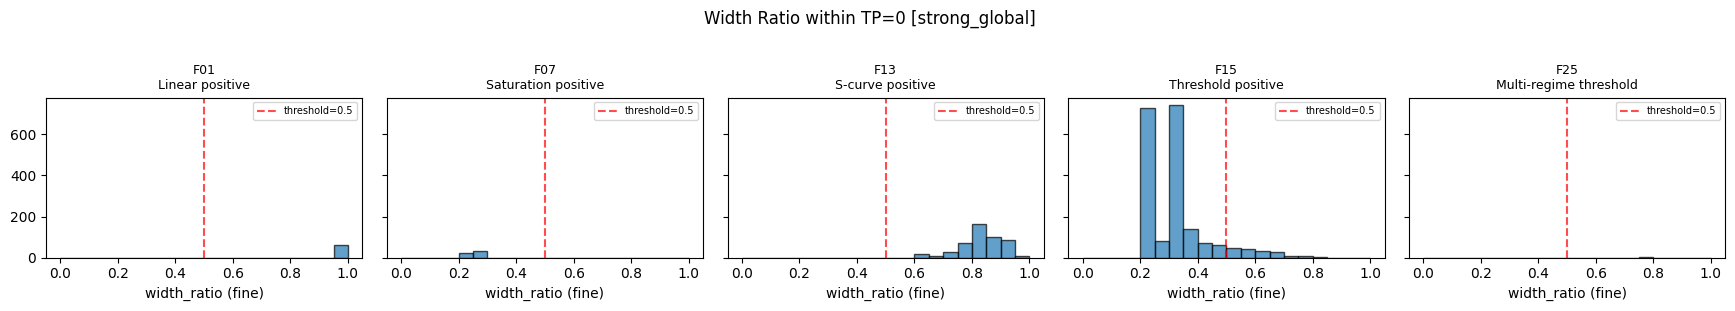


=== Width Ratio within TP=0 [intermediate_global] (1598 cases) ===
Goal: separate S-curve (wide derivative) from Threshold (narrow derivative)



,,n,wr_fine_mean,wr_fine_std,wr_fine_min,wr_fine_max,wr_mean_mean
family_id,family_name,,,,,,
F01,Linear positive,309,0.991,0.014,0.928,1.000,0.998
F03,Power convex positive,154,0.854,0.076,0.694,0.983,0.874
F05,Power concave positive,207,0.946,0.048,0.828,1.000,0.985
F07,Saturation positive,700,0.335,0.197,0.217,0.872,0.439
F13,S-curve positive,177,0.885,0.051,0.778,0.972,0.922
F15,Threshold positive,47,0.692,0.059,0.550,0.778,0.778
F25,Multi-regime threshold,4,0.767,0.000,0.767,0.767,0.660


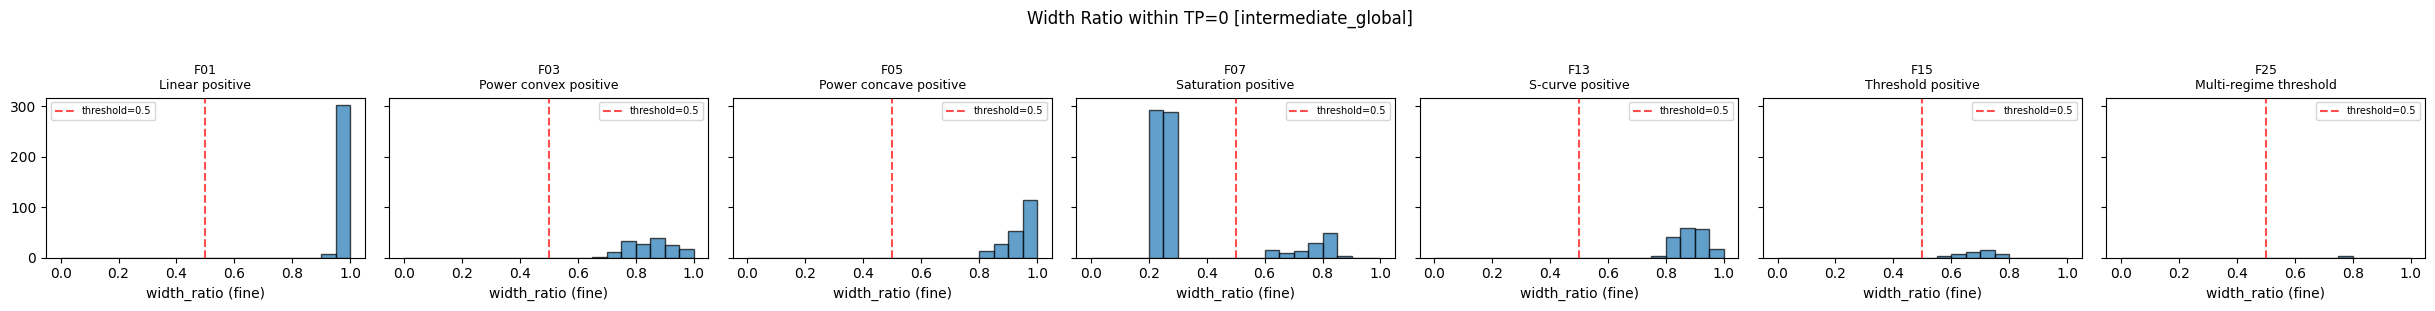

In [319]:
if RUN_METHOD_A:
    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        if sizer_df is None or len(sizer_df) == 0:
            continue

        tp0_df = sizer_df[sizer_df['sizer_label'] == 'TP=0'].copy()
        n_tp0 = len(tp0_df)
        print(f'\n{"="*60}')
        print(f'=== Width Ratio within TP=0 [{_gate}] ({n_tp0} cases) ===')
        print(f'{"="*60}')
        print('Goal: separate S-curve (wide derivative) from Threshold (narrow derivative)\n')

        if n_tp0 > 0:
            tp0_wr_summary = tp0_df.groupby(['family_id', 'family_name']).agg(
                n=('case_id', 'size'),
                wr_fine_mean=('width_ratio_fine', 'mean'),
                wr_fine_std=('width_ratio_fine', 'std'),
                wr_fine_min=('width_ratio_fine', 'min'),
                wr_fine_max=('width_ratio_fine', 'max'),
                wr_mean_mean=('width_ratio_mean', 'mean'),
            ).round(3)
            display(tp0_wr_summary)

            families_tp0 = sorted(tp0_df['family_id'].unique())
            n_fam = len(families_tp0)
            if n_fam > 0:
                fig, axes = plt.subplots(1, n_fam, figsize=(3.5*n_fam, 3), sharey=True)
                if n_fam == 1:
                    axes = [axes]
                for ax, fid in zip(axes, families_tp0):
                    subset = tp0_df[tp0_df['family_id'] == fid]
                    fname = subset['family_name'].iloc[0] if len(subset) > 0 else fid
                    ax.hist(subset['width_ratio_fine'].dropna(), bins=20, range=(0, 1),
                            alpha=0.7, edgecolor='black')
                    ax.set_title(f'{fid}\n{fname}', fontsize=9)
                    ax.set_xlabel('width_ratio (fine)')
                    ax.axvline(WIDTH_RATIO_THRESHOLD, color='red', ls='--', alpha=0.7,
                               label=f'threshold={WIDTH_RATIO_THRESHOLD}')
                    ax.legend(fontsize=7)
                fig.suptitle(f'Width Ratio within TP=0 [{_gate}]', y=1.02)
                plt.tight_layout()
                plt.show()
        else:
            print('No TP=0 cases found.')

In [320]:
if RUN_METHOD_A:
    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        if sizer_df is None or len(sizer_df) == 0:
            continue

        tp0_mask = sizer_df['sizer_label'] == 'TP=0'
        n_tp0 = tp0_mask.sum()
        tp0_families = sizer_df.loc[tp0_mask, 'family_id'].unique()

        print(f'\n{"="*60}')
        print(f'=== Width-ratio sub-classification [{_gate}] ===')
        print(f'{"="*60}')
        print(f'TP=0 cases: {n_tp0} across {len(tp0_families)} families')

        if USE_WIDTH_RATIO_SUBCLASS and n_tp0 > 0:
            narrow_mask = tp0_mask & (sizer_df['width_ratio_fine'] < WIDTH_RATIO_THRESHOLD)
            n_narrow = narrow_mask.sum()
            n_wide = n_tp0 - n_narrow
            print(f'Width-ratio sub-classification ON (threshold = {WIDTH_RATIO_THRESHOLD})')
            print(f'  wide (wr >= {WIDTH_RATIO_THRESHOLD}): {n_wide} -> keep TP=0')
            print(f'  narrow (wr < {WIDTH_RATIO_THRESHOLD}): {n_narrow} -> relabel Threshold\n')

            sizer_df.loc[narrow_mask, 'sizer_label'] = 'Threshold'
            sizer_dfs[_gate] = sizer_df

            _tp0_df = sizer_df[sizer_df['family_id'].isin(tp0_families)].copy()
            _sub = _tp0_df.groupby(['family_id', 'sizer_label']).size().unstack(fill_value=0)
            _sub['total'] = _sub.sum(axis=1)
            _col_order = ['TP=0', 'Threshold', 'TP=1', 'TP≥3', 'Uncertain']
            _sub_display = [c for c in _col_order if c in _sub.columns]

            _sub_out = pd.DataFrame(index=_sub.index)
            _sub_out['family_name'] = _sub_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
            _sub_out['Expected'] = _sub_out.index.map(lambda f: EXPECTED_TP_LABEL.get(f, 'N/A'))
            _sub_out['Total'] = [count_percent(n, n) for n in _sub['total']]
            for col in _sub_display:
                _sub_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_sub[col], _sub['total'])]

            accuracy = []
            for fid in _sub_out.index:
                exp = EXPECTED_TP_LABEL.get(fid)
                total = int(_sub.loc[fid, 'total'])
                if exp is None:
                    accuracy.append('N/A')
                elif exp in _sub.columns:
                    n_correct = int(_sub.loc[fid, exp])
                    accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
                else:
                    accuracy.append(f'0/{total} (0.0%)')
            _sub_out['Accuracy'] = accuracy

            print(f'TP=0 sub-classification (wr_fine < {WIDTH_RATIO_THRESHOLD} -> Threshold):')
            print(f'Only showing families that had TP=0 cases\n')
            display(_sub_out)
        else:
            print('Width-ratio sub-classification OFF or no TP=0 cases')


=== Width-ratio sub-classification [strong_global] ===
TP=0 cases: 2584 across 5 families
Width-ratio sub-classification OFF or no TP=0 cases

=== Width-ratio sub-classification [intermediate_global] ===
TP=0 cases: 1598 across 7 families
Width-ratio sub-classification OFF or no TP=0 cases


## Step 3 — Transition Detection (HD test, TP=0 non-branch cases)

For TP=0 non-branch cases, use Hartigan's dip test on the **marginal Y distribution** to distinguish:
- **Transition** (HD significant): Y clusters into distinct levels → S-curve / Threshold type
- **Monotonic** (HD not significant): smooth monotonic relationship → Saturation / Acceleration that R² failed in Simple path

KL and QR are computed as diagnostics but not used for classification at this stage.

In [321]:
if RUN_METHOD_B:
    from scipy.stats import gaussian_kde
    from diptest import diptest as diptest_func

    def _conditional_density_kde(x, y, n_grid_x=30, n_grid_y=50):
        gx = np.linspace(x.min(), x.max(), n_grid_x)
        gy = np.linspace(y.min(), y.max(), n_grid_y)
        GX, GY = np.meshgrid(gx, gy, indexing='ij')
        grid_pts = np.vstack([GX.ravel(), GY.ravel()])
        try:
            kde2d = gaussian_kde(np.vstack([x, y]), bw_method='silverman')
            density_2d = kde2d(grid_pts).reshape(n_grid_x, n_grid_y)
        except np.linalg.LinAlgError:
            return None
        kde_x = gaussian_kde(x, bw_method='silverman')
        p_x = kde_x(gx)
        p_x = p_x / p_x.sum()
        p_cond = np.zeros_like(density_2d)
        for ix in range(n_grid_x):
            col_sum = density_2d[ix].sum()
            if col_sum > 1e-20:
                p_cond[ix] = density_2d[ix] / col_sum
            else:
                p_cond[ix] = 1.0 / n_grid_y
        kde_y = gaussian_kde(y, bw_method='silverman')
        p_marginal_y = kde_y(gy)
        p_marginal_y = p_marginal_y / p_marginal_y.sum()
        return gx, gy, p_cond, p_marginal_y, p_x

    def _conditional_density_hist(x, y, n_grid_x=30, n_grid_y=50):
        hist2d, xedges, yedges = np.histogram2d(x, y, bins=[n_grid_x, n_grid_y])
        gx = 0.5 * (xedges[:-1] + xedges[1:])
        gy = 0.5 * (yedges[:-1] + yedges[1:])
        hist2d = hist2d + 1e-10
        p_x = hist2d.sum(axis=1)
        p_x = p_x / p_x.sum()
        p_cond = hist2d / hist2d.sum(axis=1, keepdims=True)
        p_marginal_y = hist2d.sum(axis=0)
        p_marginal_y = p_marginal_y / p_marginal_y.sum()
        return gx, gy, p_cond, p_marginal_y, p_x

    def _conditional_density(x, y, n_grid_x=30, n_grid_y=50):
        if KL_METHOD == 'kde':
            return _conditional_density_kde(x, y, n_grid_x, n_grid_y)
        else:
            return _conditional_density_hist(x, y, n_grid_x, n_grid_y)

    def _kl_from_cond(p_cond, p_marginal_y, p_x):
        kl = 0.0
        for ix in range(p_cond.shape[0]):
            pc = np.maximum(p_cond[ix], 1e-20)
            pm = np.maximum(p_marginal_y, 1e-20)
            kl += p_x[ix] * np.sum(pc * np.log(pc / pm))
        return float(kl)

    def _qr_from_cond(p_cond, gy):
        iqrs = []
        for ix in range(p_cond.shape[0]):
            cdf = np.cumsum(p_cond[ix])
            cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
            q05 = gy[np.searchsorted(cdf, 0.05)]
            q95 = gy[np.searchsorted(cdf, 0.95, side='right').clip(max=len(gy)-1)]
            iqrs.append(q95 - q05)
        iqrs = np.array(iqrs)
        q01_iqr = np.percentile(iqrs, 1)
        q99_iqr = np.percentile(iqrs, 99)
        if q01_iqr < 1e-10:
            return np.nan
        return float(q99_iqr / q01_iqr)

    def klqr_test(x, y, n_perm=99):
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        if len(x) < 20:
            return np.nan, np.nan, np.nan, np.nan
        result = _conditional_density(x, y)
        if result is None:
            return np.nan, np.nan, np.nan, np.nan
        gx, gy, p_cond, p_marginal_y, p_x = result
        kl_obs = _kl_from_cond(p_cond, p_marginal_y, p_x)
        qr_obs = _qr_from_cond(p_cond, gy)
        kl_count = 0
        qr_count = 0
        rng = np.random.RandomState(42)
        for _ in range(n_perm):
            y_perm = rng.permutation(y)
            res_perm = _conditional_density(x, y_perm)
            if res_perm is None:
                continue
            _, gy_p, pc_p, pm_p, px_p = res_perm
            kl_perm = _kl_from_cond(pc_p, pm_p, px_p)
            if kl_perm >= kl_obs:
                kl_count += 1
            qr_perm = _qr_from_cond(pc_p, gy_p)
            if not np.isnan(qr_perm) and not np.isnan(qr_obs) and qr_perm >= qr_obs:
                qr_count += 1
        kl_p = float((kl_count + 1) / (n_perm + 1))
        qr_p = float((qr_count + 1) / (n_perm + 1)) if not np.isnan(qr_obs) else np.nan
        return kl_obs, kl_p, qr_obs, qr_p

    def hd_test(y):
        valid = np.isfinite(y)
        y = y[valid]
        if len(y) < 20:
            return np.nan, np.nan
        dip, pval = diptest_func(y)
        return float(dip), float(pval)

    print(f'KL/QR/HD helpers defined.  KL_METHOD={KL_METHOD!r}, n_perm=99 (KL+QR shared)')

KL/QR/HD helpers defined.  KL_METHOD='histogram', n_perm=99 (KL+QR shared)



=== HD (Step 3) [strong_global] — 2,584 TP=0 non-branch cases (KL_METHOD='histogram') ===


KL/QR/HD [strong_global]: 100%|██████████| 2584/2584 [01:53<00:00, 22.75it/s]


KL/QR/HD: 2,584 cases in 113.6s

=== Significance rates per family [strong_global] ===


,,n,KL_sig,QR_sig,HD_sig
family_id,family_name,,,,
F01,Linear positive,63,63 (100.0%),37 (58.7%),0 (0.0%)
F07,Saturation positive,55,55 (100.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,478,478 (100.0%),411 (86.0%),419 (87.7%)
F15,Threshold positive,1987,"1,987 (100.0%)","1,916 (96.4%)","1,961 (98.7%)"
F25,Multi-regime threshold,1,1 (100.0%),0 (0.0%),0 (0.0%)


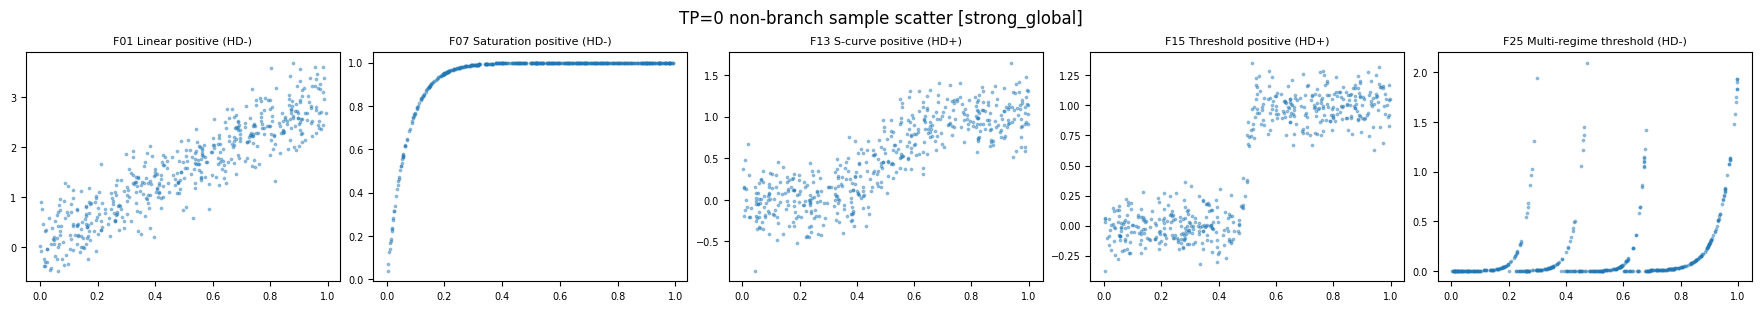


=== HD (Step 3) [intermediate_global] — 1,598 TP=0 non-branch cases (KL_METHOD='histogram') ===


KL/QR/HD [intermediate_global]: 100%|██████████| 1598/1598 [01:10<00:00, 22.69it/s]

KL/QR/HD: 1,598 cases in 70.4s

=== Significance rates per family [intermediate_global] ===


,,n,KL_sig,QR_sig,HD_sig
family_id,family_name,,,,
F01,Linear positive,309,309 (100.0%),117 (37.9%),0 (0.0%)
F03,Power convex positive,154,154 (100.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,207,207 (100.0%),2 (1.0%),0 (0.0%)
F07,Saturation positive,700,700 (100.0%),11 (1.6%),0 (0.0%)
F13,S-curve positive,177,177 (100.0%),86 (48.6%),2 (1.1%)
F15,Threshold positive,47,47 (100.0%),26 (55.3%),0 (0.0%)
F25,Multi-regime threshold,4,4 (100.0%),0 (0.0%),0 (0.0%)


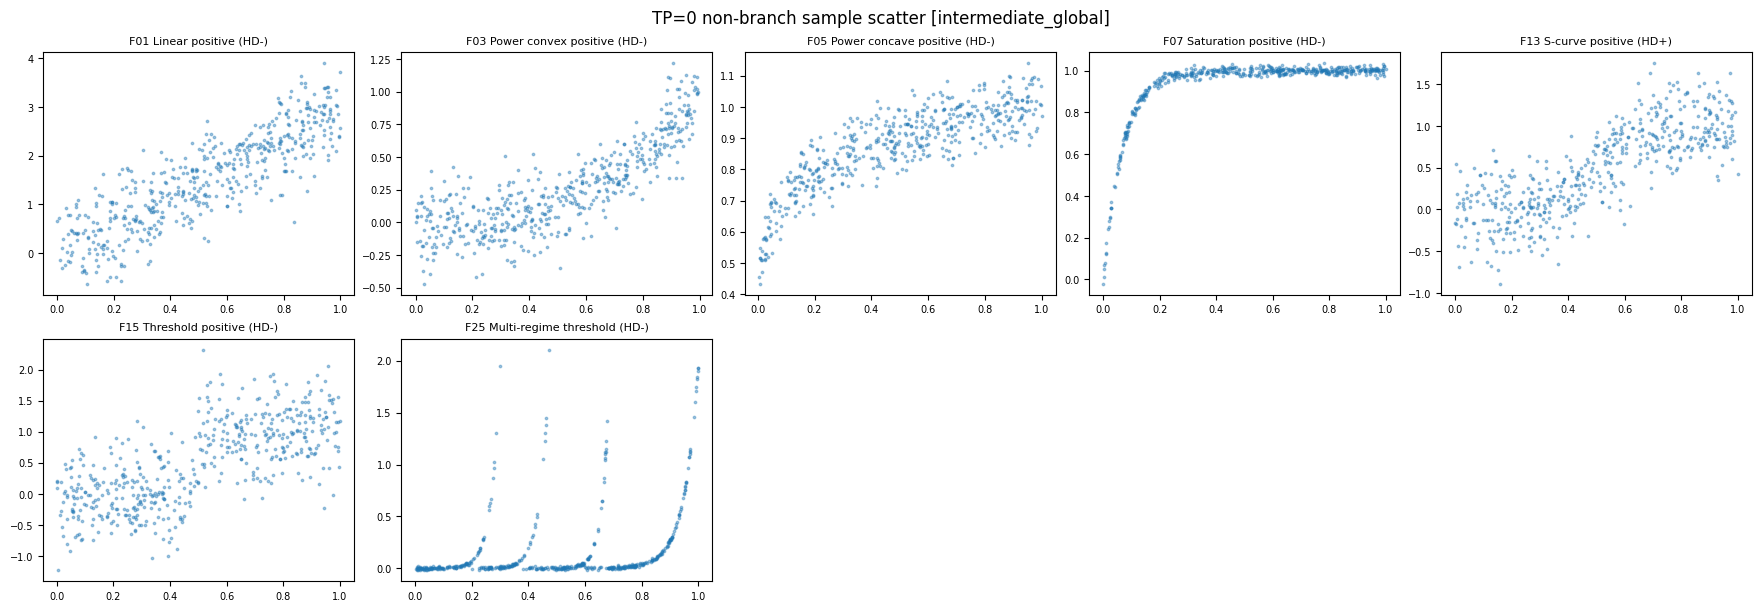

In [322]:
if RUN_METHOD_B:
    klqrhd_dfs = {}
    np.random.seed(42)

    for _gate in MIC_ANALYSIS_GATES:
        # Filter to TP=0 non-branch cases from SiZer classification
        _sdf = sizer_dfs.get(_gate)
        if _sdf is None or len(_sdf) == 0:
            print(f'[{_gate}] No SiZer results, skipping Step 3.')
            continue
        _tp0_ids = set(_sdf[_sdf['sizer_label'] == 'TP=0']['case_id'])
        _nb = non_branch_datas.get(_gate)
        if _nb is None:
            continue
        complex_data = _nb[_nb['case_id'].isin(_tp0_ids)].copy()
        if len(complex_data) == 0:
            print(f'[{_gate}] No TP=0 non-branch cases, skipping Step 3.')
            continue

        print(f'\n{"="*60}')
        print(f'=== HD (Step 3) [{_gate}] — {len(complex_data):,} TP=0 non-branch cases (KL_METHOD={KL_METHOD!r}) ===')
        print(f'{"="*60}')

        klqrhd_results = []
        t0 = time.time()

        for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc=f'KL/QR/HD [{_gate}]'):
            pi = int(row['_pt_idx'])
            x = x_all[pi].astype(np.float64)
            y = y_all[pi].astype(np.float64)

            kl_stat, kl_p, qr_stat, qr_p = klqr_test(x, y)
            hd_stat, hd_p = hd_test(y)

            klqrhd_results.append({
                'case_id': row['case_id'],
                'family_id': row['family_id'],
                'kl_stat': kl_stat, 'kl_p': kl_p, 'kl_sig': kl_p < 0.05 if not np.isnan(kl_p) else np.nan,
                'qr_stat': qr_stat, 'qr_p': qr_p, 'qr_sig': qr_p < 0.05 if not np.isnan(qr_p) else np.nan,
                'hd_stat': hd_stat, 'hd_p': hd_p, 'hd_sig': hd_p < 0.05 if not np.isnan(hd_p) else np.nan,
            })

        print(f'KL/QR/HD: {len(klqrhd_results):,} cases in {time.time()-t0:.1f}s')

        klqrhd_df = pd.DataFrame(klqrhd_results)
        klqrhd_df['family_name'] = klqrhd_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        klqrhd_dfs[_gate] = klqrhd_df

        print(f'\n=== Significance rates per family [{_gate}] ===')
        _sig = klqrhd_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            KL_sig=('kl_sig', lambda s: count_percent(int(s.sum()), len(s))),
            QR_sig=('qr_sig', lambda s: count_percent(int(s.sum()), len(s))),
            HD_sig=('hd_sig', lambda s: count_percent(int(s.sum()), len(s))),
        )
        display(_sig)

        # ── Scatter plots: 1 sample per family (prefer HD-significant) ──
        import matplotlib.pyplot as plt
        _fam_ids = sorted(klqrhd_df['family_id'].unique())
        n_fam = len(_fam_ids)
        if n_fam > 0:
            ncols = min(n_fam, 5)
            nrows = math.ceil(n_fam / ncols)
            fig, axes = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 3*nrows), constrained_layout=True)
            axes = np.array(axes).flatten() if n_fam > 1 else [axes]
            for ax, _pfid in zip(axes, _fam_ids):
                _pf_df = klqrhd_df[klqrhd_df['family_id'] == _pfid]
                _pf_sig = _pf_df[_pf_df['hd_sig'] == True]
                if len(_pf_sig) > 0:
                    _pick = _pf_sig.sample(n=1, random_state=42).iloc[0]
                    _tag = 'HD+'
                else:
                    _pick = _pf_df.sample(n=1, random_state=42).iloc[0]
                    _tag = 'HD-'
                _pi = int(complex_data.loc[complex_data['case_id'] == _pick['case_id'], '_pt_idx'].iloc[0])
                _x = x_all[_pi].astype(np.float64)
                _y = y_all[_pi].astype(np.float64)
                _fname = FAMILY_CATALOGUE.get(_pfid, {}).get('name', '')
                ax.scatter(_x, _y, s=3, alpha=0.4)
                ax.set_title(f'{_pfid} {_fname} ({_tag})', fontsize=8)
                ax.tick_params(labelsize=7)
            for ax in axes[n_fam:]:
                ax.set_visible(False)
            fig.suptitle(f'TP=0 non-branch sample scatter [{_gate}]', fontsize=12)
            plt.show()


=== KL/QR/HD stat distributions [strong_global] ===


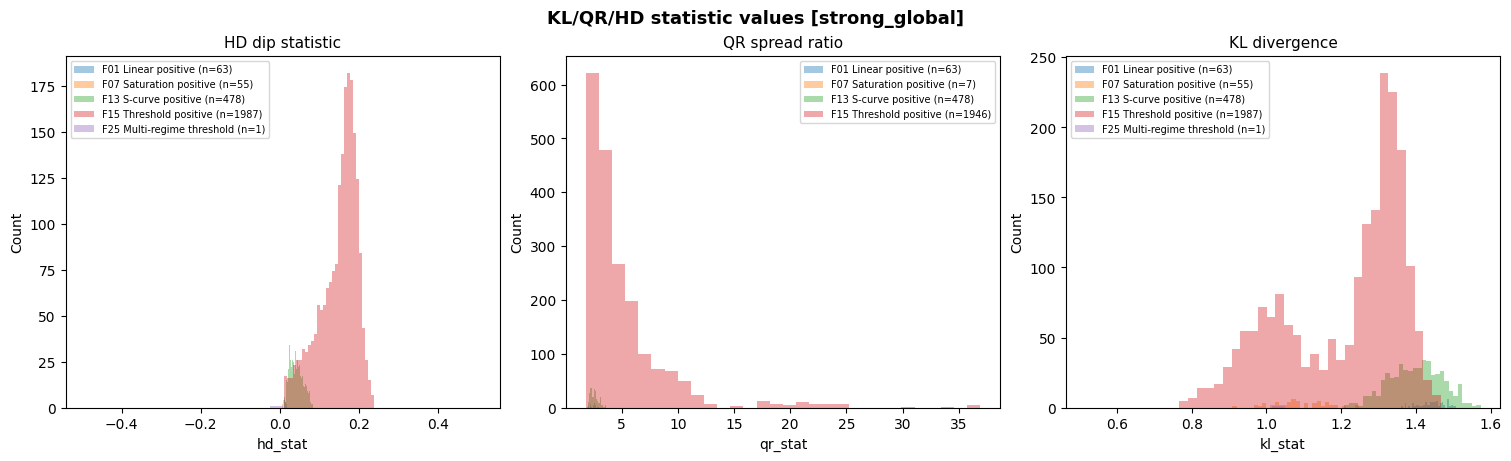


=== HD dip statistic per family [strong_global] ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,63.0,0.0139,0.0020,0.0090,0.0114,0.0123,0.0136,0.0153,0.0167,0.0179
F07,Saturation positive,55.0,0.0102,0.0019,0.0062,0.0076,0.0091,0.0103,0.0115,0.0126,0.0143
F13,S-curve positive,478.0,0.0424,0.0165,0.0116,0.0223,0.0287,0.0406,0.0542,0.0664,0.0844
F15,Threshold positive,1987.0,0.1495,0.0477,0.0117,0.0748,0.1221,0.1626,0.1838,0.1995,0.2390
F25,Multi-regime threshold,1.0,0.0079,NaN,0.0079,0.0079,0.0079,0.0079,0.0079,0.0079,0.0079



=== QR spread ratio per family [strong_global] ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,63.0,2.5826,0.3923,1.7958,2.2126,2.3155,2.5332,2.6726,3.0879,3.5714
F07,Saturation positive,7.0,16.1914,0.4721,15.6800,15.6800,15.8250,15.9700,16.6800,16.6800,16.6800
F13,S-curve positive,478.0,2.5372,0.3488,1.9091,2.1419,2.2529,2.5018,2.7385,3.1033,3.5369
F15,Threshold positive,1946.0,4.9980,3.9676,1.7850,2.3118,2.7807,3.6812,5.8500,8.9651,36.9310
F25,Multi-regime threshold,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== KL/QR/HD stat distributions [intermediate_global] ===


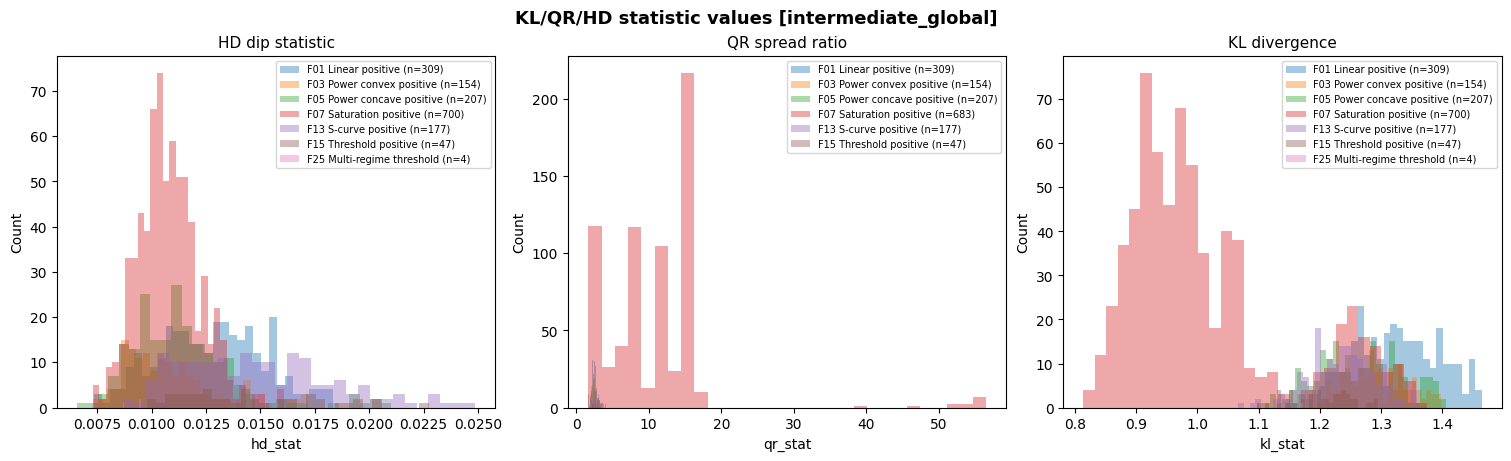


=== HD dip statistic per family [intermediate_global] ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,309.0,0.0128,0.0024,0.0073,0.0095,0.0110,0.0129,0.0145,0.0157,0.0183
F03,Power convex positive,154.0,0.0109,0.0022,0.0073,0.0087,0.0092,0.0104,0.0119,0.0144,0.0172
F05,Power concave positive,207.0,0.0114,0.0025,0.0066,0.0088,0.0099,0.0111,0.0125,0.0138,0.0210
F07,Saturation positive,700.0,0.0108,0.0014,0.0073,0.0090,0.0098,0.0106,0.0116,0.0127,0.0161
F13,S-curve positive,177.0,0.0149,0.0034,0.0087,0.0107,0.0122,0.0146,0.0170,0.0195,0.0249
F15,Threshold positive,47.0,0.0145,0.0032,0.0098,0.0109,0.0119,0.0140,0.0169,0.0193,0.0227
F25,Multi-regime threshold,4.0,0.0087,0.0010,0.0073,0.0077,0.0084,0.0091,0.0095,0.0095,0.0095



=== QR spread ratio per family [intermediate_global] ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,309.0,2.5370,0.4168,1.6000,2.1243,2.2631,2.5246,2.7217,3.1137,3.8926
F03,Power convex positive,154.0,2.4427,0.3579,1.8629,2.0000,2.1550,2.4435,2.6416,3.0254,3.4054
F05,Power concave positive,207.0,2.6089,0.4022,1.9678,2.1462,2.3507,2.5163,2.8749,3.1301,4.1229
F07,Saturation positive,683.0,10.9889,7.6400,1.6911,2.5483,6.6070,11.8295,15.2600,15.6800,56.5172
F13,S-curve positive,177.0,2.5350,0.3328,1.9594,2.1183,2.2828,2.5267,2.7299,3.0291,3.4289
F15,Threshold positive,47.0,2.5217,0.3803,1.7617,1.8473,2.3369,2.5133,2.8476,2.9318,3.0974
F25,Multi-regime threshold,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [323]:
if RUN_METHOD_B:
    import matplotlib.pyplot as plt

    for _gate in MIC_ANALYSIS_GATES:
        klqrhd_df = klqrhd_dfs.get(_gate)
        if klqrhd_df is None or len(klqrhd_df) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== KL/QR/HD stat distributions [{_gate}] ===')
        print(f'{"="*60}')

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
        stat_cols = [
            ('hd_stat', 'HD dip statistic'),
            ('qr_stat', 'QR spread ratio'),
            ('kl_stat', 'KL divergence'),
        ]
        for ax, (col, title) in zip(axes, stat_cols):
            for fid in sorted(klqrhd_df['family_id'].unique()):
                vals = klqrhd_df.loc[klqrhd_df['family_id'] == fid, col].dropna()
                if len(vals) == 0:
                    continue
                fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
                ax.hist(vals, bins=30, alpha=0.4, label=f'{fid} {fname} (n={len(vals)})')
            ax.set_title(title, fontsize=11)
            ax.set_xlabel(col)
            ax.set_ylabel('Count')
            ax.legend(fontsize=7)
        fig.suptitle(f'KL/QR/HD statistic values [{_gate}]', fontsize=13, fontweight='bold')
        plt.show()

        print(f'\n=== HD dip statistic per family [{_gate}] ===')
        _hd_summary = klqrhd_df.groupby('family_id')['hd_stat'].describe(percentiles=[.1,.25,.5,.75,.9]).round(4)
        _hd_summary.insert(0, 'family_name', _hd_summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
        display(_hd_summary)

        print(f'\n=== QR spread ratio per family [{_gate}] ===')
        _qr_summary = klqrhd_df.groupby('family_id')['qr_stat'].describe(percentiles=[.1,.25,.5,.75,.9]).round(4)
        _qr_summary.insert(0, 'family_name', _qr_summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
        display(_qr_summary)

In [324]:
if RUN_METHOD_B:

    def klqrhd_classify(row):
        if np.isnan(row.get('hd_sig', np.nan)):
            return 'failed'
        if row['hd_sig']:
            return 'Transition'
        return 'Monotonic'

    EXPECTED_KLQRHD = {}
    for fid, props in FAMILY_CATALOGUE.items():
        shape = props.get('special_shape', '')
        mono = props.get('monotonicity', '')
        lin = props.get('linearity', '')
        if shape in ('S-curve', 'threshold'):
            EXPECTED_KLQRHD[fid] = 'Transition'
        elif mono == 'monotonic' and lin != 'linear':
            EXPECTED_KLQRHD[fid] = 'Monotonic'
        else:
            EXPECTED_KLQRHD[fid] = None

    for _gate in MIC_ANALYSIS_GATES:
        klqrhd_df = klqrhd_dfs.get(_gate)
        if klqrhd_df is None or len(klqrhd_df) == 0:
            continue

        klqrhd_df['klqrhd_label'] = klqrhd_df.apply(klqrhd_classify, axis=1)
        klqrhd_dfs[_gate] = klqrhd_df

        print(f'\n{"="*60}')
        print(f'=== Step 3: HD classification [{_gate}] ===')
        print(f'{"="*60}')
        print(f'Rule: HD significant \u2192 Transition | HD not significant \u2192 Monotonic\n')

        _kc = klqrhd_df.groupby(['family_id', 'klqrhd_label']).size().unstack(fill_value=0)
        _kc['total'] = _kc.sum(axis=1)
        _kc_out = pd.DataFrame(index=_kc.index)
        _kc_out['family_name'] = _kc_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _kc_out['Total'] = [count_percent(n, n) for n in _kc['total']]
        for col in sorted(_kc.columns.drop('total')):
            _kc_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_kc[col], _kc['total'])]
        _kc_out['Expected'] = _kc_out.index.map(lambda f: EXPECTED_KLQRHD.get(f, 'N/A'))

        accuracy = []
        for fid in _kc_out.index:
            exp = EXPECTED_KLQRHD.get(fid)
            total = int(_kc.loc[fid, 'total'])
            if exp is None or exp not in _kc.columns:
                accuracy.append('N/A')
            else:
                n_correct = int(_kc.loc[fid, exp])
                accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
        _kc_out['Accuracy'] = accuracy
        display(_kc_out)

        _eval = klqrhd_df[klqrhd_df['family_id'].map(lambda f: EXPECTED_KLQRHD.get(f) is not None)].copy()
        if len(_eval) > 0:
            _eval['_expected'] = _eval['family_id'].map(EXPECTED_KLQRHD)
            _eval['_correct'] = _eval['klqrhd_label'] == _eval['_expected']
            n_t = len(_eval)
            n_c = int(_eval['_correct'].sum())
            print(f'\nOverall accuracy (TP=0 with expected): {n_c}/{n_t} ({n_c/n_t:.1%})')


=== Step 3: HD classification [strong_global] ===
Rule: HD significant → Transition | HD not significant → Monotonic



,family_name,Total,Monotonic,Transition,Expected,Accuracy
family_id,,,,,,
F01,Linear positive,63 (100.0%),63 (100.0%),0 (0.0%),None,N/A
F07,Saturation positive,55 (100.0%),55 (100.0%),0 (0.0%),Monotonic,55/55 (100.0%)
F13,S-curve positive,478 (100.0%),59 (12.3%),419 (87.7%),Transition,419/478 (87.7%)
F15,Threshold positive,"1,987 (100.0%)",26 (1.3%),"1,961 (98.7%)",Transition,1961/1987 (98.7%)
F25,Multi-regime threshold,1 (100.0%),1 (100.0%),0 (0.0%),None,N/A



Overall accuracy (TP=0 with expected): 2435/2520 (96.6%)

=== Step 3: HD classification [intermediate_global] ===
Rule: HD significant → Transition | HD not significant → Monotonic



,family_name,Total,Monotonic,Transition,Expected,Accuracy
family_id,,,,,,
F01,Linear positive,309 (100.0%),309 (100.0%),0 (0.0%),None,N/A
F03,Power convex positive,154 (100.0%),154 (100.0%),0 (0.0%),Monotonic,154/154 (100.0%)
F05,Power concave positive,207 (100.0%),207 (100.0%),0 (0.0%),Monotonic,207/207 (100.0%)
F07,Saturation positive,700 (100.0%),700 (100.0%),0 (0.0%),Monotonic,700/700 (100.0%)
F13,S-curve positive,177 (100.0%),175 (98.9%),2 (1.1%),Transition,2/177 (1.1%)
F15,Threshold positive,47 (100.0%),47 (100.0%),0 (0.0%),Transition,0/47 (0.0%)
F25,Multi-regime threshold,4 (100.0%),4 (100.0%),0 (0.0%),None,N/A



Overall accuracy (TP=0 with expected): 1063/1285 (82.7%)


## Method D — Periodicity Detection (Lomb-Scargle / Autocorrelation / Spectral Entropy)

Three independent methods to detect periodic/oscillatory structure in Y(X), compared side-by-side.
Runs on **all non-branch** complex cases. Results can be combined with SiZer TP count to sub-classify TP≥3.

In [325]:
RUN_METHOD_D = True

if RUN_METHOD_D:
    from scipy.signal import lombscargle
    from scipy.stats import pearsonr

    def _smooth_lowess(x, y, frac=0.15):
        """Simple moving-average smoother (sorted by x)."""
        order = np.argsort(x)
        xs, ys = x[order], y[order]
        n = len(xs)
        hw = max(int(n * frac / 2), 3)
        smoothed = np.full(n, np.nan)
        for i in range(n):
            lo, hi = max(0, i - hw), min(n, i + hw + 1)
            smoothed[i] = np.mean(ys[lo:hi])
        return xs, smoothed

    # ── Method D1: Lomb-Scargle ──
    def lombscargle_test(x, y, n_freq=500, smooth_frac=0.15):
        """Lomb-Scargle periodogram on smoothed Y(X).
        Returns: (max_power, p_value, dominant_period)
        p-value approximation: Baluev (2008) false-alarm probability.
        """
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        n = len(x)
        if n < 30:
            return np.nan, np.nan, np.nan

        xs, ys = _smooth_lowess(x, y, frac=smooth_frac)
        ys = ys - ys.mean()
        x_range = xs[-1] - xs[0]
        if x_range < 1e-10:
            return np.nan, np.nan, np.nan

        f_min = 1.0 / x_range
        f_max = n / (2.0 * x_range)
        freqs = np.linspace(f_min, f_max, n_freq)
        angular_freqs = 2 * np.pi * freqs

        power = lombscargle(xs, ys, angular_freqs, normalize=True)
        max_idx = np.argmax(power)
        max_power = power[max_idx]
        dominant_freq = freqs[max_idx]
        dominant_period = 1.0 / dominant_freq if dominant_freq > 0 else np.nan

        # Baluev false-alarm probability approximation
        M = len(freqs)
        z = max_power
        p_single = np.exp(-z)
        p_value = 1.0 - (1.0 - p_single) ** M
        p_value = min(max(p_value, 0.0), 1.0)

        return float(max_power), float(p_value), float(dominant_period / x_range)

    # ── Method D2: Autocorrelation ──
    def autocorr_test(x, y, smooth_frac=0.15, n_grid=200):
        """Autocorrelation of smoothed Y on uniform grid.
        Returns: (has_secondary_peak, peak_lag_frac, peak_acf_value)
        """
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        n = len(x)
        if n < 30:
            return False, np.nan, np.nan

        xs, ys = _smooth_lowess(x, y, frac=smooth_frac)
        x_grid = np.linspace(xs[0], xs[-1], n_grid)
        y_grid = np.interp(x_grid, xs, ys)
        y_grid = y_grid - y_grid.mean()

        # Full autocorrelation
        acf = np.correlate(y_grid, y_grid, mode='full')
        acf = acf[len(y_grid)-1:]  # positive lags only
        acf = acf / acf[0] if acf[0] > 0 else acf

        # Find secondary peak (skip lag 0 and initial decay)
        min_lag = n_grid // 8
        max_lag = n_grid // 2
        if max_lag <= min_lag:
            return False, np.nan, np.nan

        acf_search = acf[min_lag:max_lag]
        if len(acf_search) == 0:
            return False, np.nan, np.nan

        peak_idx = np.argmax(acf_search)
        peak_val = acf_search[peak_idx]
        peak_lag = (min_lag + peak_idx) / n_grid

        has_peak = peak_val > 0.3

        return bool(has_peak), float(peak_lag), float(peak_val)

    # ── Method D3: Spectral Entropy ──
    def spectral_entropy_test(x, y, smooth_frac=0.15, n_grid=256):
        """Spectral entropy of smoothed Y.
        Low entropy = energy concentrated (periodic), high entropy = spread (non-periodic).
        Returns: (entropy, normalized_entropy)
        """
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        n = len(x)
        if n < 30:
            return np.nan, np.nan

        xs, ys = _smooth_lowess(x, y, frac=smooth_frac)
        x_grid = np.linspace(xs[0], xs[-1], n_grid)
        y_grid = np.interp(x_grid, xs, ys)
        y_grid = y_grid - y_grid.mean()

        # FFT power spectrum
        fft_vals = np.fft.rfft(y_grid)
        psd = np.abs(fft_vals[1:]) ** 2  # skip DC
        psd_norm = psd / psd.sum() if psd.sum() > 0 else psd

        # Shannon entropy
        psd_safe = psd_norm[psd_norm > 0]
        entropy = -np.sum(psd_safe * np.log2(psd_safe))
        max_entropy = np.log2(len(psd_norm)) if len(psd_norm) > 0 else 1.0
        norm_entropy = entropy / max_entropy if max_entropy > 0 else np.nan

        return float(entropy), float(norm_entropy)

    print('Method D helpers defined (Lomb-Scargle, Autocorrelation, Spectral Entropy)')


Method D helpers defined (Lomb-Scargle, Autocorrelation, Spectral Entropy)



=== Periodicity Detection [strong_global] — 8,090 complex cases ===


Periodicity [strong_global]: 100%|██████████| 8090/8090 [01:02<00:00, 129.01it/s]

Periodicity: 8,090 cases in 62.7s

=== Periodicity detection rates [strong_global] ===


,,n,LS_sig,AC_peak,SE_mean,SE_std
family_id,family_name,,,,,
F01,Linear positive,63,0 (0.0%),63 (100.0%),0.316,0.010
F07,Saturation positive,55,0 (0.0%),0 (0.0%),0.453,0.012
F13,S-curve positive,482,0 (0.0%),482 (100.0%),0.181,0.014
F15,Threshold positive,2222,0 (0.0%),"2,222 (100.0%)",0.140,0.007
F18,Quadratic valley (U),1848,0 (0.0%),"1,848 (100.0%)",0.046,0.004
F21,Cubic,1068,0 (0.0%),0 (0.0%),0.499,0.009
F22,Oscillation,1990,0 (0.0%),"1,990 (100.0%)",0.119,0.073
F23,Two Lines,310,0 (0.0%),310 (100.0%),0.320,0.032
F25,Multi-regime threshold,32,0 (0.0%),0 (0.0%),0.482,0.017


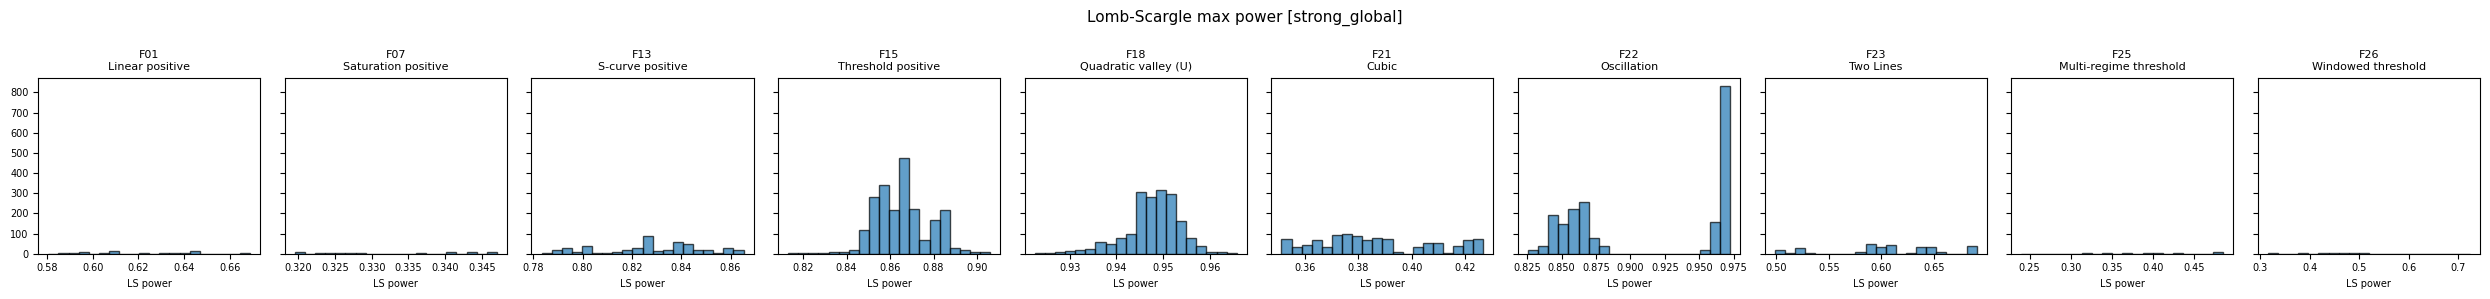

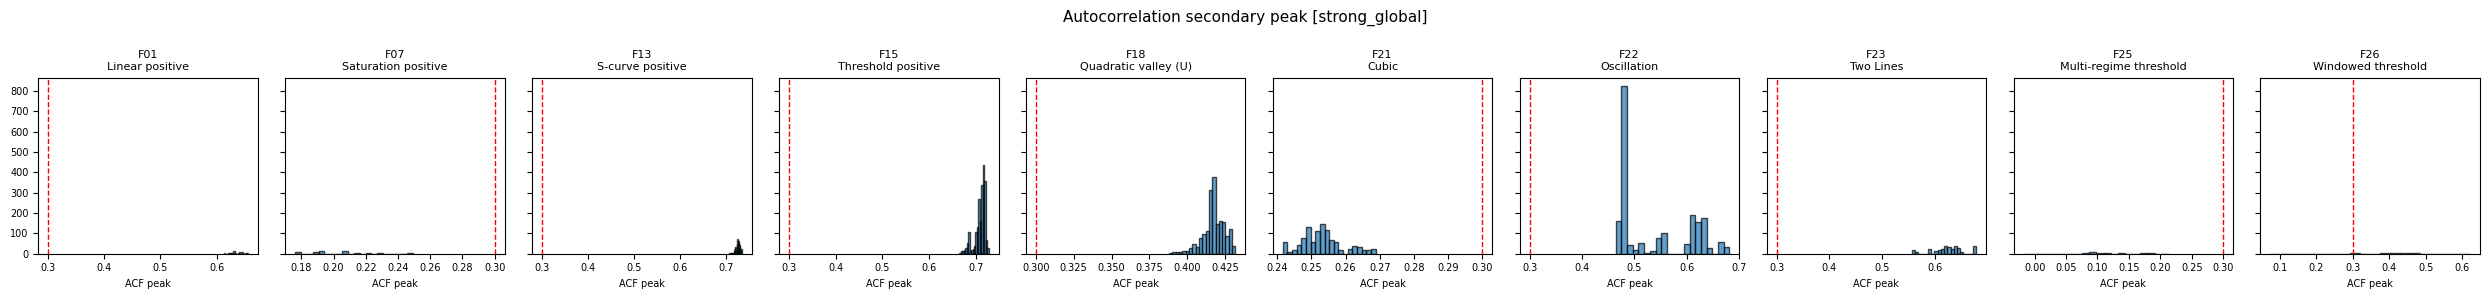

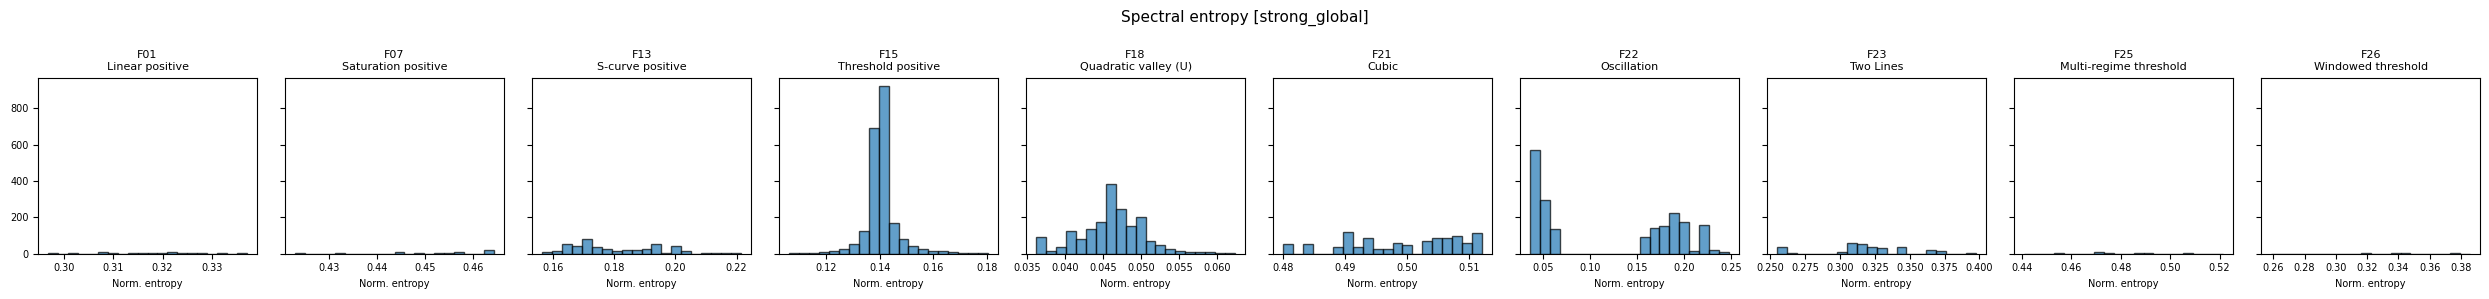

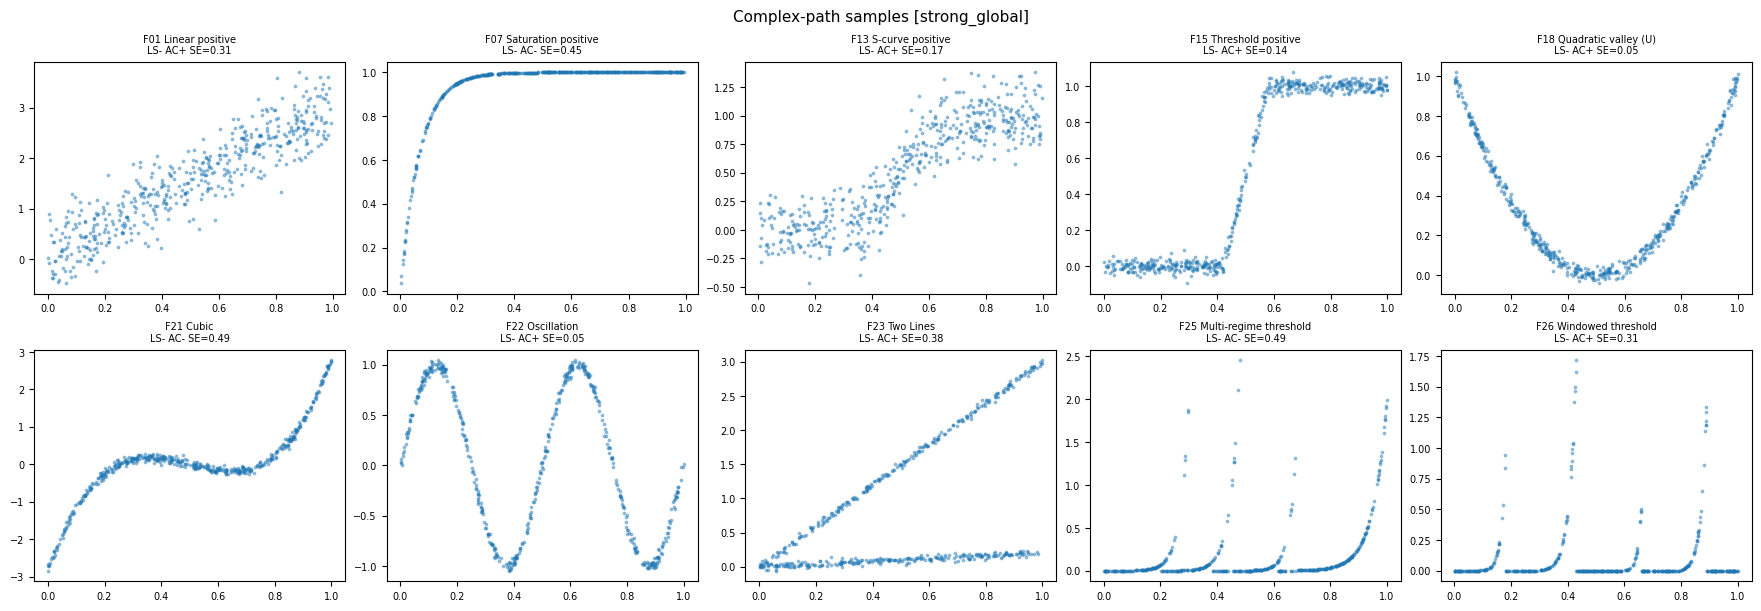


=== Periodicity Detection [intermediate_global] — 5,000 complex cases ===


Periodicity [intermediate_global]: 100%|██████████| 5000/5000 [00:38<00:00, 128.43it/s]

Periodicity: 5,000 cases in 38.9s

=== Periodicity detection rates [intermediate_global] ===


,,n,LS_sig,AC_peak,SE_mean,SE_std
family_id,family_name,,,,,
F01,Linear positive,309,0 (0.0%),309 (100.0%),0.317,0.015
F03,Power convex positive,184,0 (0.0%),184 (100.0%),0.326,0.013
F05,Power concave positive,207,0 (0.0%),207 (100.0%),0.363,0.019
F07,Saturation positive,700,0 (0.0%),118 (16.9%),0.435,0.038
F13,S-curve positive,232,0 (0.0%),232 (100.0%),0.184,0.018
F15,Threshold positive,206,0 (0.0%),206 (100.0%),0.143,0.020
F18,Quadratic valley (U),333,0 (0.0%),333 (100.0%),0.048,0.010
F21,Cubic,702,0 (0.0%),0 (0.0%),0.500,0.009
F22,Oscillation,287,0 (0.0%),287 (100.0%),0.131,0.076


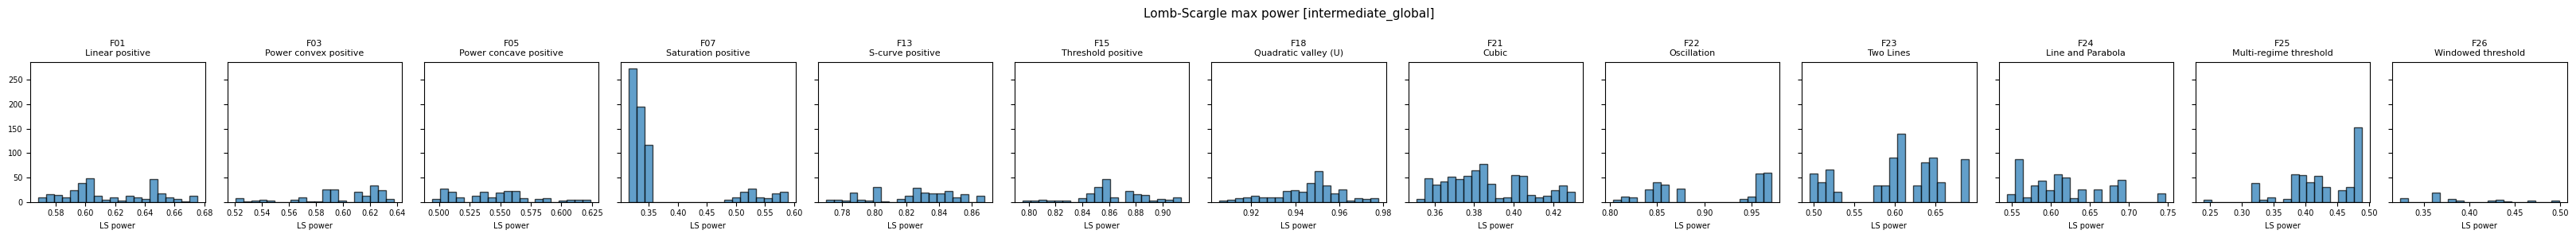

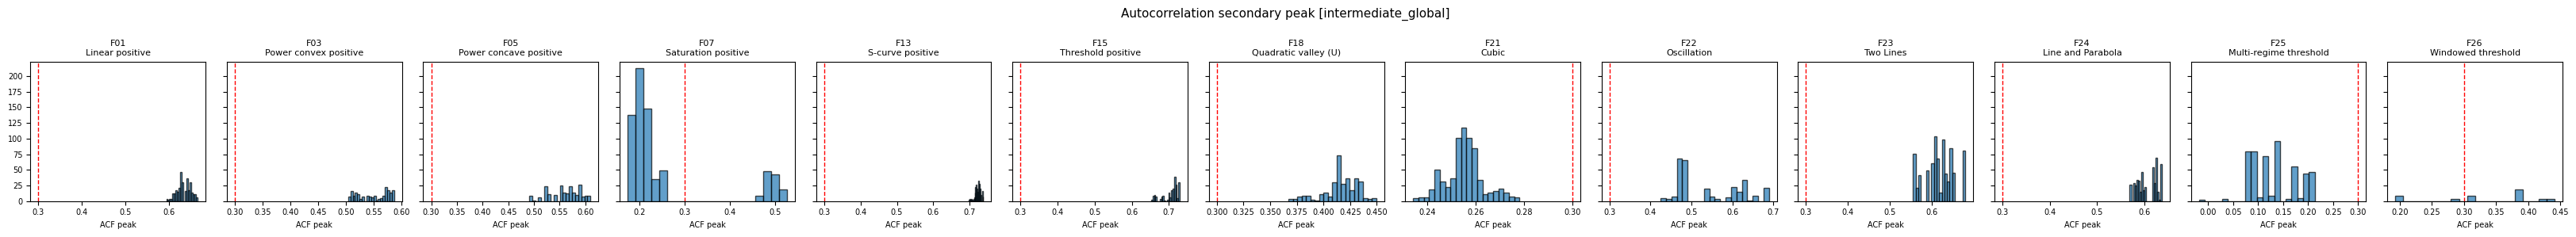

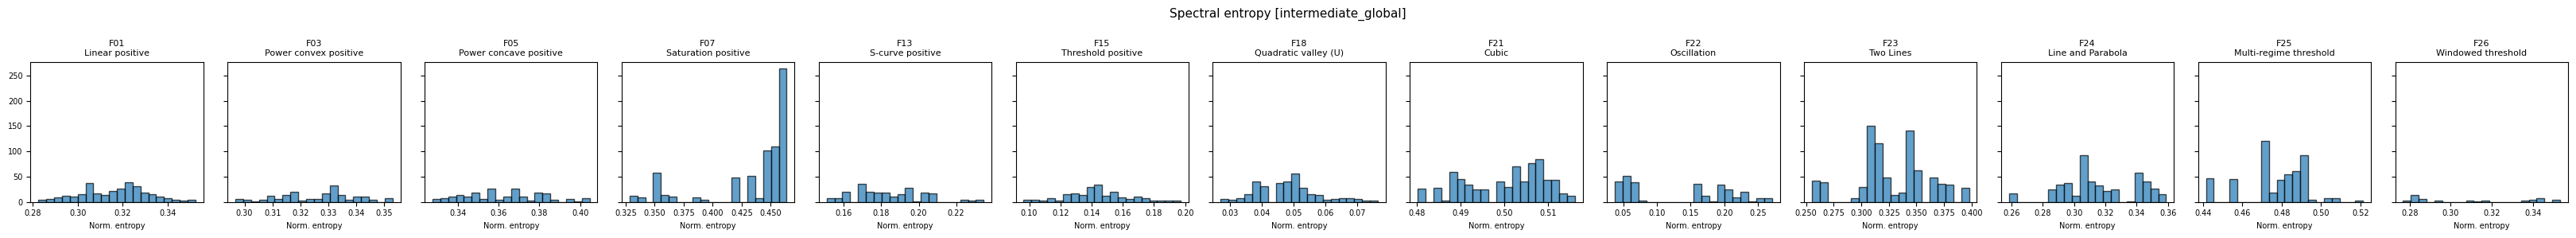

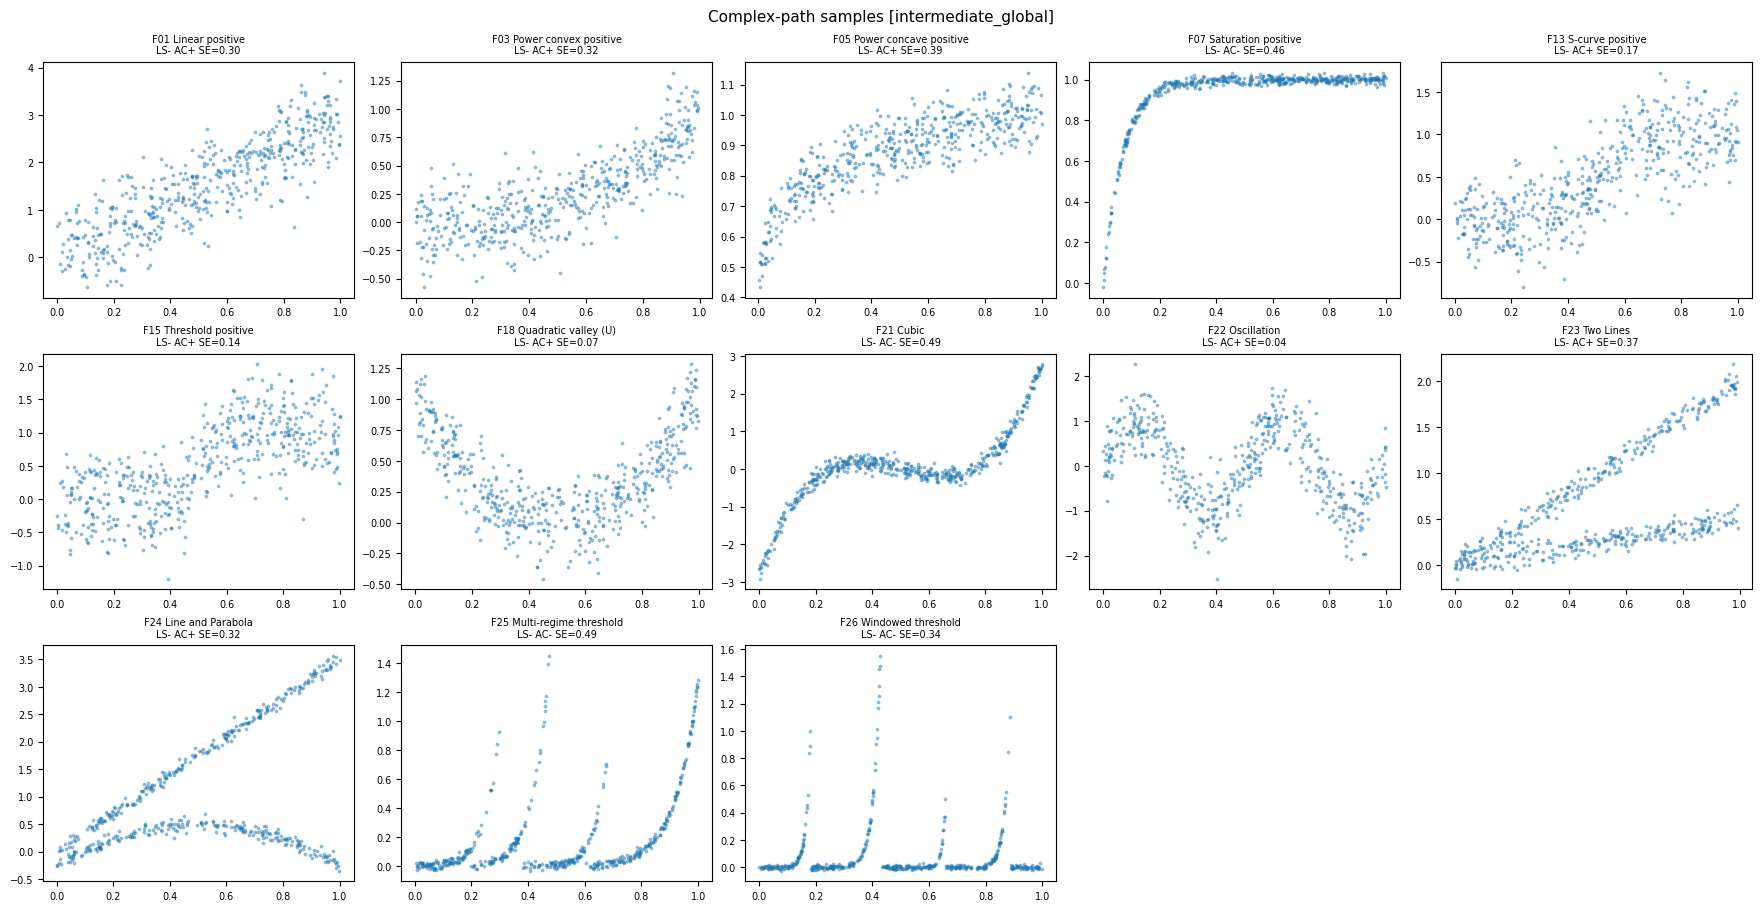

In [326]:
if RUN_METHOD_D:
    import time as _time
    import matplotlib.pyplot as plt
    periodicity_dfs = {}

    for _gate in MIC_ANALYSIS_GATES:
        complex_data = complex_datas.get(_gate)
        if complex_data is None or len(complex_data) == 0:
            print(f'[{_gate}] No complex cases, skipping Method D.')
            continue

        print(f'\n{"="*60}')
        print(f'=== Periodicity Detection [{_gate}] — {len(complex_data):,} complex cases ===')
        print(f'{"="*60}')

        period_results = []
        t0 = _time.time()

        for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc=f'Periodicity [{_gate}]'):
            pi = int(row['_pt_idx'])
            x = x_all[pi].astype(np.float64)
            y = y_all[pi].astype(np.float64)

            ls_power, ls_p, ls_period = lombscargle_test(x, y)
            ac_peak, ac_lag, ac_val = autocorr_test(x, y)
            se_entropy, se_norm = spectral_entropy_test(x, y)

            period_results.append({
                'case_id': row['case_id'],
                'family_id': row['family_id'],
                'ls_power': ls_power, 'ls_p': ls_p, 'ls_period': ls_period,
                'ls_sig': ls_p < 0.05 if not np.isnan(ls_p) else np.nan,
                'ac_peak': ac_peak, 'ac_lag': ac_lag, 'ac_val': ac_val,
                'se_entropy': se_entropy, 'se_norm': se_norm,
            })

        print(f'Periodicity: {len(period_results):,} cases in {_time.time()-t0:.1f}s')

        period_df = pd.DataFrame(period_results)
        period_df['family_name'] = period_df['family_id'].map(
            lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        periodicity_dfs[_gate] = period_df

        # ── Summary table: detection rates per family ──
        print(f'\n=== Periodicity detection rates [{_gate}] ===')
        _psig = period_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            LS_sig=('ls_sig', lambda s: count_percent(int(s.sum()), len(s))),
            AC_peak=('ac_peak', lambda s: count_percent(int(s.sum()), len(s))),
            SE_mean=('se_norm', 'mean'),
            SE_std=('se_norm', 'std'),
        ).round(3)
        display(_psig)

        # ── Distribution plots: 3 panels per family ──
        _fam_ids = sorted(period_df['family_id'].unique())
        n_fam = len(_fam_ids)

        if n_fam > 0:
            # 1. Lomb-Scargle power distribution
            fig, axes = plt.subplots(1, n_fam, figsize=(2.5*n_fam, 3), sharey=True)
            if n_fam == 1: axes = [axes]
            for ax, fid in zip(axes, _fam_ids):
                vals = period_df.loc[period_df['family_id'] == fid, 'ls_power'].dropna()
                fname = FAMILY_CATALOGUE.get(fid, {}).get('name', '')
                ax.hist(vals, bins=20, alpha=0.7, edgecolor='black')
                ax.set_title(f'{fid}\n{fname}', fontsize=8)
                ax.set_xlabel('LS power', fontsize=7)
                ax.tick_params(labelsize=7)
            fig.suptitle(f'Lomb-Scargle max power [{_gate}]', fontsize=11)
            plt.tight_layout()
            plt.show()

            # 2. Autocorrelation peak value distribution
            fig, axes = plt.subplots(1, n_fam, figsize=(2.5*n_fam, 3), sharey=True)
            if n_fam == 1: axes = [axes]
            for ax, fid in zip(axes, _fam_ids):
                vals = period_df.loc[period_df['family_id'] == fid, 'ac_val'].dropna()
                fname = FAMILY_CATALOGUE.get(fid, {}).get('name', '')
                ax.hist(vals, bins=20, alpha=0.7, edgecolor='black')
                ax.axvline(0.3, color='red', ls='--', lw=1)
                ax.set_title(f'{fid}\n{fname}', fontsize=8)
                ax.set_xlabel('ACF peak', fontsize=7)
                ax.tick_params(labelsize=7)
            fig.suptitle(f'Autocorrelation secondary peak [{_gate}]', fontsize=11)
            plt.tight_layout()
            plt.show()

            # 3. Spectral entropy distribution
            fig, axes = plt.subplots(1, n_fam, figsize=(2.5*n_fam, 3), sharey=True)
            if n_fam == 1: axes = [axes]
            for ax, fid in zip(axes, _fam_ids):
                vals = period_df.loc[period_df['family_id'] == fid, 'se_norm'].dropna()
                fname = FAMILY_CATALOGUE.get(fid, {}).get('name', '')
                ax.hist(vals, bins=20, alpha=0.7, edgecolor='black')
                ax.set_title(f'{fid}\n{fname}', fontsize=8)
                ax.set_xlabel('Norm. entropy', fontsize=7)
                ax.tick_params(labelsize=7)
            fig.suptitle(f'Spectral entropy [{_gate}]', fontsize=11)
            plt.tight_layout()
            plt.show()

            # 4. Scatter: 1 sample per family
            ncols = min(n_fam, 5)
            nrows = math.ceil(n_fam / ncols)
            fig, axes = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 3*nrows), constrained_layout=True)
            axes = np.array(axes).flatten() if n_fam > 1 else [axes]
            for ax, fid in zip(axes, _fam_ids):
                _pf = period_df[period_df['family_id'] == fid]
                _pick = _pf.sample(n=1, random_state=42).iloc[0]
                _cd = complex_datas[_gate]
                _pi = int(_cd.loc[_cd['case_id'] == _pick['case_id'], '_pt_idx'].iloc[0])
                _x = x_all[_pi].astype(np.float64)
                _y = y_all[_pi].astype(np.float64)
                fname = FAMILY_CATALOGUE.get(fid, {}).get('name', '')
                _ls = 'LS+' if _pick.get('ls_sig') else 'LS-'
                _ac = 'AC+' if _pick.get('ac_peak') else 'AC-'
                _se = f"SE={_pick.get('se_norm', 0):.2f}"
                ax.scatter(_x, _y, s=3, alpha=0.4)
                ax.set_title(f'{fid} {fname}\n{_ls} {_ac} {_se}', fontsize=7)
                ax.tick_params(labelsize=7)
            for ax in axes[n_fam:]:
                ax.set_visible(False)
            fig.suptitle(f'Complex-path samples [{_gate}]', fontsize=11)
            plt.show()


## Full classification tree summary

Combined results from Step 1 (Branch detection) → Step 2 (SiZer TP) → Step 3 (HD on TP=0).

In [327]:
if RUN_METHOD_A and RUN_METHOD_B:
    tree_dfs = {}

    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        klqrhd_df = klqrhd_dfs.get(_gate)
        if sizer_df is None:
            continue

        print(f'\n{"="*60}')
        print(f'=== Full classification tree [{_gate}] ===')
        print(f'{"="*60}')

        # Build unified label per case
        tree_df = sizer_df[['case_id', 'family_id', 'family_name', 'sizer_label']].copy()

        # Add branch info from Method C
        if RUN_METHOD_C:
            _cdd = cond_dip_dfs.get(_gate)
            if _cdd is not None:
                _branch_ids = set(_cdd[_cdd['is_branch']]['case_id'])
                _branch_rows = _cdd[_cdd['is_branch']][['case_id', 'family_id']].copy()
                _branch_rows['family_name'] = _branch_rows['family_id'].map(
                    lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
                _branch_rows['sizer_label'] = 'N/A'
                _branch_rows['tree_label'] = 'Branch'
                tree_df = pd.concat([tree_df, _branch_rows], ignore_index=True)

        # Assign tree_label for non-branch cases
        tree_df.loc[tree_df.get('tree_label') != 'Branch', 'tree_label'] = tree_df['sizer_label']

        # TP=0 cases: use HD result if available
        if klqrhd_df is not None and len(klqrhd_df) > 0:
            _hd_map = klqrhd_df.set_index('case_id')['klqrhd_label']
            _tp0_mask = tree_df['tree_label'] == 'TP=0'
            tree_df.loc[_tp0_mask, 'tree_label'] = tree_df.loc[_tp0_mask, 'case_id'].map(_hd_map).fillna('TP=0')

        tree_dfs[_gate] = tree_df.copy()

        # Summary table
        _tree_ct = tree_df.groupby(['family_id', 'tree_label']).size().unstack(fill_value=0)
        _tree_ct['total'] = _tree_ct.sum(axis=1)
        _tree_out = pd.DataFrame(index=_tree_ct.index)
        _tree_out['family_name'] = _tree_out.index.map(
            lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _tree_out['Total'] = [count_percent(n, n) for n in _tree_ct['total']]
        _label_order = ['Branch', 'Transition', 'Monotonic', 'TP=0', 'TP=1', 'TP=2', 'TP≥3', 'Uncertain', 'failed']
        for col in _label_order:
            if col in _tree_ct.columns:
                _tree_out[col] = [count_percent(int(n), int(t))
                                  for n, t in zip(_tree_ct[col], _tree_ct['total'])]
        display(_tree_out)

        print(f'\nTotal cases: {len(tree_df):,}')
        print(f'Label distribution:')
        for lbl, cnt in tree_df['tree_label'].value_counts().sort_index().items():
            print(f'  {lbl}: {cnt:,} ({cnt/len(tree_df):.1%})')

    # ══════════════════════════════════════════════════════════════════
    # Pipeline Summary per gate — Simple + Complex
    # ══════════════════════════════════════════════════════════════════
    _PW_TO_SIMPLE = {
        'positive_line': 'Linear', 'negative_line': 'Linear',
        'positive_concave': 'Saturation', 'negative_concave': 'Acceleration',
        'positive_convex': 'Acceleration', 'negative_convex': 'Saturation',
    }

    _EXP_S = {}
    _EXP_C = {}
    for _fid, _props in FAMILY_CATALOGUE.items():
        if _fid == 'Null':
            continue
        _epr = EXPECTED_POWER_ROUTE.get(_fid)
        if _epr and _epr != 'Enter next branch':
            _EXP_S[_fid] = _epr
        _mono = _props.get('monotonicity', '')
        _shape = _props.get('special_shape', '')
        _tp = _props.get('tp', 'N/A')
        if _mono == 'monotonic':
            if _shape in ('S-curve', 'threshold'):
                _EXP_C[_fid] = 'Transition'
            else:
                _EXP_C[_fid] = 'Monotonic'
        elif _mono == 'non-monotonic':
            if _tp == 1:
                _EXP_C[_fid] = 'TP=1'
            elif _tp == 2:
                _EXP_C[_fid] = 'TP=2'
            elif _tp == 'multiple':
                _EXP_C[_fid] = 'TP≥3'
        elif _mono == 'multi-branch':
            if 'two lines' in _shape or 'parabola' in _shape:
                _EXP_C[_fid] = 'Branch'

    _s_lbls = ['Linear', 'Saturation', 'Acceleration']
    _c_lbls = ['Branch', 'TP=1', 'TP=2', 'TP≥3', 'Uncertain', 'Transition', 'Monotonic']
    _ck = ['Total'] + [f's_{l}' for l in _s_lbls] + [f'c_{l}' for l in _c_lbls]

    _mi = pd.MultiIndex.from_tuples([
        ('', '', 'Total'),
        ('Simple Path', '', 'Subtotal'),
        ('Simple Path', '', 'Linear'),
        ('Simple Path', '', 'Saturation'),
        ('Simple Path', '', 'Acceleration'),
        ('Complex Path', '', 'Subtotal'),
        ('Complex Path', 'Branch', 'Branch'),
        ('Complex Path', 'No Branch', 'TP=1'),
        ('Complex Path', 'No Branch', 'TP=2'),
        ('Complex Path', 'No Branch', 'TP≥3'),
        ('Complex Path', 'No Branch', 'Uncertain'),
        ('Complex Path', 'TP=0 → HD', 'Transition'),
        ('Complex Path', 'TP=0 → HD', 'Monotonic'),
        ('Expected', '', 'Simple'),
        ('Expected', '', 'Complex'),
        ('Accuracy', '', 'Simple'),
        ('Accuracy', '', 'Complex'),
        ('Accuracy', '', 'Overall'),
    ])

    for _gate in MIC_ANALYSIS_GATES:
        _mask_gate = data['gate1'] == _gate
        _mask_simple_stay = _mask_gate & ~data['enters_complex']
        _s = data.loc[_mask_simple_stay, ['case_id', 'family_id', 'pw_label']].copy()
        _s['final_label'] = _s['pw_label'].map(_PW_TO_SIMPLE)
        _s['path'] = 'simple'

        _labeled = [_s[['case_id', 'family_id', 'final_label', 'path']]]
        _tree = tree_dfs.get(_gate)
        if _tree is not None:
            _c = _tree[['case_id', 'family_id', 'tree_label']].rename(
                columns={'tree_label': 'final_label'})
            _c['path'] = 'complex'
            _labeled.append(_c[['case_id', 'family_id', 'final_label', 'path']])

        _comb = pd.concat(_labeled, ignore_index=True)
        _families = sorted(_comb['family_id'].unique(),
                           key=lambda x: (int(x[1:]) if x[1:].isdigit() else 999))

        _rows = []
        _agg = dict(Total=0, s_n=0, c_n=0, s_ok=0, c_ok=0,
                    **{f's_{l}': 0 for l in _s_lbls},
                    **{f'c_{l}': 0 for l in _c_lbls})

        for _fid in _families:
            _fc = _comb[_comb['family_id'] == _fid]
            _sc = _fc[_fc['path'] == 'simple']
            _cc = _fc[_fc['path'] == 'complex']
            _sn, _cn = len(_sc), len(_cc)
            _total = _sn + _cn

            _r = dict(fid=_fid,
                      fname=FAMILY_CATALOGUE.get(_fid, {}).get('name', _fid),
                      Total=_total, s_n=_sn, c_n=_cn)
            for _l in _s_lbls:
                _r[f's_{_l}'] = int((_sc['final_label'] == _l).sum())
            for _l in _c_lbls:
                if _l == 'Uncertain':
                    _r[f'c_{_l}'] = int(_cc['final_label'].isin(['Uncertain', 'failed']).sum())
                else:
                    _r[f'c_{_l}'] = int((_cc['final_label'] == _l).sum())

            _es = _EXP_S.get(_fid)
            _ec = _EXP_C.get(_fid)
            _r['exp_s'] = _es if _es else '-'
            _r['exp_c'] = _ec if _ec else '-'

            _sok = int((_sc['final_label'] == _es).sum()) if _es and _sn > 0 else 0
            _cok = int((_cc['final_label'] == _ec).sum()) if _ec and _cn > 0 else 0
            _r['acc_s'] = f'{_sok}/{_sn} ({_sok/_sn:.1%})' if _es and _sn > 0 else '-'
            _r['acc_c'] = f'{_cok}/{_cn} ({_cok/_cn:.1%})' if _ec and _cn > 0 else '-'
            _den = (_sn if _es else 0) + (_cn if _ec else 0)
            _num = _sok + _cok
            _r['acc_all'] = f'{_num}/{_den} ({_num/_den:.1%})' if _den > 0 else 'N/A'
            _rows.append(_r)

            _agg['Total'] += _total
            for _l in _s_lbls:
                _agg[f's_{_l}'] += _r[f's_{_l}']
            for _l in _c_lbls:
                _agg[f'c_{_l}'] += _r[f'c_{_l}']
            if _es:
                _agg['s_n'] += _sn; _agg['s_ok'] += _sok
            if _ec:
                _agg['c_n'] += _cn; _agg['c_ok'] += _cok

        _disp = []
        for _r in _rows:
            _dr = [count_percent(_r['Total'], _r['Total']),
                   count_percent(_r['s_n'], _r['Total']),]
            for _l in _s_lbls:
                _dr.append(count_percent(int(_r[f's_{_l}']), int(_r['Total'])))
            _dr.append(count_percent(_r['c_n'], _r['Total']))
            for _l in _c_lbls:
                _dr.append(count_percent(int(_r[f'c_{_l}']), int(_r['Total'])))
            _dr += [_r['exp_s'], _r['exp_c'], _r['acc_s'], _r['acc_c'], _r['acc_all']]
            _disp.append(_dr)

        _T = _agg['Total']
        _s_total = sum(_agg[f's_{l}'] for l in _s_lbls)
        _c_total = sum(_agg[f'c_{l}'] for l in _c_lbls)
        _or = [count_percent(_T, _T), count_percent(_s_total, _T)]
        for _l in _s_lbls:
            _or.append(count_percent(_agg[f's_{_l}'], _T))
        _or.append(count_percent(_c_total, _T))
        for _l in _c_lbls:
            _or.append(count_percent(_agg[f'c_{_l}'], _T))
        _sa = f"{_agg['s_ok']}/{_agg['s_n']} ({_agg['s_ok']/_agg['s_n']:.1%})" if _agg['s_n'] else '-'
        _ca = f"{_agg['c_ok']}/{_agg['c_n']} ({_agg['c_ok']/_agg['c_n']:.1%})" if _agg['c_n'] else '-'
        _an = _agg['s_n'] + _agg['c_n']
        _ao = _agg['s_ok'] + _agg['c_ok']
        _aa = f'{_ao}/{_an} ({_ao/_an:.1%})' if _an else '-'
        _or += ['', '', _sa, _ca, _aa]
        _disp.append(_or)

        _idx = pd.MultiIndex.from_tuples(
            [(_r['fid'], _r['fname']) for _r in _rows] + [('', 'Overall')],
            names=['family_id', 'family_name'])

        _summary = pd.DataFrame(_disp, index=_idx, columns=_mi)

        print(f'\n{"="*60}')
        print(f'=== Pipeline Summary [{_gate}] (simple + complex) ===')
        print(f'{"="*60}')
        display(_summary)



=== Full classification tree [strong_global] ===


,family_name,Total,Branch,Transition,Monotonic,TP=1,TP=2,TP≥3,Uncertain
family_id,,,,,,,,,
F01,Linear positive,63 (100.0%),0 (0.0%),0 (0.0%),63 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,55 (100.0%),0 (0.0%),0 (0.0%),55 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,482 (100.0%),0 (0.0%),419 (86.9%),59 (12.2%),0 (0.0%),0 (0.0%),0 (0.0%),4 (0.8%)
F15,Threshold positive,"2,222 (100.0%)",0 (0.0%),"1,961 (88.3%)",26 (1.2%),133 (6.0%),30 (1.4%),0 (0.0%),72 (3.2%)
F18,Quadratic valley (U),"1,848 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),"1,848 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,"1,068 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),"1,068 (100.0%)",0 (0.0%),0 (0.0%)
F22,Oscillation,"1,990 (100.0%)",0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),"1,003 (50.4%)",987 (49.6%),0 (0.0%)
F23,Two Lines,310 (100.0%),310 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F25,Multi-regime threshold,32 (100.0%),0 (0.0%),0 (0.0%),1 (3.1%),0 (0.0%),17 (53.1%),0 (0.0%),14 (43.8%)



Total cases: 8,090
Label distribution:
  Branch: 310 (3.8%)
  Monotonic: 204 (2.5%)
  TP=1: 1,981 (24.5%)
  TP=2: 2,118 (26.2%)
  TP≥3: 1,007 (12.4%)
  Transition: 2,380 (29.4%)
  Uncertain: 90 (1.1%)

=== Full classification tree [intermediate_global] ===


,family_name,Total,Branch,Transition,Monotonic,TP=1,TP=2,TP≥3,Uncertain
family_id,,,,,,,,,
F01,Linear positive,309 (100.0%),0 (0.0%),0 (0.0%),309 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,184 (100.0%),0 (0.0%),0 (0.0%),154 (83.7%),25 (13.6%),0 (0.0%),0 (0.0%),5 (2.7%)
F05,Power concave positive,207 (100.0%),0 (0.0%),0 (0.0%),207 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,700 (100.0%),0 (0.0%),0 (0.0%),700 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,232 (100.0%),0 (0.0%),2 (0.9%),175 (75.4%),11 (4.7%),0 (0.0%),0 (0.0%),44 (19.0%)
F15,Threshold positive,206 (100.0%),0 (0.0%),0 (0.0%),47 (22.8%),37 (18.0%),28 (13.6%),12 (5.8%),82 (39.8%)
F18,Quadratic valley (U),333 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),333 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,702 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),702 (100.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,287 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),129 (44.9%),158 (55.1%),0 (0.0%)



Total cases: 5,000
Label distribution:
  Branch: 1,291 (25.8%)
  Monotonic: 1,596 (31.9%)
  TP=1: 406 (8.1%)
  TP=2: 1,156 (23.1%)
  TP≥3: 216 (4.3%)
  Transition: 2 (0.0%)
  Uncertain: 333 (6.7%)

=== Pipeline Summary [strong_global] (simple + complex) ===


Simple Path  \
                                                                    
                                            Total        Subtotal   
family_id family_name                                               
F01       Linear positive          1,982 (100.0%)   1,919 (96.8%)   
F03       Power convex positive    1,679 (100.0%)  1,679 (100.0%)   
F05       Power concave positive   1,782 (100.0%)  1,782 (100.0%)   
F07       Saturation positive        829 (100.0%)     774 (93.4%)   
F13       S-curve positive         2,175 (100.0%)   1,693 (77.8%)   
F15       Threshold positive       2,222 (100.0%)        0 (0.0%)   
F18       Quadratic valley (U)     1,848 (100.0%)        0 (0.0%)   
F21       Cubic                    1,068 (100.0%)        0 (0.0%)   
F22       Oscillation              1,990 (100.0%)        0 (0.0%)   
F23       Two Lines                  310 (100.0%)        0 (0.0%)   
F25       Multi-regime threshold      32 (100.0%)        0 (0.0%)   
F26       Windowed threshold          20 (100.0%)        0 (0.0%)   
          Overall                 15,937 (100.0%)   7,847 (49.2%)   

                                                                 \
                                                                  
                                         Linear      Saturation   
family_id family_name                                             
F01       Linear positive         1,843 (93.0%)       22 (1.1%)   
F03       Power convex positive        0 (0.0%)        0 (0.0%)   
F05       Power concave positive       0 (0.0%)  1,782 (100.0%)   
F07       Saturation positive          0 (0.0%)     774 (93.4%)   
F13       S-curve positive             0 (0.0%)        0 (0.0%)   
F15       Threshold positive           0 (0.0%)        0 (0.0%)   
F18       Quadratic valley (U)         0 (0.0%)        0 (0.0%)   
F21       Cubic                        0 (0.0%)        0 (0.0%)   
F22       Oscillation                  0 (0.0%)        0 (0.0%)   
F23       Two Lines                    0 (0.0%)        0 (0.0%)   
F25       Multi-regime threshold       0 (0.0%)        0 (0.0%)   
F26       Windowed threshold           0 (0.0%)        0 (0.0%)   
          Overall                 1,843 (11.6%)   2,578 (16.2%)   

                                                    Complex Path  \
                                                                   
                                    Acceleration        Subtotal   
family_id family_name                                              
F01       Linear positive              54 (2.7%)       63 (3.2%)   
F03       Power convex positive   1,679 (100.0%)        0 (0.0%)   
F05       Power concave positive        0 (0.0%)        0 (0.0%)   
F07       Saturation positive           0 (0.0%)       55 (6.6%)   
F13       S-curve positive         1,693 (77.8%)     482 (22.2%)   
F15       Threshold positive            0 (0.0%)  2,222 (100.0%)   
F18       Quadratic valley (U)          0 (0.0%)  1,848 (100.0%)   
F21       Cubic                         0 (0.0%)  1,068 (100.0%)   
F22       Oscillation                   0 (0.0%)  1,990 (100.0%)   
F23       Two Lines                     0 (0.0%)    310 (100.0%)   
F25       Multi-regime threshold        0 (0.0%)     32 (100.0%)   
F26       Windowed threshold            0 (0.0%)     20 (100.0%)   
          Overall                  3,426 (21.5%)   8,090 (50.8%)   

                                                                \
                                        Branch       No Branch   
                                        Branch            TP=1   
family_id family_name                                            
F01       Linear positive             0 (0.0%)        0 (0.0%)   
F03       Power convex positive       0 (0.0%)        0 (0.0%)   
F05       Power concave positive      0 (0.0%)        0 (0.0%)   
F07       Saturation positive         0 (0.0%)        0 (0.0%)   
F13       S-curve positive            0 (0.0%)        0


=== Pipeline Summary [intermediate_global] (simple + complex) ===


Simple Path            \
                                                                          
                                           Total     Subtotal    Linear   
family_id family_name                                                     
F01       Linear positive           309 (100.0%)     0 (0.0%)  0 (0.0%)   
F03       Power convex positive     428 (100.0%)  244 (57.0%)  0 (0.0%)   
F05       Power concave positive    337 (100.0%)  130 (38.6%)  0 (0.0%)   
F07       Saturation positive       833 (100.0%)  133 (16.0%)  0 (0.0%)   
F13       S-curve positive          232 (100.0%)     0 (0.0%)  0 (0.0%)   
F15       Threshold positive        206 (100.0%)     0 (0.0%)  0 (0.0%)   
F18       Quadratic valley (U)      333 (100.0%)     0 (0.0%)  0 (0.0%)   
F21       Cubic                     702 (100.0%)     0 (0.0%)  0 (0.0%)   
F22       Oscillation               287 (100.0%)     0 (0.0%)  0 (0.0%)   
F23       Two Lines                 816 (100.0%)     0 (0.0%)  0 (0.0%)   
F24       Line and Parabola         475 (100.0%)     0 (0.0%)  0 (0.0%)   
F25       Multi-regime threshold    503 (100.0%)     0 (0.0%)  0 (0.0%)   
F26       Windowed threshold         46 (100.0%)     0 (0.0%)  0 (0.0%)   
          Overall                 5,507 (100.0%)   507 (9.2%)  0 (0.0%)   

                                                             Complex Path  \
                                                                            
                                   Saturation Acceleration       Subtotal   
family_id family_name                                                       
F01       Linear positive            0 (0.0%)     0 (0.0%)   309 (100.0%)   
F03       Power convex positive      0 (0.0%)  244 (57.0%)    184 (43.0%)   
F05       Power concave positive  130 (38.6%)     0 (0.0%)    207 (61.4%)   
F07       Saturation positive     133 (16.0%)     0 (0.0%)    700 (84.0%)   
F13       S-curve positive           0 (0.0%)     0 (0.0%)   232 (100.0%)   
F15       Threshold positive         0 (0.0%)     0 (0.0%)   206 (100.0%)   
F18       Quadratic valley (U)       0 (0.0%)     0 (0.0%)   333 (100.0%)   
F21       Cubic                      0 (0.0%)     0 (0.0%)   702 (100.0%)   
F22       Oscillation                0 (0.0%)     0 (0.0%)   287 (100.0%)   
F23       Two Lines                  0 (0.0%)     0 (0.0%)   816 (100.0%)   
F24       Line and Parabola          0 (0.0%)     0 (0.0%)   475 (100.0%)   
F25       Multi-regime threshold     0 (0.0%)     0 (0.0%)   503 (100.0%)   
F26       Windowed threshold         0 (0.0%)     0 (0.0%)    46 (100.0%)   
          Overall                  263 (4.8%)   244 (4.4%)  5,000 (90.8%)   

                                                                              \
                                         Branch     No Branch                  
                                         Branch          TP=1           TP=2   
family_id family_name                                                          
F01       Linear positive              0 (0.0%)      0 (0.0%)       0 (0.0%)   
F03       Power convex positive        0 (0.0%)     25 (5.8%)       0 (0.0%)   
F05       Power concave positive       0 (0.0%)      0 (0.0%)       0 (0.0%)   
F07       Saturation positive          0 (0.0%)      0 (0.0%)       0 (0.0%)   
F13       S-curve positive             0 (0.0%)     11 (4.7%)       0 (0.0%)   
F15       Threshold positive           0 (0.0%)    37 (18.0%)     28 (13.6%)   
F18       Quadratic valley (U)         0 (0.0%)  333 (100.0%)       0 (0.0%)   
F21       Cubic                        0 (0.0%)      0 (0.0%)   702 (100.0%)   
F22       Oscillation                  0 (0.0%)      0 (0.0%)    129 (44.9%)   
F23       Two Lines                816 (100.0%)      0 (0.0%)       0 (0.0%)   
F24       Line and Parabola        475 (100.0%)      0 (0.0%)       0 (0.0%)   
F25       Multi-regime threshold       0 (0.0%)      0 (0.0%)    297 (59.0%)   
F26       Windowed threshold    